# Ingeniería de características distribuida — Clasificación del nivel de operación aérea mensual por aeropuerto en Colombia

En este notebook se realiza la ingeniería de características sobre el dataset Gold construido en la ingesta.

La lógica se mantiene organizada por etapas:

0. IMPORTS Y CONFIGURACIÓN VISUAL BÁSICA
1. FUNCIONES AUXILIARES DE LECTURA, ESCRITURA Y FECHAS
2. Carga del dataset Gold
3. Particionar el dataset
4. Análisis de valores faltantes
5. Estrategia de imputación METAR
6. Imputación sin fuga de información
7. Validación visual: distribuciones antes vs después
8. Disponibilidad METAR vs target
9. Conclusiones para el modelado
10. Ingeniería de características
11. Imputación final después de ingeniería de características
12. Tratamiento de outliers sin fuga de información
13. Preprocesamiento común para modelado
14. Selección de features por correlación
15. Recomendación para modelado
16. Guardar datasets finales para modelado

Las transformaciones principales se ejecutan con **PySpark DataFrames**.

## 0. IMPORTS Y CONFIGURACIÓN VISUAL BÁSICA

In [0]:
import re
from pathlib import Path
import json
import math
import shutil
import time
import textwrap
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import DataFrame, Window
from pyspark.sql import functions as F
from pyspark.sql import types as T

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

spark.conf.set("spark.sql.session.timeZone", "UTC")

TARGET_COL = "target_nivel_operacion_mes_siguiente"
TARGET_NUM_COL = "target_operaciones_total_mes_siguiente"
TARGET_ORDER = ["bajo", "medio", "alto"]

print("Imports OK")

Imports OK


## 1. FUNCIONES AUXILIARES DE LECTURA, ESCRITURA Y FECHAS

In [0]:
def remove_path_if_exists(path: Path) -> None:
    path = Path(path)

    if path.is_dir():
        shutil.rmtree(path)
    elif path.exists():
        path.unlink()


def write_spark_parquet_dataset(
    df: DataFrame,
    output_path: Path,
    mode: str = "overwrite",
    partition_by: list[str] | None = None,
    compute_count: bool = True,
) -> None:
    """
    Escribe un Spark DataFrame como dataset Parquet distribuido.

    Spark guarda Parquet como carpeta:

        archivo.parquet/
        ├── part-00000-....snappy.parquet
        ├── part-00001-....snappy.parquet
        └── _SUCCESS

    Esta versión imprime logs progresivos para Databricks.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    print(f"[INFO] Preparando escritura: {output_path}", flush=True)
    print(f"[INFO] Columnas: {len(df.columns):,}", flush=True)

    remove_path_if_exists(output_path)

    writer = (
        df.write
        .mode(mode)
        .option("compression", "snappy")
    )

    if partition_by:
        print(f"[INFO] Escritura particionada por: {partition_by}", flush=True)
        writer = writer.partitionBy(*partition_by)

    print("[INFO] Iniciando writer.parquet(...)", flush=True)

    writer.parquet(str(output_path))

    print("[INFO] Escritura física terminada.", flush=True)

    n_rows = None

    if compute_count:
        print("[INFO] Calculando número de filas con df.count()...", flush=True)
        n_rows = df.count()
        print(f"[INFO] Conteo terminado: {n_rows:,} filas.", flush=True)

    part_files = sorted(output_path.glob("part-*.parquet"))
    n_part_files = len(part_files)

    if n_rows is not None:
        print(
            f"[OK] Dataset Parquet Spark guardado: {output_path} | "
            f"filas={n_rows:,} | columnas={len(df.columns):,} | "
            f"part-files={n_part_files:,}",
            flush=True,
        )
    else:
        print(
            f"[OK] Dataset Parquet Spark guardado: {output_path} | "
            f"columnas={len(df.columns):,} | part-files={n_part_files:,}",
            flush=True,
        )

def read_spark_parquet(path_or_paths) -> DataFrame:
    """
    Lee Parquet usando Spark.

    Soporta:
    - Un solo path: Path o string.
    - Varios paths: list, tuple o set de Path/string.
    - Parquet tipo carpeta Spark con part-files.
    """

    if isinstance(path_or_paths, (list, tuple, set)):
        paths = [str(path) for path in path_or_paths]

        if not paths:
            raise ValueError("La lista de paths Parquet está vacía.")

        return spark.read.parquet(*paths)

    return spark.read.parquet(str(path_or_paths))


def normalizar_columna_fecha_mes(df: DataFrame, col_name: str = "fecha_mes") -> DataFrame:
    '''
    Normaliza fecha_mes cuando Spark la lee como:
    - date/timestamp/string
    - bigint/long por timestamps en nanosegundos escritos con pandas/pyarrow
    '''
    dtype_map = dict(df.dtypes)

    if col_name not in dtype_map:
        return df

    dtype = dtype_map[col_name].lower()

    if dtype in ["bigint", "long"]:
        return df.withColumn(
            col_name,
            F.to_date(F.from_unixtime(F.col(col_name) / F.lit(1_000_000_000))),
        )

    return df.withColumn(col_name, F.to_date(F.col(col_name)))


def safe_divide_expr(numerator_col: str, denominator_col: str):
    numerator = F.col(numerator_col).cast("double")
    denominator = F.col(denominator_col).cast("double")

    return (
        F.when(denominator.isNull() | (denominator == 0), F.lit(0.0))
        .otherwise(numerator / denominator)
    )

## 2. Carga del dataset Gold

In [0]:
BASE_DIR = Path("/Volumes/workspace/default/proyecto_aeropuertos")
GOLD_MONTHLY_DIR = BASE_DIR / "gold" / "monthly_airport_dataset"

df_model = read_spark_parquet(
    GOLD_MONTHLY_DIR / "monthly_airport_model_dataset.parquet"
)

df_model = df_model.withColumn(
    "fecha_mes",
    F.to_date(F.col("fecha_mes"))
)

print("Filas:", df_model.count())
print("Columnas:", len(df_model.columns))
print("Aeropuertos únicos:", df_model.select("icao_code").distinct().count())

display(df_model.limit(5))

Filas: 3254
Columnas: 66
Aeropuertos únicos: 46


icao_code,fecha_mes,operaciones_llegada,operaciones_salida,TOQUE Y DESPEGUE,operaciones_otras,operaciones_total,pasajeros_salida,carga_salida_kg,n_destinos_total,n_empresas_salida,n_registros_salida,pasajeros_llegada,carga_llegada_kg,n_origenes_total,n_empresas_llegada,n_registros_llegada,pasajeros_total,carga_total_kg,pasajeros_salida_internacional,pasajeros_salida_nacional,pasajeros_llegada_internacional,pasajeros_llegada_nacional,pasajeros_internacional_total,proporcion_pasajeros_internacional,n_metar_mes,temp_media_c,temp_min_c,temp_max_c,temp_std_c,dewpoint_media_c,humedad_media_pct,viento_medio_kt,viento_max_kt,viento_std_kt,rafaga_max_kt,visibilidad_media_sm,visibilidad_min_sm,visibilidad_std_sm,cloud_base_min_ft,altimeter_media_inhg,prop_lluvia,prop_tormenta,prop_niebla,prop_baja_visibilidad,prop_viento_fuerte,prop_rafaga,prop_ifr_aprox,n_metar_esperados_mes,cobertura_metar_ratio,name,type,municipality,region_name,iata_code,latitude_deg,longitude_deg,elevation_ft,scheduled_service,tiene_metar_mes,tiene_od_mes,sin_od_sin_metar_mes,target_operaciones_total_mes_siguiente,target_q33_operaciones,target_q66_operaciones,target_nivel_operacion_mes_siguiente
SKAR,2020-01-01,408.0,409.0,0.0,0.0,817.0,25548.0,119.0,73,5,85,22854.0,0.0,71,5,85,48402.0,119.0,4448.0,21100.0,3880.0,18974.0,8328.0,0.17205900582620554,573,23.653846153846153,15.0,33.00000000000001,4.334010316828683,18.793706293706293,76.9764335664337,1.2,12.0,1.983765392331008,null,5.809544658493886,0.62,1.0573798149208828,600.0,30.03521815008726,0.1082024432809773,0.012216404886561954,0.0506108202443281,0.047285464098073555,0.0,0.0,0.04903677758318739,744,0.7701612903225806,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,744.0,220.0,564.0,alto
SKAR,2020-02-01,372.0,372.0,0.0,0.0,744.0,22490.0,182.0,66,6,76,22022.0,130.0,71,6,82,44512.0,312.0,3206.0,19284.0,2930.0,19092.0,6136.0,0.1378504672897196,508,23.823762376237624,16.0,34.0,4.35555539518966,18.883168316831682,76.7702772277228,1.2693069306930693,13.0,2.053536562987683,null,5.627658730158736,0.19,1.3089271685649784,300.0,30.02348425196852,0.13385826771653545,0.025590551181102362,0.09645669291338582,0.06349206349206349,0.0,0.0,0.06746031746031746,696,0.7298850574712644,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,531.0,220.0,564.0,medio
SKAR,2020-03-01,265.0,266.0,0.0,0.0,531.0,13541.0,4170.0,69,7,82,13241.0,3660.0,67,7,87,26782.0,7830.0,1975.0,11566.0,1580.0,11661.0,3555.0,0.13273840639235307,525,23.274193548387096,15.0,30.0,3.2432399554963545,17.99794661190965,74.21174537987689,1.5487077534791251,14.0,2.3236857057363314,null,5.668011583011595,0.12,1.1737884011598065,800.0,30.029105367793274,0.1180952380952381,0.017142857142857144,0.1180952380952381,0.059845559845559844,0.0,0.0,0.06640625,744,0.7056451612903226,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,21.0,220.0,564.0,bajo
SKAR,2020-04-01,11.0,10.0,0.0,0.0,21.0,0.0,17216.0,3,1,3,0.0,16709.0,2,1,2,0.0,33925.0,0.0,0.0,0.0,0.0,0.0,0.0,277,24.25221238938053,18.000000000000004,31.0,3.1542732170856076,19.51769911504425,76.47553097345138,1.736842105263158,9.0,2.3636477132610865,null,5.641805054151642,0.19,1.2982877484596589,200.0,30.067268722466956,0.17328519855595667,0.036101083032490974,0.05776173285198556,0.05415162454873646,0.0,0.0,0.08303249097472924,720,0.38472222222222224,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,31.0,220.0,564.0,bajo
SKAR,2020-05-01,18.0,13.0,0.0,0.0,31.0,0.0,7891.0,2,2,2,0.0,6061.0,2,2,2,0.0,13952.0,0.0,0.0,0.0,0.0,0.0,0.0,208,25.4126213592233,20.0,32.0,2.790163195214897,20.28640776699029,74.46888349514565,1.3349514563106797,8.0,1.9654185298892481,null,5.911730769230784,1.24,0.8861134182296055,800.0,30.071835748792292,0.125,0.004807692307692308,0.0625,0.028846153846153848,0.0,0.0,0.04326923076923077,744,0.27956989247311825,El Eden Airport,medium_airport,Armen

## 3. Particionar el dataset

In [0]:
def split_temporal_por_fecha_mes_spark(
    df: DataFrame,
    train_frac: float = 0.80,
    valid_frac: float = 0.10,
) -> tuple[DataFrame, DataFrame, DataFrame]:
    '''
    Divide el dataset por valores únicos de fecha_mes sin partir un mismo mes entre splits.
    '''
    fechas = [
        row["fecha_mes"]
        for row in df.select("fecha_mes").distinct().orderBy("fecha_mes").collect()
    ]

    n_tiempos = len(fechas)

    n_train = int(n_tiempos * train_frac)
    n_valid = int(n_tiempos * valid_frac)

    corte_train = fechas[n_train]
    corte_valid = fechas[n_train + n_valid]

    df_train = (
        df
        .filter(F.col("fecha_mes") < F.lit(corte_train))
        .orderBy("fecha_mes")
    )

    df_valid = (
        df
        .filter((F.col("fecha_mes") >= F.lit(corte_train)) & (F.col("fecha_mes") < F.lit(corte_valid)))
        .orderBy("fecha_mes")
    )

    df_test = (
        df
        .filter(F.col("fecha_mes") >= F.lit(corte_valid))
        .orderBy("fecha_mes")
    )

    return df_train, df_valid, df_test

In [0]:
df_train, df_valid, df_test = split_temporal_por_fecha_mes_spark(df_model)

In [0]:
def resumen_split(df: DataFrame, nombre: str) -> None:
    r = df.agg(
        F.min("fecha_mes").alias("min_fecha"),
        F.max("fecha_mes").alias("max_fecha"),
        F.count("*").alias("n_filas"),
    ).collect()[0]

    n_filas = int(r["n_filas"])

    print(f"{nombre}:")
    print("  Fecha mínima:", r["min_fecha"])
    print("  Fecha máxima:", r["max_fecha"])
    print("  Filas:", n_filas)
    print("  Columnas:", len(df.columns))

    target_counts = (
        df
        .groupBy(TARGET_COL)
        .count()
        .withColumn(
            "pct",
            F.col("count") / F.lit(n_filas) * F.lit(100.0)
        )
        .orderBy(TARGET_COL)
    )

    display(target_counts)


resumen_split(df_model, "Dataset completo")
resumen_split(df_train, "Train")
resumen_split(df_valid, "Validation")
resumen_split(df_test, "Test")

Dataset completo:
  Fecha mínima: 2020-01-01
  Fecha máxima: 2025-11-01
  Filas: 3254
  Columnas: 66


target_nivel_operacion_mes_siguiente,count,pct
alto,1105,33.95820528580209
bajo,1072,32.9440688383528
medio,1077,33.097725875845114


Train:
  Fecha mínima: 2020-01-01
  Fecha máxima: 2024-08-01
  Filas: 2572
  Columnas: 66


target_nivel_operacion_mes_siguiente,count,pct
alto,852,33.12597200622084
bajo,888,34.52566096423017
medio,832,32.34836702954899


Validation:
  Fecha mínima: 2024-09-01
  Fecha máxima: 2025-03-01
  Filas: 319
  Columnas: 66


target_nivel_operacion_mes_siguiente,count,pct
alto,115,36.05015673981191
bajo,85,26.64576802507837
medio,119,37.30407523510972


Test:
  Fecha mínima: 2025-04-01
  Fecha máxima: 2025-11-01
  Filas: 363
  Columnas: 66


target_nivel_operacion_mes_siguiente,count,pct
alto,138,38.01652892561984
bajo,99,27.27272727272727
medio,126,34.710743801652896


### 3.1 Distribución porcentual del target por split

In [0]:
def graficar_proporcion_target_splits_spark(
    df_train: DataFrame,
    df_valid: DataFrame,
    df_test: DataFrame,
    target_col: str = "target_nivel_operacion_mes_siguiente",
    target_order: list[str] | None = None,
    figsize: tuple[int, int] = (10, 5),
):
    """
    Grafica la proporción porcentual del target categórico en
    Train, Validation y Test usando Spark para los conteos.

    Retorna:
    - resumen_rows: lista de diccionarios con split, clase, n y pct
    - resumen_df_spark: Spark DataFrame con el resumen
    """

    if target_order is None:
        target_order = ["bajo", "medio", "alto"]

    datasets = {
        "Train": df_train,
        "Validation": df_valid,
        "Test": df_test,
    }

    resumen_rows = []

    for split_name, df_split in datasets.items():
        total_split = df_split.count()

        conteos_rows = (
            df_split
            .groupBy(target_col)
            .count()
            .collect()
        )

        conteos_dict = {
            row[target_col]: int(row["count"])
            for row in conteos_rows
        }

        for clase in target_order:
            n = int(conteos_dict.get(clase, 0))
            pct = (n / total_split * 100.0) if total_split > 0 else 0.0

            resumen_rows.append({
                "split": split_name,
                "clase": clase,
                "n": n,
                "pct": pct,
            })

    resumen_df_spark = spark.createDataFrame(resumen_rows)

    # -----------------------------
    # Preparar datos para la gráfica
    # -----------------------------
    split_order = ["Train", "Validation", "Test"]
    x = np.arange(len(split_order))
    width = 0.24

    colores = {
        "bajo": "#4A78D0",
        "medio": "#66C866",
        "alto": "#D65F5F",
    }

    # lookup[(split, clase)] = pct
    pct_lookup = {
        (row["split"], row["clase"]): float(row["pct"])
        for row in resumen_rows
    }

    fig, ax = plt.subplots(figsize=figsize)

    for i, clase in enumerate(target_order):
        valores = [
            pct_lookup.get((split_name, clase), 0.0)
            for split_name in split_order
        ]

        posiciones = x + (i - 1) * width

        barras = ax.bar(
            posiciones,
            valores,
            width=width,
            label=clase,
            color=colores.get(clase, None),
            edgecolor="white",
            linewidth=1.2,
        )

        for barra, valor in zip(barras, valores):
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.8,
                f"{valor:.1f}%",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
            )

    ax.set_title(
        "Distribución porcentual del target por split",
        fontsize=15,
        fontweight="bold",
        pad=14,
    )

    ax.set_xlabel("Split")
    ax.set_ylabel("% de registros")
    ax.set_xticks(x)
    ax.set_xticklabels(split_order)
    ax.set_ylim(0, max(45, max([row["pct"] for row in resumen_rows]) + 8))
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.legend(title="Clase target", frameon=False, ncol=len(target_order))

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

    display(
        resumen_df_spark
        .orderBy("split", "clase")
    )

    return resumen_rows, resumen_df_spark

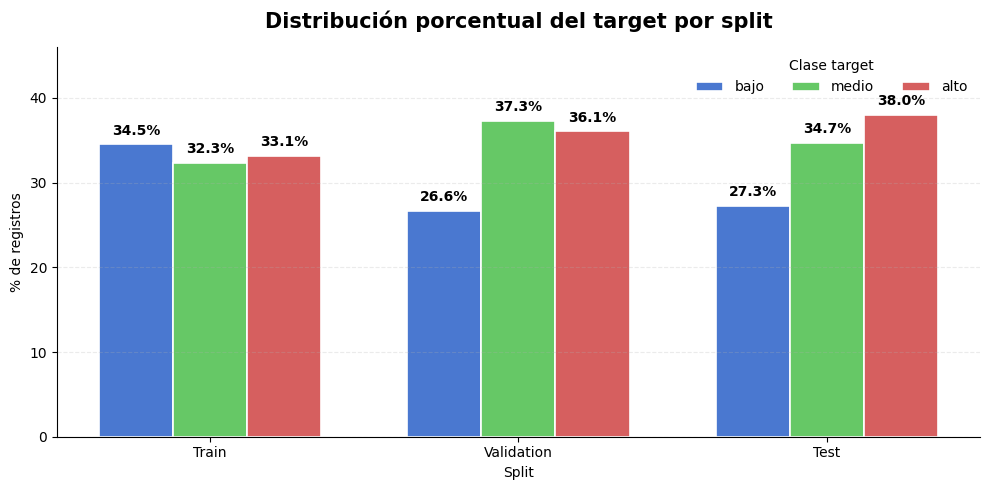

clase,n,pct,split
alto,138,38.01652892561984,Test
bajo,99,27.27272727272727,Test
medio,126,34.710743801652896,Test
alto,852,33.12597200622084,Train
bajo,888,34.52566096423017,Train
medio,832,32.34836702954899,Train
alto,115,36.05015673981191,Validation
bajo,85,26.64576802507837,Validation
medio,119,37.30407523510972,Validation


In [0]:
resumen_rows_target, resumen_df_target = graficar_proporcion_target_splits_spark(
    df_train=df_train,
    df_valid=df_valid,
    df_test=df_test,
    target_col=TARGET_COL,
    target_order=TARGET_ORDER,
    figsize=(10, 5),
)

In [0]:
def resumir_diferencia_target_splits_spark(
    resumen_rows_target: list[dict],
    target_order: list[str] | None = None,
) -> list[dict]:
    """
    Calcula la diferencia porcentual del target entre Validation/Test
    frente a Train usando el resumen ya calculado desde Spark.

    Entrada esperada:
    resumen_rows_target = [
        {"split": "Train", "clase": "bajo", "n": ..., "pct": ...},
        ...
    ]

    Retorna una lista de diccionarios lista para graficar.
    """

    if target_order is None:
        target_order = ["bajo", "medio", "alto"]

    pct_lookup = {
        (row["split"], row["clase"]): float(row["pct"])
        for row in resumen_rows_target
    }

    resumen_diff = []

    for clase in target_order:
        train_pct = pct_lookup.get(("Train", clase), 0.0)
        validation_pct = pct_lookup.get(("Validation", clase), 0.0)
        test_pct = pct_lookup.get(("Test", clase), 0.0)

        validation_vs_train_pp = validation_pct - train_pct
        test_vs_train_pp = test_pct - train_pct

        if test_vs_train_pp > 0:
            lectura = f"En test aumenta {abs(test_vs_train_pp):.2f} pp frente a train"
        elif test_vs_train_pp < 0:
            lectura = f"En test disminuye {abs(test_vs_train_pp):.2f} pp frente a train"
        else:
            lectura = "En test se mantiene igual que train"

        resumen_diff.append({
            "clase": clase,
            "train_pct": round(train_pct, 2),
            "validation_pct": round(validation_pct, 2),
            "test_pct": round(test_pct, 2),
            "validation_vs_train_pp": round(validation_vs_train_pp, 2),
            "test_vs_train_pp": round(test_vs_train_pp, 2),
            "lectura": lectura,
        })

    return resumen_diff

In [0]:
resumir_diferencia_target = resumir_diferencia_target_splits_spark(
    resumen_rows_target=resumen_rows_target,
    target_order=TARGET_ORDER,
)

resumir_diferencia_target_df = spark.createDataFrame(resumir_diferencia_target)

display(resumir_diferencia_target_df)

clase,lectura,test_pct,test_vs_train_pp,train_pct,validation_pct,validation_vs_train_pp
bajo,En test disminuye 7.25 pp frente a train,27.27,-7.25,34.53,26.65,-7.88
medio,En test aumenta 2.36 pp frente a train,34.71,2.36,32.35,37.3,4.96
alto,En test aumenta 4.89 pp frente a train,38.02,4.89,33.13,36.05,2.92


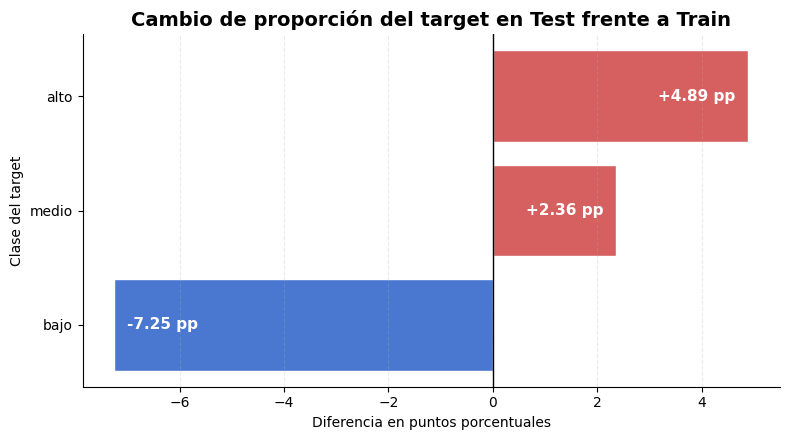

In [0]:
df_plot_diff = resumir_diferencia_target

fig, ax = plt.subplots(figsize=(8, 4.5))

clases = [
    row["clase"]
    for row in df_plot_diff
]

valores = [
    row["test_vs_train_pp"]
    for row in df_plot_diff
]

colors = [
    "#D65F5F" if value > 0 else "#4A78D0"
    for value in valores
]

bars = ax.barh(
    clases,
    valores,
    color=colors,
    edgecolor="white",
)

ax.axvline(
    0,
    color="black",
    linewidth=1,
)

for bar, value in zip(bars, valores):
    if value >= 0:
        x_text = value - 0.25
        ha_text = "right"
    else:
        x_text = value + 0.25
        ha_text = "left"

    ax.text(
        x_text,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.2f} pp",
        va="center",
        ha=ha_text,
        fontsize=11,
        fontweight="bold",
        color="white",
        clip_on=True,
    )

ax.set_title(
    "Cambio de proporción del target en Test frente a Train",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Diferencia en puntos porcentuales")
ax.set_ylabel("Clase del target")
ax.grid(axis="x", linestyle="--", alpha=0.25)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

En el conjunto de prueba frente al entrenamiento:
- La clase **bajo** disminuye 7.25 puntos porcentuales.
- La clase **medio** aumenta 2.36 puntos porcentuales.
- La clase **alto** aumenta 4.89 puntos porcentuales.

La distribución del target en el conjunto de entrenamiento es aproximadamente balanceada entre las tres clases. Sin embargo, los conjuntos de validación y prueba presentan una menor proporción de la clase bajo y una mayor proporción de las clases medio y alto. Esta diferencia es esperable al utilizar una partición temporal, ya que los periodos más recientes pueden reflejar cambios en el nivel operacional de los aeropuertos. Por esta razón, no se aplicó estratificación aleatoria, con el fin de evitar fuga temporal. La evaluación del modelo debe realizarse mediante métricas por clase, macro F1, balanced accuracy y matriz de confusión.

## 4. Análisis de valores faltantes

In [0]:
df = df_train

### 4.1. Calcular nulos en una sola agregación Spark

In [0]:
total_train = df.count()

In [0]:


null_exprs = [
    F.sum(
        F.when(F.col(col_name).isNull(), F.lit(1)).otherwise(F.lit(0))
    ).alias(col_name)
    for col_name in df.columns
]

nulos_agg = df.agg(*null_exprs).collect()[0].asDict()

nulos_rows = []

for col_name, n_nulls in nulos_agg.items():
    n_nulls = int(n_nulls)

    if n_nulls > 0:
        nulos_rows.append({
            "variable": col_name,
            "n_nulos": n_nulls,
            "pct_nulos": round(n_nulls / total_train * 100, 1),
        })

schema_nulos = T.StructType([
    T.StructField("variable", T.StringType(), True),
    T.StructField("n_nulos", T.LongType(), True),
    T.StructField("pct_nulos", T.DoubleType(), True),
])

nulos = spark.createDataFrame(nulos_rows, schema=schema_nulos)

display(
    nulos
    .orderBy(F.desc("pct_nulos"))
)

print(f"Variables con >50% nulos : {nulos.filter(F.col('pct_nulos') > 50).count()}")
print(f"Variables con >20% nulos : {nulos.filter(F.col('pct_nulos') > 20).count()}")
print(f"Variables sin nulos      : {len(df.columns) - nulos.count()}")

variable,n_nulos,pct_nulos
rafaga_max_kt,1918,74.6
viento_std_kt,972,37.8
temp_std_c,970,37.7
visibilidad_std_sm,968,37.6
prop_ifr_aprox,830,32.3
cloud_base_min_ft,829,32.2
humedad_media_pct,817,31.8
dewpoint_media_c,816,31.7
temp_media_c,814,31.6
temp_min_c,814,31.6


Variables con >50% nulos : 1
Variables con >20% nulos : 24
Variables sin nulos      : 38


In [0]:
nulos_plot_rows = (
    nulos
    .orderBy(F.asc("pct_nulos"))
    .collect()
)

variables_plot = [
    row["variable"]
    for row in nulos_plot_rows
]

pct_nulos_plot = [
    float(row["pct_nulos"])
    for row in nulos_plot_rows
]

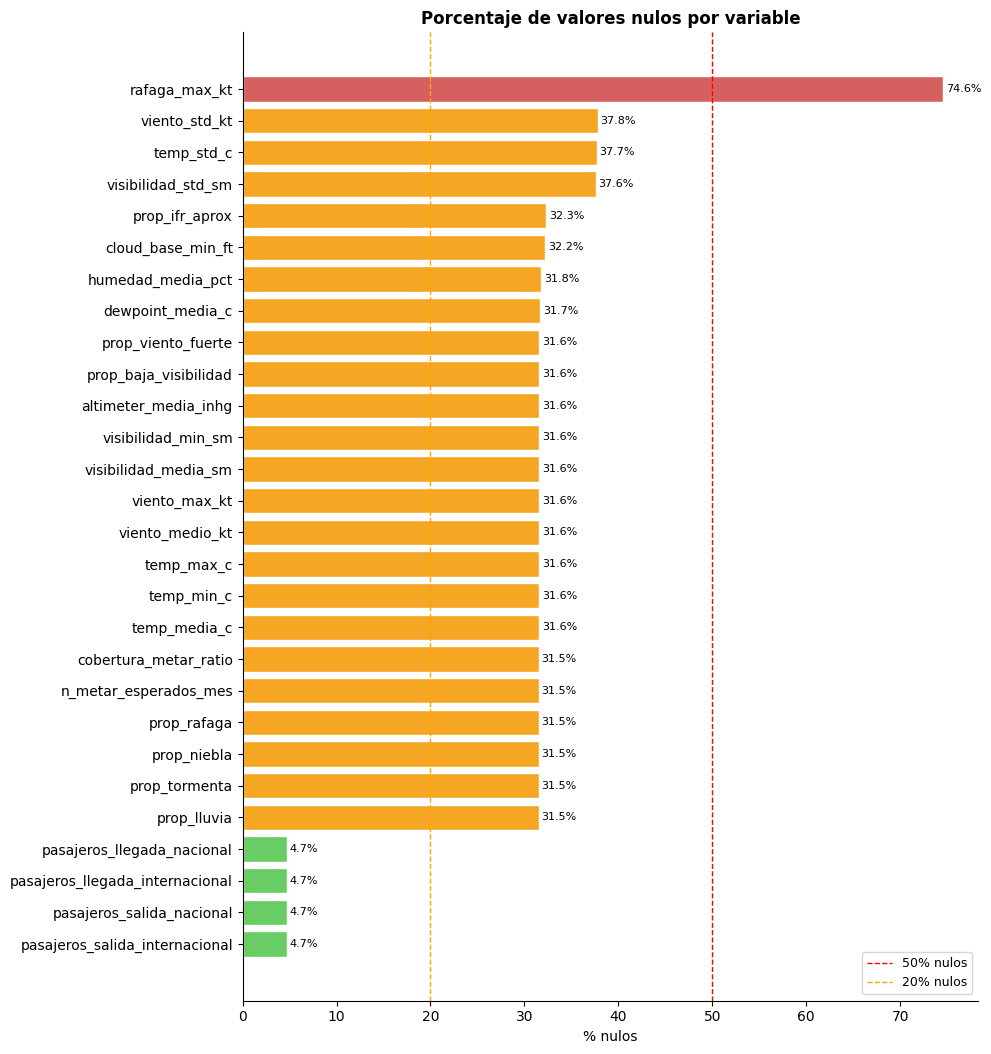

In [0]:
if len(nulos_plot_rows) == 0:
    print("No hay variables con valores nulos en el conjunto de entrenamiento.")

else:
    fig, ax = plt.subplots(
        figsize=(10, max(6, len(nulos_plot_rows) * 0.38))
    )

    colors_nulos = [
        "#D65F5F" if p > 50 else "#F5A623" if p > 20 else "#6ACC65"
        for p in pct_nulos_plot
    ]

    bars = ax.barh(
        variables_plot,
        pct_nulos_plot,
        color=colors_nulos,
        edgecolor="white",
    )

    for bar, val in zip(bars, pct_nulos_plot):
        ax.text(
            val + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            fontsize=8,
        )

    ax.axvline(
        50,
        color="red",
        linestyle="--",
        linewidth=1,
        label="50% nulos",
    )

    ax.axvline(
        20,
        color="orange",
        linestyle="--",
        linewidth=1,
        label="20% nulos",
    )

    ax.set_title(
        "Porcentaje de valores nulos por variable",
        fontweight="bold",
    )

    ax.set_xlabel("% nulos")
    ax.legend(fontsize=9)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

### 4.2 Nulos meteorológicos: patrón de ausencia por aeropuerto

In [0]:
pct_sin_metar = (
    df
    .groupBy("icao_code")
    .agg(
        (F.avg((F.col("tiene_metar_mes") == 0).cast("double")) * 100).alias("pct_sin_metar")
    )
)

n_sin_metar = pct_sin_metar.filter(F.col("pct_sin_metar") == 100).count()
n_con_metar_todos = pct_sin_metar.filter(F.col("pct_sin_metar") == 0).count()

print(f"Aeropuertos sin NINGÚN mes con METAR     : {n_sin_metar}")
print(f"Aeropuertos con TODOS los meses con METAR: {n_con_metar_todos}")

display(pct_sin_metar.orderBy(F.desc("pct_sin_metar")))

Aeropuertos sin NINGÚN mes con METAR     : 0
Aeropuertos con TODOS los meses con METAR: 12


icao_code,pct_sin_metar
SKTM,75.0
SKFL,73.21428571428571
SKSJ,73.21428571428571
SKBS,69.64285714285714
SKGI,69.64285714285714
SKBU,67.85714285714286
SKCZ,67.85714285714286
SKGP,67.85714285714286
SKPD,67.85714285714286
SKSA,67.85714285714286


## 5. Estrategia de imputación METAR

Esta sección implementa la estrategia de tratamiento de datos meteorológicos antes del modelado.  
Los aeropuertos del dataset se dividen en grupos según cobertura METAR.

### 5.1 Diagnóstico detallado de cobertura METAR

In [0]:
cobertura = (
    df
    .groupBy("icao_code")
    .agg(
        F.count("fecha_mes").alias("total_meses"),
        F.sum(F.col("tiene_metar_mes").cast("int")).alias("meses_con_metar"),
        F.first("name", ignorenulls=True).alias("nombre"),
        F.first("type", ignorenulls=True).alias("tipo"),
    )
    .withColumn(
        "pct_cobertura",
        F.round(
            F.col("meses_con_metar") / F.col("total_meses") * F.lit(100.0),
            1,
        )
    )
    .orderBy(F.desc("pct_cobertura"))
)

metar_perfecto = cobertura.filter(F.col("pct_cobertura") == 100)
metar_parcial = cobertura.filter(
    (F.col("pct_cobertura") > 0) &
    (F.col("pct_cobertura") < 100)
)
metar_ninguno = cobertura.filter(F.col("pct_cobertura") == 0)

print("── Resumen de cobertura METAR ──")
print("Total aeropuertos                   :", cobertura.count())
print("Con 100% cobertura METAR            :", metar_perfecto.count())
print("Con cobertura parcial               :", metar_parcial.count())
print("Sin ningún mes con METAR            :", metar_ninguno.count())

display(cobertura.orderBy(F.desc("pct_cobertura")))

── Resumen de cobertura METAR ──
Total aeropuertos                   : 46
Con 100% cobertura METAR            : 12
Con cobertura parcial               : 34
Sin ningún mes con METAR            : 0


icao_code,total_meses,meses_con_metar,nombre,tipo,pct_cobertura
SKAR,56,56,El Eden Airport,medium_airport,100.0
SKBG,56,56,Palonegro Airport,medium_airport,100.0
SKBO,56,56,El Dorado International Airport,large_airport,100.0
SKBQ,56,56,Ernesto Cortissoz International Airport,large_airport,100.0
SKCC,56,56,Camilo Daza International Airport,medium_airport,100.0
SKCG,56,56,Rafael Nuñez International Airport,large_airport,100.0
SKCL,56,56,Alfonso Bonilla Aragon International Airport,large_airport,100.0
SKLT,56,56,Alfredo Vásquez Cobo International Airport,medium_airport,100.0
SKPE,56,56,Matecaña International Airport,medium_airport,100.0
SKRG,56,56,Jose Maria Córdova International Airport,large_airport,100.0


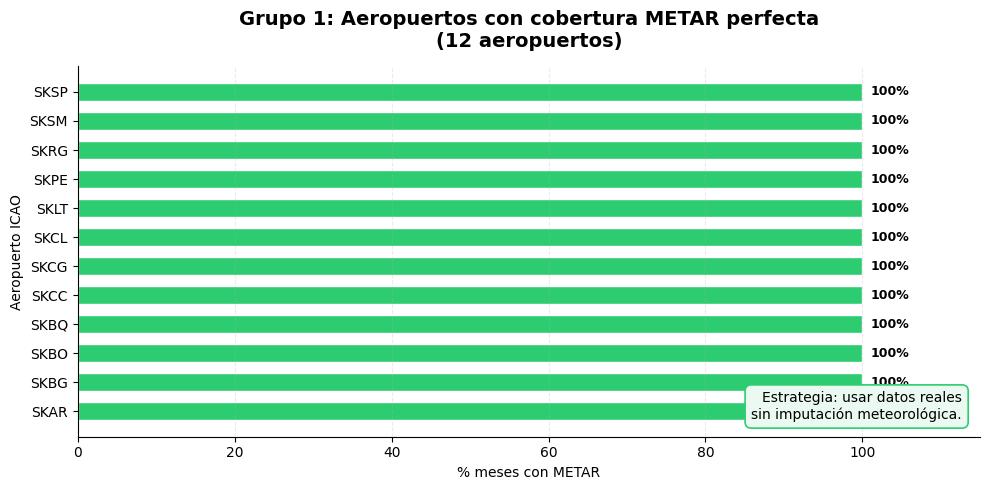

In [0]:
# Gráfica Grupo 1: Aeropuertos con 100% cobertura METAR

metar_perfecto_rows = (
    metar_perfecto
    .orderBy(F.asc("icao_code"))
    .collect()
)

icaos_g1 = [
    row["icao_code"]
    for row in metar_perfecto_rows
]

pct_g1 = [
    float(row["pct_cobertura"])
    for row in metar_perfecto_rows
]

if len(metar_perfecto_rows) == 0:
    print("No hay aeropuertos con 100% cobertura METAR.")

else:
    fig, ax = plt.subplots(figsize=(10, max(5, len(metar_perfecto_rows) * 0.35)))

    bars = ax.barh(
        icaos_g1,
        pct_g1,
        color="#2ecc71",
        edgecolor="white",
        height=0.6,
    )

    for bar, val in zip(bars, pct_g1):
        ax.text(
            val + 1.0,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%",
            va="center",
            fontsize=9,
            fontweight="bold",
        )

    ax.set_xlim(0, 115)
    ax.set_xlabel("% meses con METAR")
    ax.set_ylabel("Aeropuerto ICAO")

    ax.set_title(
        f"Grupo 1: Aeropuertos con cobertura METAR perfecta\n"
        f"({len(metar_perfecto_rows)} aeropuertos)",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )

    ax.text(
        0.98,
        0.04,
        "Estrategia: usar datos reales\nsin imputación meteorológica.",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.45",
            fc="#eafaf1",
            ec="#2ecc71",
            lw=1.2,
        ),
    )

    ax.grid(axis="x", linestyle="--", alpha=0.25)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

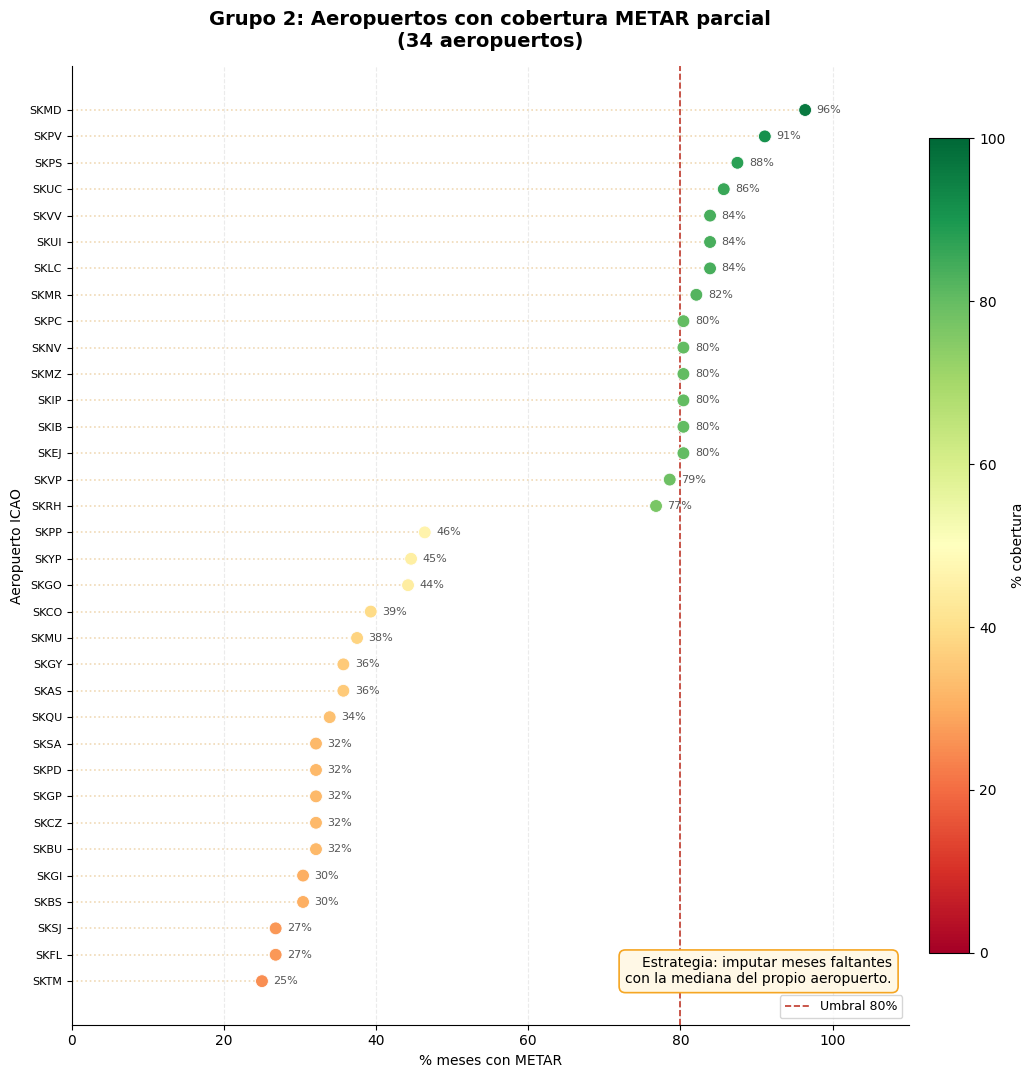

In [0]:
# Gráfica Grupo 2: Aeropuertos con cobertura METAR parcial

metar_parcial_rows = (
    metar_parcial
    .orderBy(F.asc("pct_cobertura"))
    .collect()
)

icaos_g2 = [
    row["icao_code"]
    for row in metar_parcial_rows
]

pct_g2 = [
    float(row["pct_cobertura"])
    for row in metar_parcial_rows
]

if len(metar_parcial_rows) == 0:
    print("No hay aeropuertos con cobertura METAR parcial.")

else:
    y_pos = np.arange(len(metar_parcial_rows))

    fig, ax = plt.subplots(figsize=(11, max(6, len(metar_parcial_rows) * 0.32)))

    ax.hlines(
        y_pos,
        0,
        pct_g2,
        colors="#f0d9b5",
        linewidth=1.2,
        linestyles="dotted",
    )

    sc = ax.scatter(
        pct_g2,
        y_pos,
        c=pct_g2,
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        s=85,
        zorder=3,
        edgecolors="white",
        linewidths=0.6,
    )

    ax.axvline(
        80,
        color="#c0392b",
        linestyle="--",
        linewidth=1.2,
        label="Umbral 80%",
    )

    for y, val in zip(y_pos, pct_g2):
        ax.text(
            val + 1.5,
            y,
            f"{val:.0f}%",
            va="center",
            fontsize=8,
            color="#555555",
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(icaos_g2, fontsize=8)

    ax.set_xlim(0, 110)
    ax.set_xlabel("% meses con METAR")
    ax.set_ylabel("Aeropuerto ICAO")

    ax.set_title(
        f"Grupo 2: Aeropuertos con cobertura METAR parcial\n"
        f"({len(metar_parcial_rows)} aeropuertos)",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )

    ax.text(
        0.98,
        0.04,
        "Estrategia: imputar meses faltantes\n"
        "con la mediana del propio aeropuerto.",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.45",
            fc="#fff8e6",
            ec="#F5A623",
            lw=1.2,
        ),
    )

    ax.legend(fontsize=9, loc="lower right")
    ax.grid(axis="x", linestyle="--", alpha=0.25)

    cbar = fig.colorbar(sc, ax=ax, label="% cobertura", shrink=0.85, pad=0.02)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

In [0]:
# Gráfica Grupo 3: Aeropuertos sin cobertura METAR

tipo_sin_metar_rows = (
    metar_ninguno
    .groupBy("tipo")
    .count()
    .orderBy(F.desc("count"))
    .collect()
)

tipos_g3 = [
    row["tipo"] if row["tipo"] is not None else "SIN_TIPO"
    for row in tipo_sin_metar_rows
]

conteos_g3 = [
    int(row["count"])
    for row in tipo_sin_metar_rows
]

n_metar_ninguno = metar_ninguno.count()

if len(tipo_sin_metar_rows) == 0:
    print("No hay aeropuertos sin METAR.")

else:
    fig, ax = plt.subplots(figsize=(9, 5.5))

    bars = ax.bar(
        tipos_g3,
        conteos_g3,
        color="#c0392b",
        edgecolor="white",
        width=0.55,
    )

    for bar, val in zip(bars, conteos_g3):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.5,
            str(val),
            ha="center",
            fontsize=11,
            fontweight="bold",
        )

    ax.set_title(
        f"Grupo 3: Aeropuertos sin cobertura METAR\n"
        f"({n_metar_ninguno} aeropuertos)",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )

    ax.set_xlabel("Tipo de aeropuerto")
    ax.set_ylabel("Número de aeropuertos")
    ax.tick_params(axis="x", rotation=25)

    ax.text(
        0.98,
        0.95,
        "Estrategia: imputar con 0.\n"
        "El flag tiene_metar_mes=0 actúa\n"
        "como señal explícita para el modelo.",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.45",
            fc="#fdf2f2",
            ec="#c0392b",
            lw=1.2,
        ),
    )

    ax.grid(axis="y", linestyle="--", alpha=0.25)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

No hay aeropuertos sin METAR.


## 6. Imputación sin fuga de información

- Fit solo con train.
- Transform en train, validación y test.

### 6.1 Definir columnas por tipo de imputación

In [0]:
VARS_OD_CERO = [
    "pasajeros_salida",
    "pasajeros_llegada",
    "pasajeros_total",
    "carga_salida_kg",
    "carga_llegada_kg",
    "carga_total_kg",
    "n_destinos_total",
    "n_origenes_total",
    "n_empresas_salida",
    "n_empresas_llegada",
    "n_registros_salida",
    "n_registros_llegada",
    "pasajeros_salida_internacional",
    "pasajeros_salida_nacional",
    "pasajeros_llegada_internacional",
    "pasajeros_llegada_nacional",
    "pasajeros_internacional_total",
    "proporcion_pasajeros_internacional",
]

VARS_PROP_METEO = [
    "prop_lluvia",
    "prop_tormenta",
    "prop_niebla",
    "prop_baja_visibilidad",
    "prop_viento_fuerte",
    "prop_rafaga",
    "prop_ifr_aprox",
]

VARS_CONT_METEO = [
    "temp_media_c",
    "temp_min_c",
    "temp_max_c",
    "temp_std_c",
    "dewpoint_media_c",
    "humedad_media_pct",
    "viento_medio_kt",
    "viento_max_kt",
    "viento_std_kt",
    "rafaga_max_kt",
    "visibilidad_media_sm",
    "visibilidad_min_sm",
    "visibilidad_std_sm",
    "cloud_base_min_ft",
    "altimeter_media_inhg",
]

VARS_AUX_METEO = [
    "n_metar_mes",
    "n_metar_esperados_mes",
    "cobertura_metar_ratio",
]

VARS_CAT_FILL = [
    "iata_code",
]

### 6.2 Función FIT: aprender parámetros solo desde train

In [0]:
def existing_cols(df: DataFrame, cols: list[str]) -> list[str]:
    return [col for col in cols if col in df.columns]


def percentile_median(col_name: str):
    return F.expr(f"percentile_approx(`{col_name}`, 0.5, 10000)")


def fit_imputacion_train_spark(df_train: DataFrame) -> dict:
    df_fit = normalizar_columna_fecha_mes(df_train, "fecha_mes")

    vars_od_cero = existing_cols(df_fit, VARS_OD_CERO)
    vars_prop_meteo = existing_cols(df_fit, VARS_PROP_METEO)
    vars_cont_meteo = existing_cols(df_fit, VARS_CONT_METEO)
    vars_aux_meteo = existing_cols(df_fit, VARS_AUX_METEO)
    vars_cat_fill = existing_cols(df_fit, VARS_CAT_FILL)

    medianas_globales = {}

    if vars_cont_meteo:
        agg_exprs = [
            percentile_median(col).alias(col)
            for col in vars_cont_meteo
        ]

        row = df_fit.agg(*agg_exprs).collect()[0].asDict()

        medianas_globales = {
            col: float(row[col]) if row[col] is not None else 0.0
            for col in vars_cont_meteo
        }

        mediana_cols = [
            percentile_median(col).alias(f"{col}__median_icao")
            for col in vars_cont_meteo
        ]

        medianas_por_aeropuerto_df = (
            df_fit
            .groupBy("icao_code")
            .agg(*mediana_cols)
        )
    else:
        medianas_por_aeropuerto_df = spark.createDataFrame([], "icao_code string")

    categorias_fill = {}

    for col in vars_cat_fill:
        moda = (
            df_fit
            .filter(F.col(col).isNotNull())
            .groupBy(col)
            .count()
            .orderBy(F.desc("count"), F.asc(col))
            .limit(1)
            .collect()
        )

        categorias_fill[col] = moda[0][col] if moda else "SIN_DATO"

    parametros = {
        "vars_od_cero": vars_od_cero,
        "vars_prop_meteo": vars_prop_meteo,
        "vars_cont_meteo": vars_cont_meteo,
        "vars_aux_meteo": vars_aux_meteo,
        "vars_cat_fill": vars_cat_fill,
        "medianas_por_aeropuerto_df": medianas_por_aeropuerto_df,
        "medianas_globales": medianas_globales,
        "categorias_fill": categorias_fill,
    }

    return parametros

### 6.3 Función TRANSFORM: aplicar parámetros aprendidos

In [0]:
def transform_imputacion_spark(df: DataFrame, parametros: dict) -> DataFrame:
    df_out = normalizar_columna_fecha_mes(df, "fecha_mes")

    vars_od_cero = parametros["vars_od_cero"]
    vars_prop_meteo = parametros["vars_prop_meteo"]
    vars_cont_meteo = parametros["vars_cont_meteo"]
    vars_cat_fill = parametros["vars_cat_fill"]
    medianas_por_aeropuerto_df = parametros["medianas_por_aeropuerto_df"]
    medianas_globales = parametros["medianas_globales"]
    categorias_fill = parametros["categorias_fill"]

    if vars_od_cero:
        df_out = df_out.fillna(0, subset=vars_od_cero)

    if "n_metar_mes" in df_out.columns:
        df_out = df_out.withColumn("n_metar_mes", F.coalesce(F.col("n_metar_mes"), F.lit(0)))

    if "n_metar_esperados_mes" in df_out.columns:
        df_out = df_out.withColumn(
            "n_metar_esperados_mes",
            F.dayofmonth(F.last_day("fecha_mes")) * F.lit(24),
        )

    if all(col in df_out.columns for col in ["cobertura_metar_ratio", "n_metar_mes", "n_metar_esperados_mes"]):
        df_out = df_out.withColumn(
            "cobertura_metar_ratio",
            safe_divide_expr("n_metar_mes", "n_metar_esperados_mes"),
        )

    if vars_prop_meteo:
        df_out = df_out.fillna(0, subset=vars_prop_meteo)

    if vars_cont_meteo:
        df_out = df_out.join(
            medianas_por_aeropuerto_df,
            on="icao_code",
            how="left",
        )

        for col in vars_cont_meteo:
            median_col = f"{col}__median_icao"
            global_median = medianas_globales.get(col, 0.0)

            df_out = df_out.withColumn(
                col,
                F.coalesce(
                    F.col(col).cast("double"),
                    F.col(median_col).cast("double"),
                    F.lit(float(global_median)),
                    F.lit(0.0),
                )
            )

        df_out = df_out.drop(*[f"{col}__median_icao" for col in vars_cont_meteo])

    for col in vars_cat_fill:
        df_out = df_out.withColumn(
            col,
            F.coalesce(
                F.col(col).cast("string"),
                F.lit(str(categorias_fill[col])),
                F.lit("SIN_DATO"),
            )
        )

    return df_out

### 6.4 FIT con train

In [0]:
parametros_imputacion = fit_imputacion_train_spark(df_train)

### 6.5 TRANSFORM en train, validation y test

In [0]:
df_train_model = transform_imputacion_spark(
    df_train,
    parametros_imputacion,
)

df_val_model = transform_imputacion_spark(
    df_valid,
    parametros_imputacion,
)

df_test_model = transform_imputacion_spark(
    df_test,
    parametros_imputacion,
)

### 6.6 Verificación final

In [0]:
def count_total_nulls(df: DataFrame) -> int:
    exprs = [
        F.sum(F.col(col).isNull().cast("int")).alias(col)
        for col in df.columns
    ]

    row = df.agg(*exprs).collect()[0].asDict()

    return int(sum(value or 0 for value in row.values()))


print("Train imputado:", (df_train_model.count(), len(df_train_model.columns)))
print("Validation imputado:", (df_val_model.count(), len(df_val_model.columns)))
print("Test imputado:", (df_test_model.count(), len(df_test_model.columns)))

print()
print("Nulos train:", count_total_nulls(df_train_model))
print("Nulos validation:", count_total_nulls(df_val_model))
print("Nulos test:", count_total_nulls(df_test_model))

Train imputado: (2572, 66)
Validation imputado: (319, 66)
Test imputado: (363, 66)

Nulos train: 0
Nulos validation: 0
Nulos test: 0


In [0]:
df = df_train_model

cobertura_metar = (
    df
    .groupBy("icao_code")
    .agg(
        F.count("fecha_mes").alias("total_meses"),
        F.sum(F.col("tiene_metar_mes").cast("int")).alias("meses_con_metar"),
    )
    .withColumn(
        "pct_cobertura",
        F.col("meses_con_metar") / F.col("total_meses") * F.lit(100.0)
    )
)

metar_perfecto = cobertura_metar.filter(
    F.col("pct_cobertura") == 100
)

metar_parcial = cobertura_metar.filter(
    (F.col("pct_cobertura") > 0) &
    (F.col("pct_cobertura") < 100)
)

metar_ninguno = cobertura_metar.filter(
    F.col("pct_cobertura") == 0
)

icaos_parcial = [
    row["icao_code"]
    for row in metar_parcial.select("icao_code").collect()
]

icaos_sin_metar = [
    row["icao_code"]
    for row in metar_ninguno.select("icao_code").collect()
]

print("Aeropuertos con METAR perfecto:", metar_perfecto.count())
print("Aeropuertos con METAR parcial :", len(icaos_parcial))
print("Aeropuertos sin METAR         :", len(icaos_sin_metar))

Aeropuertos con METAR perfecto: 12
Aeropuertos con METAR parcial : 34
Aeropuertos sin METAR         : 0


## 7. Validación visual: distribuciones antes vs después

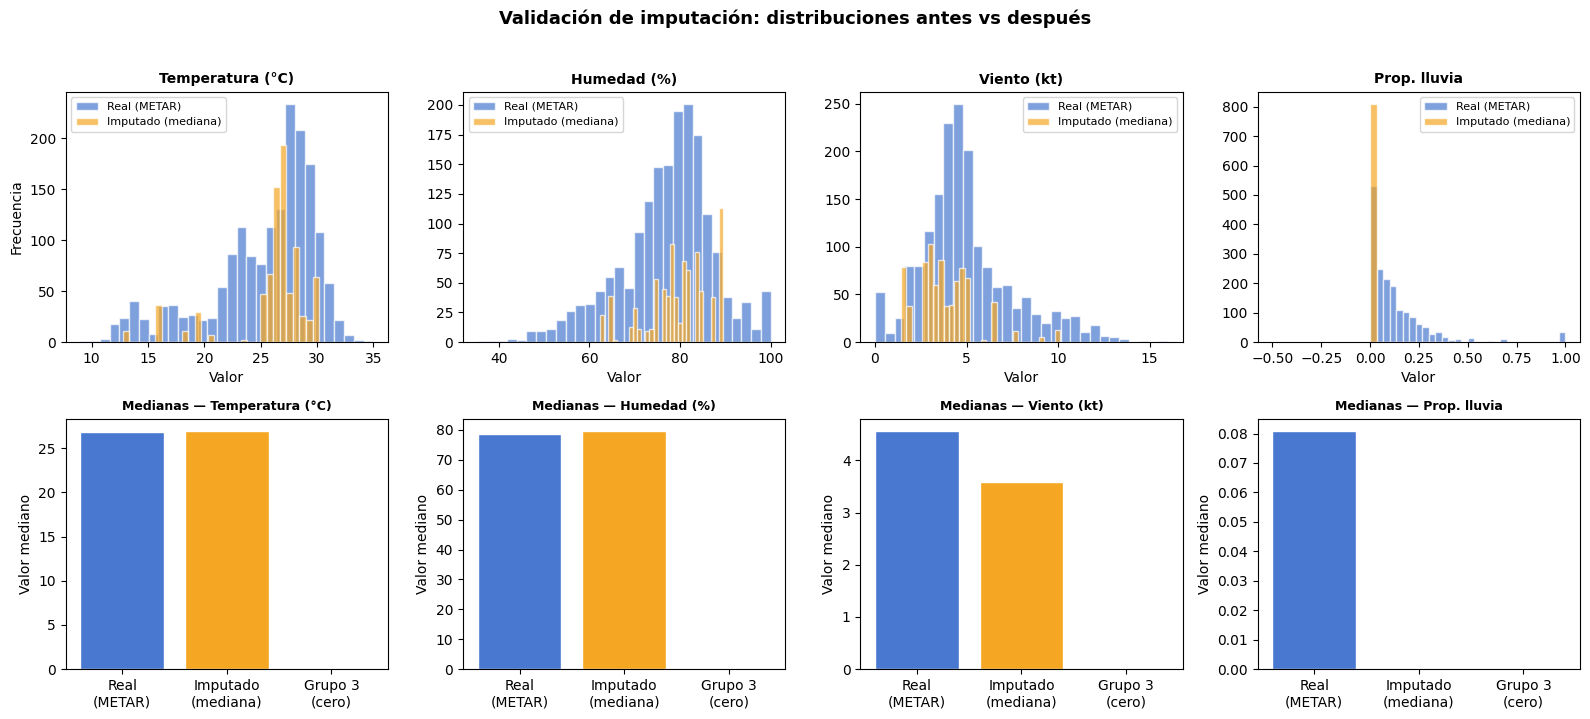

In [0]:
vars_check = [
    "temp_media_c",
    "humedad_media_pct",
    "viento_medio_kt",
    "prop_lluvia",
]

labels_check = [
    "Temperatura (°C)",
    "Humedad (%)",
    "Viento (kt)",
    "Prop. lluvia",
]


def collect_numeric_values(df_spark: DataFrame, col_name: str) -> list[float]:
    return [
        float(row[col_name])
        for row in (
            df_spark
            .select(F.col(col_name).cast("double").alias(col_name))
            .filter(F.col(col_name).isNotNull())
            .collect()
        )
    ]


fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, (col, label) in enumerate(zip(vars_check, labels_check)):

    # Antes: solo registros con METAR real
    data_antes = collect_numeric_values(
        df.filter(F.col("tiene_metar_mes").cast("int") == 1),
        col,
    )

    # Después: Grupo 2 en meses sin METAR, ya imputados en df_train_model
    data_imputed = collect_numeric_values(
        df.filter(
            (F.col("icao_code").isin(icaos_parcial)) &
            (F.col("tiene_metar_mes").cast("int") == 0)
        ),
        col,
    )

    mediana_real = (
        float(np.median(data_antes))
        if len(data_antes) > 0
        else 0.0
    )

    mediana_imputada = (
        float(np.median(data_imputed))
        if len(data_imputed) > 0
        else 0.0
    )

    axes[0, i].hist(
        data_antes,
        bins=30,
        color="#4878CF",
        edgecolor="white",
        alpha=0.7,
        label="Real (METAR)",
    )

    axes[0, i].hist(
        data_imputed,
        bins=30,
        color="#F5A623",
        edgecolor="white",
        alpha=0.7,
        label="Imputado (mediana)",
    )

    axes[0, i].set_title(
        label,
        fontweight="bold",
        fontsize=10,
    )

    axes[0, i].legend(fontsize=8)
    axes[0, i].set_xlabel("Valor")

    if i == 0:
        axes[0, i].set_ylabel("Frecuencia")

    axes[1, i].bar(
        [
            "Real\n(METAR)",
            "Imputado\n(mediana)",
            "Grupo 3\n(cero)",
        ],
        [
            mediana_real,
            mediana_imputada,
            0,
        ],
        color=[
            "#4878CF",
            "#F5A623",
            "#c0392b",
        ],
        edgecolor="white",
    )

    axes[1, i].set_title(
        f"Medianas — {label}",
        fontweight="bold",
        fontsize=9,
    )

    axes[1, i].set_ylabel("Valor mediano")

plt.suptitle(
    "Validación de imputación: distribuciones antes vs después",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

In [0]:
for col in vars_check:
    n_real = (
        df
        .filter(F.col("tiene_metar_mes").cast("int") == 1)
        .filter(F.col(col).isNotNull())
        .count()
    )

    n_imputado = (
        df
        .filter(
            (F.col("icao_code").isin(icaos_parcial)) &
            (F.col("tiene_metar_mes").cast("int") == 0)
        )
        .filter(F.col(col).isNotNull())
        .count()
    )

    print(col, "real:", n_real, "| imputado:", n_imputado)

temp_media_c real: 1762 | imputado: 810
humedad_media_pct real: 1762 | imputado: 810
viento_medio_kt real: 1762 | imputado: 810
prop_lluvia real: 1762 | imputado: 810


## 8 Disponibilidad METAR vs target

### 8.1. Preparar datos

In [0]:
df_viz = df

TARGET_COL = "target_nivel_operacion_mes_siguiente"
TARGET_ORDER = ["bajo", "medio", "alto"]

# Crear variable categórica de disponibilidad METAR
df_viz = (
    df_viz
    .withColumn(
        "estado_metar",
        F.when(F.col("tiene_metar_mes").cast("int") == 0, F.lit("Sin METAR"))
        .when(F.col("tiene_metar_mes").cast("int") == 1, F.lit("Con METAR"))
        .otherwise(F.lit(None).cast("string"))
    )
    .filter(
        F.col("estado_metar").isNotNull() &
        F.col(TARGET_COL).isNotNull()
    )
)

# Conteos por disponibilidad METAR y clase target
tabla_counts = (
    df_viz
    .groupBy("estado_metar", TARGET_COL)
    .agg(
        F.count("*").alias("n")
    )
)

# Totales por disponibilidad METAR
tabla_totales = (
    df_viz
    .groupBy("estado_metar")
    .agg(
        F.count("*").alias("total_estado")
    )
)

# Asegurar combinaciones completas:
# Sin METAR / Con METAR × bajo / medio / alto
combinaciones_rows = [
    {
        "estado_metar": estado,
        TARGET_COL: clase,
    }
    for estado in ["Sin METAR", "Con METAR"]
    for clase in TARGET_ORDER
]

schema_combinaciones = T.StructType([
    T.StructField("estado_metar", T.StringType(), True),
    T.StructField(TARGET_COL, T.StringType(), True),
])

combinaciones = spark.createDataFrame(
    combinaciones_rows,
    schema=schema_combinaciones,
)

tabla = (
    combinaciones
    .join(
        tabla_counts,
        on=["estado_metar", TARGET_COL],
        how="left",
    )
    .join(
        tabla_totales,
        on="estado_metar",
        how="left",
    )
    .fillna(
        {
            "n": 0,
            "total_estado": 0,
        }
    )
    .withColumn(
        "pct",
        F.when(
            F.col("total_estado") > 0,
            F.col("n") / F.col("total_estado") * F.lit(100.0),
        ).otherwise(F.lit(0.0))
    )
)

display(
    tabla
    .orderBy("estado_metar", TARGET_COL)
)

# Diccionario de totales para usar en el subtítulo
totales = {
    row["estado_metar"]: int(row["total_estado"])
    for row in tabla_totales.collect()
}

n_sin = totales.get("Sin METAR", 0)
n_con = totales.get("Con METAR", 0)

# Diccionario tipo pivot:
# pivot_lookup[(clase, estado_metar)] = porcentaje
pivot_lookup = {
    (row[TARGET_COL], row["estado_metar"]): float(row["pct"])
    for row in tabla.collect()
}

estado_metar,target_nivel_operacion_mes_siguiente,n,total_estado,pct
Con METAR,alto,691,1762,39.21679909194097
Con METAR,bajo,506,1762,28.717366628830877
Con METAR,medio,565,1762,32.06583427922815
Sin METAR,alto,161,810,19.876543209876544
Sin METAR,bajo,382,810,47.160493827160494
Sin METAR,medio,267,810,32.96296296296296


### 8.2. Configuración visual

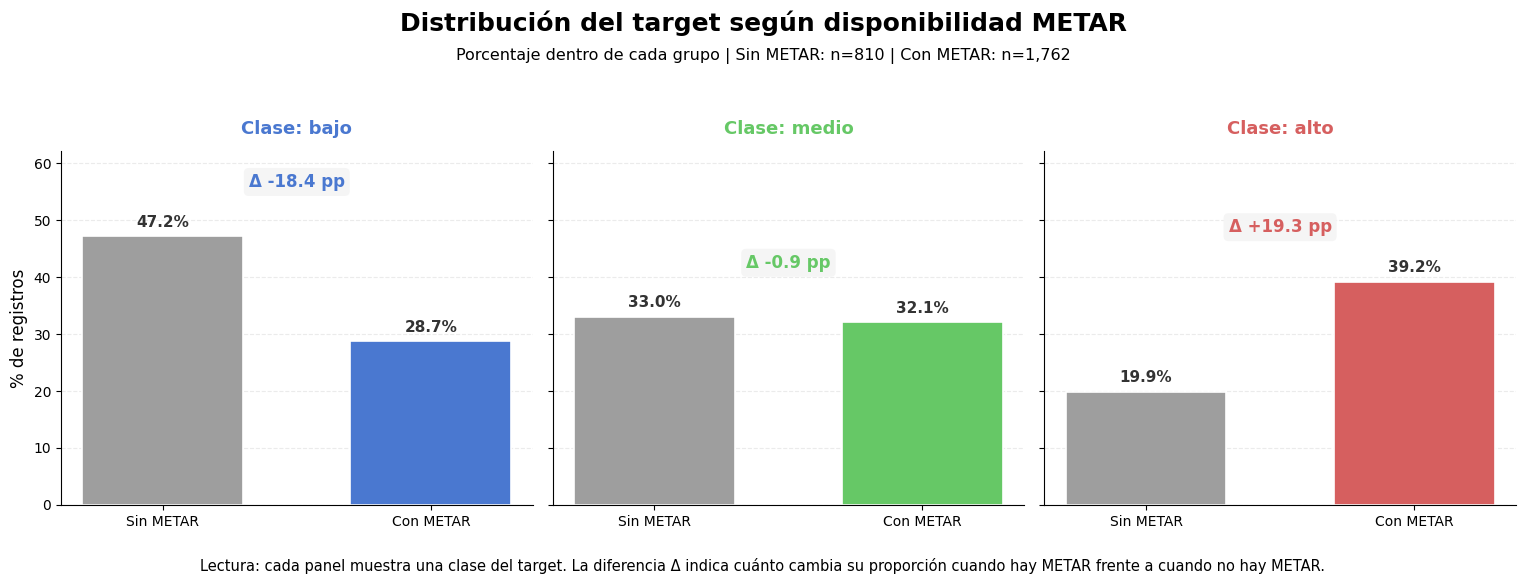

In [0]:
colors = {
    "bajo": "#4A78D0",
    "medio": "#66C866",
    "alto": "#D65F5F",
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5.5),
    sharey=True,
)

fig.patch.set_facecolor("white")

# Una gráfica por categoría del target
for ax, nivel in zip(axes, TARGET_ORDER):
    ax.set_facecolor("white")

    valores = [
        pivot_lookup.get((nivel, "Sin METAR"), 0.0),
        pivot_lookup.get((nivel, "Con METAR"), 0.0),
    ]

    etiquetas = [
        "Sin METAR",
        "Con METAR",
    ]

    colores_barras = [
        "#9E9E9E",
        colors[nivel],
    ]

    bars = ax.bar(
        etiquetas,
        valores,
        color=colores_barras,
        edgecolor="white",
        linewidth=1.2,
        width=0.6,
    )

    # Etiquetas de porcentaje encima de las barras
    for bar, val in zip(bars, valores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.2,
            f"{val:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color="#333333",
        )

    # Delta en puntos porcentuales
    delta = valores[1] - valores[0]
    signo = "+" if delta >= 0 else ""

    ax.text(
        0.5,
        max(valores) + 8,
        f"Δ {signo}{delta:.1f} pp",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=colors[nivel],
        bbox=dict(
            boxstyle="round,pad=0.30",
            facecolor="#F5F5F5",
            edgecolor="none",
            alpha=0.95,
        ),
        transform=ax.transData,
    )

    ax.set_title(
        f"Clase: {nivel}",
        fontsize=13,
        fontweight="bold",
        color=colors[nivel],
        pad=12,
    )

    ax.set_ylim(
        0,
        max(
            45,
            max(pivot_lookup.values()) + 15
            if pivot_lookup
            else 45,
        ),
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25,
    )

    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# Títulos generales
fig.suptitle(
    "Distribución del target según disponibilidad METAR",
    fontsize=18,
    fontweight="bold",
    y=1.03,
)

fig.text(
    0.5,
    0.94,
    f"Porcentaje dentro de cada grupo | Sin METAR: n={n_sin:,} | Con METAR: n={n_con:,}",
    ha="center",
    fontsize=11.5,
    color="#000000",
)

axes[0].set_ylabel(
    "% de registros",
    fontsize=12,
)

fig.text(
    0.5,
    0.01,
    "Lectura: cada panel muestra una clase del target. "
    "La diferencia Δ indica cuánto cambia su proporción cuando hay METAR frente a cuando no hay METAR.",
    ha="center",
    fontsize=10.5,
    color="#000000",
)

plt.tight_layout(
    rect=[0.02, 0.06, 0.98, 0.93]
)

plt.show()

## 9. Conclusiones para el modelado

In [0]:
TARGET_COL = "target_nivel_operacion_mes_siguiente"
TARGET_NUM_COL = "target_operaciones_total_mes_siguiente"

# ------------------------------------------------------------
# 1. Distribución del target en el dataset de trabajo
# ------------------------------------------------------------

print("Distribución del target en df:")
display(
    df
    .groupBy(TARGET_COL)
    .count()
    .orderBy(TARGET_COL)
)

# ------------------------------------------------------------
# 2. Concatenar train, validation y test para conclusiones
# ------------------------------------------------------------

df_train_conc = df_train_model.withColumn("split", F.lit("train"))
df_val_conc = df_val_model.withColumn("split", F.lit("validation"))
df_test_conc = df_test_model.withColumn("split", F.lit("test"))

df_conclusiones = (
    df_train_conc
    .unionByName(df_val_conc, allowMissingColumns=True)
    .unionByName(df_test_conc, allowMissingColumns=True)
    .withColumn("fecha_mes", F.to_date(F.col("fecha_mes")))
)

n_filas_conclusiones = df_conclusiones.count()
n_columnas_conclusiones = len(df_conclusiones.columns)
n_aeropuertos_conclusiones = df_conclusiones.select("icao_code").distinct().count()

print("Dataset concatenado para conclusiones:")
print("Filas:", n_filas_conclusiones)
print("Columnas:", n_columnas_conclusiones)

print("\nFilas por split:")
display(
    df_conclusiones
    .groupBy("split")
    .count()
    .orderBy("split")
)

print("\nAeropuertos:", n_aeropuertos_conclusiones)

# ------------------------------------------------------------
# 3. Cobertura METAR por aeropuerto
# ------------------------------------------------------------

cobertura_metar_conclusiones = (
    df_conclusiones
    .groupBy("icao_code")
    .agg(
        F.count("fecha_mes").alias("total_meses"),
        F.sum(F.col("tiene_metar_mes").cast("int")).alias("meses_con_metar"),
    )
    .withColumn(
        "pct_cobertura",
        F.col("meses_con_metar") / F.col("total_meses") * F.lit(100.0)
    )
)

metar_perfecto_conclusiones = cobertura_metar_conclusiones.filter(
    F.col("pct_cobertura") == 100
)

metar_parcial_conclusiones = cobertura_metar_conclusiones.filter(
    (F.col("pct_cobertura") > 0) &
    (F.col("pct_cobertura") < 100)
)

metar_ninguno_conclusiones = cobertura_metar_conclusiones.filter(
    F.col("pct_cobertura") == 0
)

n_grupo1 = metar_perfecto_conclusiones.count()
n_grupo2 = metar_parcial_conclusiones.count()
n_grupo3 = metar_ninguno_conclusiones.count()

print("\nGrupos de cobertura METAR:")
print("Grupo 1 - Cobertura perfecta:", n_grupo1)
print("Grupo 2 - Cobertura parcial :", n_grupo2)
print("Grupo 3 - Sin METAR         :", n_grupo3)

# ------------------------------------------------------------
# 4. Distribución del target categórico
# ------------------------------------------------------------

target_rows = (
    df_conclusiones
    .groupBy(TARGET_COL)
    .count()
    .collect()
)

target_counts = {
    row[TARGET_COL]: int(row["count"])
    for row in target_rows
}

target_dist = {
    clase: round(target_counts.get(clase, 0) / n_filas_conclusiones * 100.0, 1)
    for clase in ["bajo", "medio", "alto"]
}

pct_bajo = target_dist.get("bajo", 0.0)
pct_medio = target_dist.get("medio", 0.0)
pct_alto = target_dist.get("alto", 0.0)

desbalance_pp = max(target_dist.values()) - min(target_dist.values())

recomendacion_balance = (
    "No se requiere oversampling para el modelo base"
    if desbalance_pp <= 10
    else "Conviene evaluar balanceo de clases o pesos por clase"
)

# ------------------------------------------------------------
# 5. Correlaciones Spearman locales para conclusiones
#    Compatible con Databricks Serverless.
# ------------------------------------------------------------

def obtener_columnas_numericas_spark(
    df_spark: DataFrame,
    excluir: list[str] | None = None,
) -> list[str]:
    if excluir is None:
        excluir = []

    numeric_types = {
        "byte",
        "short",
        "int",
        "bigint",
        "long",
        "float",
        "double",
        "decimal",
    }

    cols_numeric = []

    for field in df_spark.schema.fields:
        dtype = field.dataType.simpleString().lower()

        if field.name in excluir:
            continue

        if any(dtype.startswith(t) for t in numeric_types):
            cols_numeric.append(field.name)

    return cols_numeric


def average_rank_numpy(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)

    order = np.argsort(values, kind="mergesort")
    sorted_values = values[order]

    ranks_sorted = np.zeros(len(values), dtype=float)

    i = 0

    while i < len(values):
        j = i

        while j + 1 < len(values) and sorted_values[j + 1] == sorted_values[i]:
            j += 1

        avg_rank = (i + j) / 2.0 + 1.0
        ranks_sorted[i:j + 1] = avg_rank

        i = j + 1

    ranks = np.empty(len(values), dtype=float)
    ranks[order] = ranks_sorted

    return ranks


def spearman_corr_numpy(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return float("nan")

    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return float("nan")

    rx = average_rank_numpy(x)
    ry = average_rank_numpy(y)

    return float(np.corrcoef(rx, ry)[0, 1])


cols_excluir_corr = [
    "target_q33_operaciones",
    "target_q66_operaciones",
]

cols_numericas_conclusiones = obtener_columnas_numericas_spark(
    df_conclusiones,
    excluir=cols_excluir_corr,
)

if TARGET_NUM_COL not in cols_numericas_conclusiones:
    cols_numericas_conclusiones.append(TARGET_NUM_COL)

cols_numericas_conclusiones = [
    col
    for col in dict.fromkeys(cols_numericas_conclusiones)
    if col in df_conclusiones.columns
]

rows_corr = (
    df_conclusiones
    .select(
        [
            F.col(col).cast("double").alias(col)
            for col in cols_numericas_conclusiones
        ]
    )
    .collect()
)

data_corr = {
    col: np.array(
        [
            float(row[col]) if row[col] is not None else np.nan
            for row in rows_corr
        ],
        dtype=float,
    )
    for col in cols_numericas_conclusiones
}

corr_spearman = {}

if TARGET_NUM_COL in data_corr:
    y_target = data_corr[TARGET_NUM_COL]

    for col in cols_numericas_conclusiones:
        if col == TARGET_NUM_COL:
            continue

        corr_value = spearman_corr_numpy(
            data_corr[col],
            y_target,
        )

        if not math.isnan(corr_value):
            corr_spearman[col] = corr_value

corr_operaciones_total = corr_spearman.get("operaciones_total", float("nan"))
corr_pasajeros_total = corr_spearman.get("pasajeros_total", float("nan"))
corr_destinos_total = corr_spearman.get("n_destinos_total", float("nan"))

# Variables meteorológicas disponibles.
vars_meteo_conclusiones = [
    "temp_media_c",
    "temp_min_c",
    "temp_max_c",
    "humedad_media_pct",
    "viento_medio_kt",
    "viento_max_kt",
    "visibilidad_media_sm",
    "cloud_base_min_ft",
    "prop_lluvia",
    "prop_tormenta",
    "prop_niebla",
    "prop_baja_visibilidad",
    "prop_viento_fuerte",
    "prop_rafaga",
    "prop_ifr_aprox",
    "cobertura_metar_ratio",
]

vars_meteo_conclusiones = [
    col
    for col in vars_meteo_conclusiones
    if col in corr_spearman
]

if vars_meteo_conclusiones:
    variable_meteo_top = max(
        vars_meteo_conclusiones,
        key=lambda col: abs(corr_spearman[col]),
    )

    corr_meteo_top = corr_spearman[variable_meteo_top]

else:
    variable_meteo_top = "sin variable meteorológica disponible"
    corr_meteo_top = float("nan")

# ------------------------------------------------------------
# 6. Concentración operacional por aeropuerto
# ------------------------------------------------------------

ops_por_aeropuerto = (
    df_conclusiones
    .groupBy("icao_code")
    .agg(
        F.sum("operaciones_total").alias("operaciones_total")
    )
    .orderBy(F.desc("operaciones_total"))
)

n_aeropuertos_ops = ops_por_aeropuerto.count()
n_top_10 = max(1, int(math.ceil(n_aeropuertos_ops * 0.10)))

total_operaciones = (
    ops_por_aeropuerto
    .agg(F.sum("operaciones_total").alias("total_operaciones"))
    .collect()[0]["total_operaciones"]
)

top_operaciones = (
    ops_por_aeropuerto
    .limit(n_top_10)
    .agg(F.sum("operaciones_total").alias("top_operaciones"))
    .collect()[0]["top_operaciones"]
)

participacion_top_10 = (
    float(top_operaciones) / float(total_operaciones) * 100.0
    if total_operaciones and total_operaciones > 0
    else float("nan")
)

# ------------------------------------------------------------
# 7. Efecto temporal tipo COVID / año crítico
# ------------------------------------------------------------

ops_por_anio_rows = (
    df_conclusiones
    .withColumn("anio", F.year("fecha_mes"))
    .groupBy("anio")
    .agg(
        F.sum("operaciones_total").alias("operaciones_total")
    )
    .orderBy("anio")
    .collect()
)

anio_min_operaciones = min(
    ops_por_anio_rows,
    key=lambda row: row["operaciones_total"],
)["anio"]

ops_2020_rows = [
    row
    for row in ops_por_anio_rows
    if row["anio"] == 2020
]

otros_anios_ops = [
    float(row["operaciones_total"])
    for row in ops_por_anio_rows
    if row["anio"] != 2020
]

if ops_2020_rows and len(otros_anios_ops) > 0:
    ops_2020 = float(ops_2020_rows[0]["operaciones_total"])
    promedio_otros_anios = sum(otros_anios_ops) / len(otros_anios_ops)

    caida_2020_pct = (
        (1 - ops_2020 / promedio_otros_anios) * 100.0
        if promedio_otros_anios > 0
        else float("nan")
    )

else:
    caida_2020_pct = float("nan")

if not math.isnan(caida_2020_pct) and caida_2020_pct > 10:
    recomendacion_covid = (
        f"2020 presenta una caída aproximada de {caida_2020_pct:.1f}% "
        "frente al promedio de los otros años; incluir flag año_covid"
    )
else:
    recomendacion_covid = (
        f"Año con menor operación: {anio_min_operaciones}; "
        "evaluar variable temporal antes de definir un flag COVID"
    )

# ------------------------------------------------------------
# 8. Funciones de formato para caja final
# ------------------------------------------------------------

BOX_WIDTH = 80
CONTENT_WIDTH = BOX_WIDTH - 4


def fmt_float(value, decimals=3):
    if value is None:
        return "N/D"

    try:
        value = float(value)
    except Exception:
        return "N/D"

    if math.isnan(value):
        return "N/D"

    return f"{value:.{decimals}f}"


def fmt_pct(value, decimals=1):
    if value is None:
        return "N/D"

    try:
        value = float(value)
    except Exception:
        return "N/D"

    if math.isnan(value):
        return "N/D"

    return f"{value:.{decimals}f}%"


def box_top():
    print("╔" + "═" * (BOX_WIDTH - 2) + "╗")


def box_middle():
    print("╠" + "═" * (BOX_WIDTH - 2) + "╣")


def box_bottom():
    print("╚" + "═" * (BOX_WIDTH - 2) + "╝")


def box_blank():
    print("║" + " " * (BOX_WIDTH - 2) + "║")


def box_line(text=""):
    text = str(text)
    print("║ " + text[:CONTENT_WIDTH].ljust(CONTENT_WIDTH) + " ║")


def box_title(text):
    text = str(text)
    print("║ " + text.center(CONTENT_WIDTH) + " ║")


def box_section(text):
    box_blank()
    box_line(f" {text.upper()}")


def box_wrapped(text, indent=2):
    text = str(text)
    prefix = " " * indent
    width = CONTENT_WIDTH - indent

    wrapped_lines = textwrap.wrap(
        text,
        width=width,
        break_long_words=False,
        replace_whitespace=False,
    )

    if not wrapped_lines:
        box_line(prefix)
        return

    for line in wrapped_lines:
        box_line(prefix + line)


def box_bullet(text):
    box_wrapped("• " + str(text), indent=2)


def box_number(number, text):
    box_wrapped(f"{number}. {text}", indent=2)

# ------------------------------------------------------------
# 9. Caja final de conclusiones
# ------------------------------------------------------------

box_top()
box_title("CONCLUSIONES EDA — CLASIFICACIÓN OPERACIÓN AEROPORTUARIA")
box_middle()

box_section("Dataset final")
box_bullet("Dataset usado para modelado: df_model")
box_bullet(f"Filas finales: {n_filas_conclusiones:,}")
box_bullet(f"Aeropuertos finales: {n_aeropuertos_conclusiones:,}")

box_section("Target")
box_bullet(
    f"Distribución: bajo {pct_bajo:.1f}%, medio {pct_medio:.1f}%, "
    f"alto {pct_alto:.1f}%"
)
box_bullet(recomendacion_balance)
box_bullet(
    "Umbrales P33/P66 calculados por aeropuerto, relativos a su historial"
)

box_section("Variables operacionales")
box_bullet(
    f"operaciones_total vs target: Spearman = "
    f"{fmt_float(corr_operaciones_total, 3)}"
)
box_bullet(
    f"pasajeros_total vs target: Spearman = "
    f"{fmt_float(corr_pasajeros_total, 3)}"
)
box_bullet(
    f"n_destinos_total vs target: Spearman = "
    f"{fmt_float(corr_destinos_total, 3)}"
)
box_bullet(
    f"Top 10% de aeropuertos concentra "
    f"{fmt_pct(participacion_top_10, 1)} de las operaciones"
)
box_bullet(recomendacion_covid)

box_section("Variables meteorológicas")
box_bullet(
    f"Variable meteorológica más asociada al target: {variable_meteo_top}"
)
box_bullet(
    f"Correlación Spearman de esa variable: {fmt_float(corr_meteo_top, 3)}"
)
box_bullet(
    "La señal meteorológica es complementaria frente a la señal operacional"
)

box_section("Estrategia METAR aplicada")
box_bullet(
    f"Grupo 1 — {n_grupo1} aeropuertos con 100% cobertura: usar datos reales"
)
box_bullet(
    f"Grupo 2 — {n_grupo2} aeropuertos con cobertura parcial: imputar "
    "faltantes mediante la mediana del propio aeropuerto"
)

if n_grupo3 > 0:
    box_bullet(
        f"Grupo 3 — {n_grupo3} aeropuertos sin METAR: imputar 0 y usar "
        "tiene_metar_mes=0 como señal explícita para el modelo"
    )
else:
    box_bullet(
        f"Grupo 3 — {n_grupo3} aeropuertos sin METAR: no aplica en este "
        "dataset, porque todos los aeropuertos tienen al menos cobertura "
        "parcial IEM"
    )

box_bullet(
    "El flag tiene_metar_mes permite distinguir datos reales de datos imputados"
)

box_section("Recomendaciones para el modelo")
box_number(1, "Usar df_model como dataset de entrada al entrenamiento")
box_number(2, "Aplicar validación temporal, evitando shuffle aleatorio")
box_number(3, "Agregar variables de rezago operacional")
box_number(4, "Codificar estacionalidad con seno/coseno del mes")
box_number(5, "Comparar contra baseline de persistencia temporal")

box_blank()
box_bottom()

Distribución del target en df:


target_nivel_operacion_mes_siguiente,count
alto,852
bajo,888
medio,832


Dataset concatenado para conclusiones:
Filas: 3254
Columnas: 67

Filas por split:


split,count
test,363
train,2572
validation,319



Aeropuertos: 46

Grupos de cobertura METAR:
Grupo 1 - Cobertura perfecta: 12
Grupo 2 - Cobertura parcial : 34
Grupo 3 - Sin METAR         : 0
╔══════════════════════════════════════════════════════════════════════════════╗
║           CONCLUSIONES EDA — CLASIFICACIÓN OPERACIÓN AEROPORTUARIA           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  DATASET FINAL                                                               ║
║   • Dataset usado para modelado: df_model                                    ║
║   • Filas finales: 3,254                                                     ║
║   • Aeropuertos finales: 46                                                  ║
║                                                                              ║
║  TARGET                                                                      ║
║   • Distribución: bajo 32.9%, medio 33.1%, al

In [0]:
write_spark_parquet_dataset(
    df_train_model,
    GOLD_MONTHLY_DIR / "dataset_train.parquet",
)

write_spark_parquet_dataset(
    df_val_model,
    GOLD_MONTHLY_DIR / "dataset_valid.parquet",
)

write_spark_parquet_dataset(
    df_test_model,
    GOLD_MONTHLY_DIR / "dataset_test.parquet",
)

[INFO] Preparando escritura: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/dataset_train.parquet
[INFO] Columnas: 66
[INFO] Iniciando writer.parquet(...)
[INFO] Escritura física terminada.
[INFO] Calculando número de filas con df.count()...
[INFO] Conteo terminado: 2,572 filas.
[OK] Dataset Parquet Spark guardado: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/dataset_train.parquet | filas=2,572 | columnas=66 | part-files=1
[INFO] Preparando escritura: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/dataset_valid.parquet
[INFO] Columnas: 66
[INFO] Iniciando writer.parquet(...)
[INFO] Escritura física terminada.
[INFO] Calculando número de filas con df.count()...
[INFO] Conteo terminado: 319 filas.
[OK] Dataset Parquet Spark guardado: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/dataset_valid.parquet | filas=319 | columnas=66 | part-files=1
[INFO] Preparando escritur

## 10. Ingeniería de características

### 10.1 Ingeniería de características temporales

In [0]:
def agregar_variables_temporales_spark(df: DataFrame) -> DataFrame:
    df_out = normalizar_columna_fecha_mes(df, "fecha_mes")

    min_year = df_out.agg(F.min(F.year("fecha_mes")).alias("min_year")).collect()[0]["min_year"]

    df_out = (
        df_out
        .withColumn("anio", F.year("fecha_mes"))
        .withColumn("mes", F.month("fecha_mes"))
        .withColumn("trimestre", F.quarter("fecha_mes"))
        .withColumn("semestre", F.when(F.col("mes") <= 6, F.lit(1)).otherwise(F.lit(2)))
        .withColumn("mes_idx", (F.col("anio") - F.lit(min_year)) * 12 + (F.col("mes") - 1))
        .withColumn("mes_sin", F.sin(F.lit(2 * math.pi) * F.col("mes") / F.lit(12)))
        .withColumn("mes_cos", F.cos(F.lit(2 * math.pi) * F.col("mes") / F.lit(12)))
        .withColumn("trimestre_sin", F.sin(F.lit(2 * math.pi) * F.col("trimestre") / F.lit(4)))
        .withColumn("trimestre_cos", F.cos(F.lit(2 * math.pi) * F.col("trimestre") / F.lit(4)))
        .withColumn("anio_covid", (F.col("anio") == 2020).cast("int"))
        .withColumn("post_covid", (F.col("anio") >= 2021).cast("int"))
    )

    return df_out

In [0]:
df_train_temporales = agregar_variables_temporales_spark(df_train_model)
df_val_temporales = agregar_variables_temporales_spark(df_val_model)
df_test_temporales = agregar_variables_temporales_spark(df_test_model)

print("Train con variables temporales:", (df_train_temporales.count(), len(df_train_temporales.columns)))
print("Validation con variables temporales:", (df_val_temporales.count(), len(df_val_temporales.columns)))
print("Test con variables temporales:", (df_test_temporales.count(), len(df_test_temporales.columns)))

Train con variables temporales: (2572, 77)
Validation con variables temporales: (319, 77)
Test con variables temporales: (363, 77)


In [0]:
columnas_variables_temporales = [
    "icao_code", "fecha_mes",
    "anio", "mes", "trimestre", "semestre",
    "mes_idx",
    "mes_sin", "mes_cos",
    "trimestre_sin", "trimestre_cos",
    "anio_covid", "post_covid",
]

display(df_train_temporales.select(*columnas_variables_temporales).limit(10))

icao_code,fecha_mes,anio,mes,trimestre,semestre,mes_idx,mes_sin,mes_cos,trimestre_sin,trimestre_cos,anio_covid,post_covid
SKAR,2020-01-01,2020,1,1,1,0,0.49999999999999994,0.8660254037844387,1.0,6.123233995736766E-17,1,0
SKAS,2020-01-01,2020,1,1,1,0,0.49999999999999994,0.8660254037844387,1.0,6.123233995736766E-17,1,0
SKBG,2020-01-01,2020,1,1,1,0,0.49999999999999994,0.8660254037844387,1.0,6.123233995736766E-17,1,0
SKBO,2020-01-01,2020,1,1,1,0,0.49999999999999994,0.8660254037844387,1.0,6.123233995736766E-17,1,0
SKBQ,2020-01-01,2020,1,1,1,0,0.49999999999999994,0.8660254037844387,1.0,6.123233995736766E-17,1,0
SKBS,2020-01-01,2020,1,1,1,0,0.49999999999999994,0.8660254037844387,1.0,6.123233995736766E-17,1,0
SKBU,2020-01-01,2020,1,1,1,0,0.49999999999999994,0.8660254037844387,1.0,6.123233995736766E-17,1,0
SKCC,2020-01-01,2020,1,1,1,0,0.49999999999999994,0.8660254037844387,1.0,6.123233995736766E-17,1,0
SKCG,2020-01-01,2020,1,1,1,0,0.49999999999999994,0.8660254037844387,1.0,6.123233995736766E-17,1,0
SKCL,2020-01-01,2020,1,1,1,0,0.49999999999999994,0.8660254037844387,1.0,6.123233995736766E-17,1,0


### 10.2 Ingeniería de características adicionales

In [0]:
def concatenar_splits_para_features_spark(
    df_train: DataFrame,
    df_val: DataFrame,
    df_test: DataFrame,
) -> DataFrame:
    train = df_train.withColumn("split", F.lit("train"))
    val = df_val.withColumn("split", F.lit("validation"))
    test = df_test.withColumn("split", F.lit("test"))

    df_all = (
        train
        .unionByName(val, allowMissingColumns=True)
        .unionByName(test, allowMissingColumns=True)
    )

    df_all = normalizar_columna_fecha_mes(df_all, "fecha_mes")

    return df_all.orderBy("icao_code", "fecha_mes")


def separar_splits_features_spark(
    df_all: DataFrame,
) -> tuple[DataFrame, DataFrame, DataFrame]:
    df_train_out = df_all.filter(F.col("split") == "train")
    df_val_out = df_all.filter(F.col("split") == "validation")
    df_test_out = df_all.filter(F.col("split") == "test")

    return df_train_out, df_val_out, df_test_out

In [0]:
def agregar_ratios_operacionales_spark(df: DataFrame) -> DataFrame:
    df_out = df

    if {"pasajeros_total", "operaciones_total"}.issubset(df_out.columns):
        df_out = df_out.withColumn(
            "pasajeros_por_operacion",
            safe_divide_expr("pasajeros_total", "operaciones_total"),
        )

    if {"carga_total_kg", "operaciones_total"}.issubset(df_out.columns):
        df_out = df_out.withColumn(
            "carga_kg_por_operacion",
            safe_divide_expr("carga_total_kg", "operaciones_total"),
        )

    if {"operaciones_total", "n_destinos_total"}.issubset(df_out.columns):
        df_out = df_out.withColumn(
            "operaciones_por_destino",
            safe_divide_expr("operaciones_total", "n_destinos_total"),
        )

    return df_out


def agregar_features_meteorologicas_derivadas_spark(df: DataFrame) -> DataFrame:
    df_out = df

    if {"temp_max_c", "temp_min_c"}.issubset(df_out.columns):
        df_out = df_out.withColumn(
            "temp_rango_c",
            F.col("temp_max_c") - F.col("temp_min_c"),
        )

    if {"temp_media_c", "dewpoint_media_c"}.issubset(df_out.columns):
        df_out = df_out.withColumn(
            "dewpoint_depression_c",
            F.col("temp_media_c") - F.col("dewpoint_media_c"),
        )

    if {"visibilidad_media_sm", "visibilidad_min_sm"}.issubset(df_out.columns):
        df_out = df_out.withColumn(
            "visibilidad_rango_sm",
            F.col("visibilidad_media_sm") - F.col("visibilidad_min_sm"),
        )

    props_meteo_adversa = [
        "prop_lluvia",
        "prop_tormenta",
        "prop_niebla",
        "prop_baja_visibilidad",
        "prop_viento_fuerte",
        "prop_rafaga",
        "prop_ifr_aprox",
    ]

    props_meteo_adversa = [col for col in props_meteo_adversa if col in df_out.columns]

    if props_meteo_adversa:
        from functools import reduce
        import operator

        df_out = df_out.withColumn(
            "meteo_adverso_score",
            reduce(
                operator.add,
                [F.coalesce(F.col(col).cast("double"), F.lit(0.0)) for col in props_meteo_adversa],
            ) / F.lit(len(props_meteo_adversa)),
        )

    return df_out

In [0]:
def agregar_lags_por_aeropuerto_spark(
    df: DataFrame,
    group_col: str = "icao_code",
) -> DataFrame:
    df_out = df

    lag_source_cols = [
        "operaciones_total",
        "pasajeros_total",
        "carga_total_kg",
        "n_destinos_total",
        "n_empresas_salida",
        "n_registros_salida",
        "cobertura_metar_ratio",
        "meteo_adverso_score",
        "pasajeros_por_operacion",
        "carga_kg_por_operacion",
    ]

    lag_source_cols = [col for col in lag_source_cols if col in df_out.columns]

    lags = [1, 2, 3, 12]

    w = Window.partitionBy(group_col).orderBy("fecha_mes")

    for col in lag_source_cols:
        for lag in lags:
            df_out = df_out.withColumn(
                f"{col}_lag_{lag}",
                F.lag(F.col(col), lag).over(w),
            )

    return df_out


def agregar_rolling_means_por_aeropuerto_spark(
    df: DataFrame,
    group_col: str = "icao_code",
) -> DataFrame:
    df_out = df

    rolling_source_cols = [
        "operaciones_total",
        "pasajeros_total",
        "carga_total_kg",
        "meteo_adverso_score",
    ]

    rolling_source_cols = [col for col in rolling_source_cols if col in df_out.columns]

    windows = [3, 12]

    for col in rolling_source_cols:
        for window in windows:
            w_roll = (
                Window
                .partitionBy(group_col)
                .orderBy("fecha_mes")
                .rowsBetween(-window, -1)
            )

            df_out = df_out.withColumn(
                f"{col}_roll_mean_{window}",
                F.avg(F.col(col)).over(w_roll),
            )

    return df_out

In [0]:
def agregar_cambios_operacionales_spark(df: DataFrame) -> DataFrame:
    df_out = df

    if "operaciones_total_lag_1" in df_out.columns:
        df_out = df_out.withColumn(
            "operaciones_delta_1",
            F.col("operaciones_total") - F.col("operaciones_total_lag_1"),
        )

        df_out = df_out.withColumn(
            "operaciones_pct_change_1",
            safe_divide_expr("operaciones_delta_1", "operaciones_total_lag_1"),
        )

    if "operaciones_total_roll_mean_3" in df_out.columns:
        df_out = df_out.withColumn(
            "operaciones_vs_roll_mean_3",
            safe_divide_expr("operaciones_total", "operaciones_total_roll_mean_3"),
        )

    if "operaciones_total_roll_mean_12" in df_out.columns:
        df_out = df_out.withColumn(
            "operaciones_vs_roll_mean_12",
            safe_divide_expr("operaciones_total", "operaciones_total_roll_mean_12"),
        )

    return df_out


def agregar_flags_historial_spark(df: DataFrame) -> DataFrame:
    df_out = df

    if "operaciones_total_lag_1" in df_out.columns:
        df_out = df_out.withColumn(
            "historial_lag_1_disponible",
            F.col("operaciones_total_lag_1").isNotNull().cast("int"),
        )

    if "operaciones_total_lag_3" in df_out.columns:
        df_out = df_out.withColumn(
            "historial_lag_3_disponible",
            F.col("operaciones_total_lag_3").isNotNull().cast("int"),
        )

    if "operaciones_total_lag_12" in df_out.columns:
        df_out = df_out.withColumn(
            "historial_lag_12_disponible",
            F.col("operaciones_total_lag_12").isNotNull().cast("int"),
        )

    return df_out

In [0]:
def agregar_features_adicionales_spark(
    df_train: DataFrame,
    df_val: DataFrame,
    df_test: DataFrame,
) -> tuple[DataFrame, DataFrame, DataFrame]:
    df_all = concatenar_splits_para_features_spark(
        df_train=df_train,
        df_val=df_val,
        df_test=df_test,
    )

    df_all = agregar_ratios_operacionales_spark(df_all)

    df_all = agregar_features_meteorologicas_derivadas_spark(df_all)

    df_all = agregar_lags_por_aeropuerto_spark(df_all)

    df_all = agregar_rolling_means_por_aeropuerto_spark(df_all)

    df_all = agregar_cambios_operacionales_spark(df_all)

    df_all = agregar_flags_historial_spark(df_all)

    df_train_out, df_val_out, df_test_out = separar_splits_features_spark(df_all)

    return df_train_out, df_val_out, df_test_out

In [0]:
df_train_features, df_val_features, df_test_features = agregar_features_adicionales_spark(
    df_train_model,
    df_val_model,
    df_test_model,
)

print("Train con features adicionales:", (df_train_features.count(), len(df_train_features.columns)))
print("Validation con features adicionales:", (df_val_features.count(), len(df_val_features.columns)))
print("Test con features adicionales:", (df_test_features.count(), len(df_test_features.columns)))

Train con features adicionales: (2572, 129)
Validation con features adicionales: (319, 129)
Test con features adicionales: (363, 129)


In [0]:
nuevas_cols = [
    col
    for col in df_train_features.columns
    if col not in df_train_model.columns
]

print("Nuevas columnas creadas:", len(nuevas_cols))
print(nuevas_cols)

Nuevas columnas creadas: 63
['split', 'pasajeros_por_operacion', 'carga_kg_por_operacion', 'operaciones_por_destino', 'temp_rango_c', 'dewpoint_depression_c', 'visibilidad_rango_sm', 'meteo_adverso_score', 'operaciones_total_lag_1', 'operaciones_total_lag_2', 'operaciones_total_lag_3', 'operaciones_total_lag_12', 'pasajeros_total_lag_1', 'pasajeros_total_lag_2', 'pasajeros_total_lag_3', 'pasajeros_total_lag_12', 'carga_total_kg_lag_1', 'carga_total_kg_lag_2', 'carga_total_kg_lag_3', 'carga_total_kg_lag_12', 'n_destinos_total_lag_1', 'n_destinos_total_lag_2', 'n_destinos_total_lag_3', 'n_destinos_total_lag_12', 'n_empresas_salida_lag_1', 'n_empresas_salida_lag_2', 'n_empresas_salida_lag_3', 'n_empresas_salida_lag_12', 'n_registros_salida_lag_1', 'n_registros_salida_lag_2', 'n_registros_salida_lag_3', 'n_registros_salida_lag_12', 'cobertura_metar_ratio_lag_1', 'cobertura_metar_ratio_lag_2', 'cobertura_metar_ratio_lag_3', 'cobertura_metar_ratio_lag_12', 'meteo_adverso_score_lag_1', 'meteo

## 11. Imputación final después de ingeniería de características

### 11.1 Definición de columnas que no se deben imputar como features

In [0]:
cols_no_imputar = [
    "target_operaciones_total_mes_siguiente",
    "target_nivel_operacion_mes_siguiente",
    "target_q33_operaciones",
    "target_q66_operaciones",
    "fecha_mes",
    "fecha_target",
    "split",
]

cols_no_imputar = [
    col
    for col in cols_no_imputar
    if col in df_train_features.columns
]

### 11.2 Identificación de columnas numéricas y categóricas imputables

In [0]:
def obtener_cols_por_tipo_spark(df: DataFrame, cols_no_imputar: list[str]) -> tuple[list[str], list[str]]:
    numeric_types = {
        "int", "bigint", "long", "double", "float", "decimal", "short", "byte", "boolean"
    }

    cols_numericas = []
    cols_categoricas = []

    for col, dtype in df.dtypes:
        if col in cols_no_imputar:
            continue

        dtype_lower = dtype.lower()

        if any(dtype_lower.startswith(t) for t in numeric_types):
            cols_numericas.append(col)
        elif dtype_lower in ["string"]:
            cols_categoricas.append(col)

    return cols_numericas, cols_categoricas


cols_numericas_imputables, cols_categoricas_imputables = obtener_cols_por_tipo_spark(
    df_train_features,
    cols_no_imputar,
)

print("Columnas numéricas imputables:", len(cols_numericas_imputables))
print("Columnas categóricas imputables:", len(cols_categoricas_imputables))

Columnas numéricas imputables: 113
Columnas categóricas imputables: 10


### 11.3 Crear flags de disponibilidad para lags principales

In [0]:
def agregar_flags_disponibilidad_lags_spark(df: DataFrame) -> DataFrame:
    df_out = df

    lag_cols_principales = [
        "operaciones_total_lag_1",
        "operaciones_total_lag_2",
        "operaciones_total_lag_3",
        "operaciones_total_lag_12",
    ]

    for col in lag_cols_principales:
        if col in df_out.columns:
            df_out = df_out.withColumn(
                f"{col}_disponible",
                F.col(col).isNotNull().cast("int"),
            )

    return df_out


df_train_features = agregar_flags_disponibilidad_lags_spark(df_train_features)
df_val_features = agregar_flags_disponibilidad_lags_spark(df_val_features)
df_test_features = agregar_flags_disponibilidad_lags_spark(df_test_features)

In [0]:
cols_numericas_imputables, cols_categoricas_imputables = obtener_cols_por_tipo_spark(
    df_train_features,
    cols_no_imputar,
)

print("Columnas numéricas imputables actualizadas:", len(cols_numericas_imputables))
print("Columnas categóricas imputables actualizadas:", len(cols_categoricas_imputables))

Columnas numéricas imputables actualizadas: 117
Columnas categóricas imputables actualizadas: 10


### 11.4 Fit de imputación usando solo train

In [0]:
def fit_imputacion_final_train_spark(
    df_train: DataFrame,
    cols_numericas: list[str],
    cols_categoricas: list[str],
) -> tuple[dict, dict]:
    medianas_train = {}

    if cols_numericas:
        agg_exprs = [
            percentile_median(col).alias(col)
            for col in cols_numericas
        ]

        row = df_train.agg(*agg_exprs).collect()[0].asDict()

        medianas_train = {
            col: float(row[col]) if row[col] is not None else 0.0
            for col in cols_numericas
        }

    modas_train = {}

    for col in cols_categoricas:
        moda = (
            df_train
            .filter(F.col(col).isNotNull())
            .groupBy(col)
            .count()
            .orderBy(F.desc("count"), F.asc(col))
            .limit(1)
            .collect()
        )

        modas_train[col] = moda[0][col] if moda else "SIN_DATO"

    return medianas_train, modas_train


medianas_train, modas_train = fit_imputacion_final_train_spark(
    df_train_features,
    cols_numericas_imputables,
    cols_categoricas_imputables,
)

### 11.5 Transform de imputación

In [0]:
def aplicar_imputacion_con_train_spark(
    df: DataFrame,
    medianas_train: dict,
    modas_train: dict,
) -> DataFrame:
    df_out = df

    for col, mediana in medianas_train.items():
        if col in df_out.columns:
            df_out = df_out.withColumn(
                col,
                F.coalesce(F.col(col).cast("double"), F.lit(float(mediana))),
            )

    for col, moda in modas_train.items():
        if col in df_out.columns:
            df_out = df_out.withColumn(
                col,
                F.coalesce(F.col(col).cast("string"), F.lit(str(moda)), F.lit("SIN_DATO")),
            )

    return df_out


df_train_features_imp = aplicar_imputacion_con_train_spark(
    df_train_features,
    medianas_train,
    modas_train,
)

df_val_features_imp = aplicar_imputacion_con_train_spark(
    df_val_features,
    medianas_train,
    modas_train,
)

df_test_features_imp = aplicar_imputacion_con_train_spark(
    df_test_features,
    medianas_train,
    modas_train,
)

### 11.6 Verificación final

In [0]:
print("Train imputado:", (df_train_features_imp.count(), len(df_train_features_imp.columns)))
print("Validation imputado:", (df_val_features_imp.count(), len(df_val_features_imp.columns)))
print("Test imputado:", (df_test_features_imp.count(), len(df_test_features_imp.columns)))

print()
print("Nulos en train:", count_total_nulls(df_train_features_imp))
print("Nulos en validation:", count_total_nulls(df_val_features_imp))
print("Nulos en test:", count_total_nulls(df_test_features_imp))

Train imputado: (2572, 133)
Validation imputado: (319, 133)
Test imputado: (363, 133)

Nulos en train: 0
Nulos en validation: 0
Nulos en test: 0


In [0]:
def tabla_nulos_spark_rapida(df: DataFrame) -> DataFrame:
    """
    Calcula nulos por columna en una sola agregación Spark.

    Evita hacer:
        df.filter(...).count()
    columna por columna.

    Retorna:
        variable, n_nulos, pct_nulos
    """

    total_rows = df.count()

    if total_rows == 0:
        schema = T.StructType([
            T.StructField("variable", T.StringType(), True),
            T.StructField("n_nulos", T.LongType(), True),
            T.StructField("pct_nulos", T.DoubleType(), True),
        ])

        return spark.createDataFrame([], schema=schema)

    null_exprs = [
        F.sum(
            F.when(F.col(col_name).isNull(), F.lit(1)).otherwise(F.lit(0))
        ).alias(col_name)
        for col_name in df.columns
    ]

    null_counts = df.agg(*null_exprs).collect()[0].asDict()

    rows = [
        {
            "variable": col_name,
            "n_nulos": int(n_nulls),
            "pct_nulos": round(int(n_nulls) / total_rows * 100.0, 3),
        }
        for col_name, n_nulls in null_counts.items()
        if int(n_nulls) > 0
    ]

    schema = T.StructType([
        T.StructField("variable", T.StringType(), True),
        T.StructField("n_nulos", T.LongType(), True),
        T.StructField("pct_nulos", T.DoubleType(), True),
    ])

    return spark.createDataFrame(rows, schema=schema)

In [0]:
print("Columnas con nulos en train:")
nulos_train = tabla_nulos_spark_rapida(df_train_features_imp)
print("Nulos train:", nulos_train.count())

print("Columnas con nulos en validation:")
nulos_val = tabla_nulos_spark_rapida(df_val_features_imp)
print("Nulos validation:", nulos_val.count())

print("Columnas con nulos en test:")
nulos_test = tabla_nulos_spark_rapida(df_test_features_imp)
print("Nulos test:", nulos_test.count())

Columnas con nulos en train:
Nulos train: 0
Columnas con nulos en validation:
Nulos validation: 0
Columnas con nulos en test:
Nulos test: 0


In [0]:
write_spark_parquet_dataset(
    df_train_features_imp,
    GOLD_MONTHLY_DIR / "dataset_train_features_imp.parquet",
)

write_spark_parquet_dataset(
    df_val_features_imp,
    GOLD_MONTHLY_DIR / "dataset_valid_features_imp.parquet",
)

write_spark_parquet_dataset(
    df_test_features_imp,
    GOLD_MONTHLY_DIR / "dataset_test_features_imp.parquet",
)

[INFO] Preparando escritura: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/dataset_train_features_imp.parquet
[INFO] Columnas: 133
[INFO] Iniciando writer.parquet(...)
[INFO] Escritura física terminada.
[INFO] Calculando número de filas con df.count()...
[INFO] Conteo terminado: 2,572 filas.
[OK] Dataset Parquet Spark guardado: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/dataset_train_features_imp.parquet | filas=2,572 | columnas=133 | part-files=1
[INFO] Preparando escritura: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/dataset_valid_features_imp.parquet
[INFO] Columnas: 133
[INFO] Iniciando writer.parquet(...)
[INFO] Escritura física terminada.
[INFO] Calculando número de filas con df.count()...
[INFO] Conteo terminado: 319 filas.
[OK] Dataset Parquet Spark guardado: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/dataset_valid_features_imp.parquet | filas=319 

## 12. Tratamiento de outliers sin fuga de información


En esta sección se aplica tratamiento de valores extremos sobre las variables numéricas del dataset ya imputado.

El tratamiento de outliers se realiza después de la imputación final y antes de la preparación definitiva para modelado. La estrategia recomendada es no eliminar filas, sino aplicar winsorización o clipping por percentiles, calculando los límites únicamente con el conjunto de entrenamiento.

Esto evita fuga de información, porque `validation` y `test` no se usan para estimar límites de transformación.

### 12.1 Definición de columnas protegidas


Se definen las columnas que no deben ser modificadas durante el tratamiento de outliers.

Estas columnas incluyen:

- Identificadores del aeropuerto.
- Variables temporales base.
- Variables categóricas.
- Variable objetivo categórica.
- Variable objetivo numérica.
- Umbrales auxiliares del target.
- Flags binarios cuya interpretación debe conservarse.

In [0]:
TARGET_COL = "target_nivel_operacion_mes_siguiente"
TARGET_NUM_COL = "target_operaciones_total_mes_siguiente"

COLUMNAS_PROTEGIDAS_OUTLIERS = [
    # Identificadores
    "icao_code",
    "iata_code",
    "name",
    "municipality",
    "region_name",

    # Variables temporales base
    "fecha_mes",
    "anio",
    "mes",
    "year",
    "month",

    # Variables categóricas
    "type",
    "scheduled_service",

    # Targets
    TARGET_COL,
    TARGET_NUM_COL,

    # Umbrales auxiliares del target
    "target_q33_operaciones",
    "target_q66_operaciones",
]

COLUMNAS_PROTEGIDAS_OUTLIERS = [
    col_name
    for col_name in COLUMNAS_PROTEGIDAS_OUTLIERS
    if col_name in df_train_features_imp.columns
]

print("Columnas protegidas contra tratamiento de outliers:")
for col_name in COLUMNAS_PROTEGIDAS_OUTLIERS:
    print(" -", col_name)

print(f"\nTotal columnas protegidas: {len(COLUMNAS_PROTEGIDAS_OUTLIERS)}")

Columnas protegidas contra tratamiento de outliers:
 - icao_code
 - iata_code
 - name
 - municipality
 - region_name
 - fecha_mes
 - type
 - scheduled_service
 - target_nivel_operacion_mes_siguiente
 - target_operaciones_total_mes_siguiente
 - target_q33_operaciones
 - target_q66_operaciones

Total columnas protegidas: 12


### 12.2 Identificación de variables numéricas candidatas


Se identifican las variables numéricas continuas que pueden ser tratadas mediante clipping.

Estas variables pueden incluir operaciones, pasajeros, carga, variables meteorológicas, lags, agregaciones, ratios e indicadores derivados durante la ingeniería de características.

In [0]:
def obtener_columnas_numericas_spark(
    df: DataFrame,
) -> list[str]:
    """
    Identifica columnas numéricas dentro de un Spark DataFrame.
    """

    numeric_prefixes = (
        "byte",
        "short",
        "int",
        "bigint",
        "long",
        "float",
        "double",
        "decimal",
    )

    columnas_numericas = []

    for field in df.schema.fields:
        dtype = field.dataType.simpleString().lower()

        if dtype.startswith(numeric_prefixes):
            columnas_numericas.append(field.name)

    return columnas_numericas


def es_columna_flag_por_nombre(col_name: str) -> bool:
    """
    Identifica columnas tipo flag por nombre.

    Estas columnas normalmente representan disponibilidad, presencia/ausencia
    o indicadores binarios, por lo que no se tratan como outliers.
    """

    col_lower = col_name.lower()

    patrones_flag = [
        "flag",
        "tiene_",
        "has_",
        "is_",
        "es_",
        "_disponible",
        "disponible_",
        "sin_",
        "con_",
    ]

    return any(
        patron in col_lower
        for patron in patrones_flag
    )


def obtener_columnas_outliers_candidatas(
    df: DataFrame,
    columnas_protegidas: list[str],
) -> list[str]:
    """
    Obtiene columnas numéricas candidatas a tratamiento de outliers.

    Excluye:
    - Columnas protegidas.
    - Columnas tipo flag identificadas por nombre.
    """

    columnas_numericas = obtener_columnas_numericas_spark(df)

    columnas_candidatas = []

    for col_name in columnas_numericas:
        if col_name in columnas_protegidas:
            continue

        if es_columna_flag_por_nombre(col_name):
            continue

        columnas_candidatas.append(col_name)

    return columnas_candidatas


columnas_outliers_candidatas = obtener_columnas_outliers_candidatas(
    df=df_train_features_imp,
    columnas_protegidas=COLUMNAS_PROTEGIDAS_OUTLIERS,
)

print("Columnas numéricas candidatas a clipping:")
print(f"Total: {len(columnas_outliers_candidatas)}")

for col_name in columnas_outliers_candidatas:
    print(" -", col_name)

Columnas numéricas candidatas a clipping:
Total: 91
 - TOQUE Y DESPEGUE
 - pasajeros_salida
 - carga_salida_kg
 - n_destinos_total
 - n_empresas_salida
 - n_registros_salida
 - pasajeros_llegada
 - carga_llegada_kg
 - n_empresas_llegada
 - n_registros_llegada
 - pasajeros_total
 - carga_total_kg
 - pasajeros_salida_internacional
 - pasajeros_salida_nacional
 - pasajeros_llegada_internacional
 - pasajeros_llegada_nacional
 - pasajeros_internacional_total
 - proporcion_pasajeros_internacional
 - n_metar_mes
 - temp_media_c
 - temp_min_c
 - temp_max_c
 - temp_std_c
 - dewpoint_media_c
 - humedad_media_pct
 - viento_medio_kt
 - viento_max_kt
 - viento_std_kt
 - rafaga_max_kt
 - visibilidad_media_sm
 - visibilidad_min_sm
 - visibilidad_std_sm
 - cloud_base_min_ft
 - altimeter_media_inhg
 - prop_lluvia
 - prop_tormenta
 - prop_niebla
 - prop_baja_visibilidad
 - prop_viento_fuerte
 - prop_rafaga
 - prop_ifr_aprox
 - n_metar_esperados_mes
 - cobertura_metar_ratio
 - pasajeros_por_operacion
 - 

In [0]:
schema_columnas_outliers = T.StructType([
    T.StructField("variable", T.StringType(), True),
])

df_columnas_outliers = spark.createDataFrame(
    [{"variable": col_name} for col_name in columnas_outliers_candidatas],
    schema=schema_columnas_outliers,
)

display(df_columnas_outliers)

variable
TOQUE Y DESPEGUE
pasajeros_salida
carga_salida_kg
n_destinos_total
n_empresas_salida
n_registros_salida
pasajeros_llegada
carga_llegada_kg
n_empresas_llegada
n_registros_llegada


### 12.3 Cálculo de límites con train


Los límites inferiores y superiores se calculan únicamente con el conjunto de entrenamiento.

Una estrategia robusta es usar percentiles, por ejemplo:

- Percentil inferior: `p01`
- Percentil superior: `p99`

Estos límites se guardan para aplicarlos posteriormente a `train`, `validation` y `test`.

In [0]:
PERCENTIL_INFERIOR_OUTLIERS = 0.01
PERCENTIL_SUPERIOR_OUTLIERS = 0.99
RELATIVE_ERROR_QUANTILES = 0.001


def calcular_limites_outliers_train(
    df_train: DataFrame,
    columnas_candidatas: list[str],
    p_inf: float = 0.01,
    p_sup: float = 0.99,
    relative_error: float = 0.001,
) -> dict:
    """
    Calcula límites de winsorización usando únicamente train.

    Retorna:
        {
            columna: {
                "lower": valor_p_inf,
                "upper": valor_p_sup
            }
        }
    """

    limites = {}

    if not columnas_candidatas:
        return limites

    quantiles = df_train.approxQuantile(
        columnas_candidatas,
        [p_inf, p_sup],
        relative_error,
    )

    for col_name, q_values in zip(columnas_candidatas, quantiles):
        if q_values is None or len(q_values) < 2:
            continue

        lower = q_values[0]
        upper = q_values[1]

        if lower is None or upper is None:
            continue

        lower = float(lower)
        upper = float(upper)

        if math.isnan(lower) or math.isnan(upper):
            continue

        if lower > upper:
            continue

        limites[col_name] = {
            "lower": lower,
            "upper": upper,
        }

    return limites


limites_outliers = calcular_limites_outliers_train(
    df_train=df_train_features_imp,
    columnas_candidatas=columnas_outliers_candidatas,
    p_inf=PERCENTIL_INFERIOR_OUTLIERS,
    p_sup=PERCENTIL_SUPERIOR_OUTLIERS,
    relative_error=RELATIVE_ERROR_QUANTILES,
)

print("Límites de outliers calculados con train:")
print(f"Total variables con límites: {len(limites_outliers)}")

Límites de outliers calculados con train:
Total variables con límites: 91


In [0]:
# 12.3.1 Tabla enriquecida de límites y outliers en train

def construir_tabla_limites_outliers_train(
    df_train: DataFrame,
    limites_outliers: dict,
    p_inferior: float,
    p_superior: float,
) -> DataFrame:
    """
    Construye una tabla de diagnóstico de outliers usando solamente train.

    Para cada variable muestra:
    - mínimo original;
    - máximo original;
    - límite inferior;
    - límite superior;
    - cantidad de valores por debajo del límite inferior;
    - cantidad de valores por encima del límite superior;
    - porcentaje total de valores que serán recortados.
    """

    if not limites_outliers:
        schema_empty = T.StructType([
            T.StructField("variable", T.StringType(), True),
            T.StructField("p_inferior", T.DoubleType(), True),
            T.StructField("p_superior", T.DoubleType(), True),
            T.StructField("min_original_train", T.DoubleType(), True),
            T.StructField("max_original_train", T.DoubleType(), True),
            T.StructField("limite_inferior", T.DoubleType(), True),
            T.StructField("limite_superior", T.DoubleType(), True),
            T.StructField("n_no_nulos_train", T.LongType(), True),
            T.StructField("n_outliers_inferiores", T.LongType(), True),
            T.StructField("n_outliers_superiores", T.LongType(), True),
            T.StructField("n_outliers_total", T.LongType(), True),
            T.StructField("pct_outliers_total", T.DoubleType(), True),
            T.StructField("regla_outlier", T.StringType(), True),
        ])

        return spark.createDataFrame([], schema=schema_empty)

    agg_exprs = [
        F.count("*").alias("__n_total_train")
    ]

    alias_map = {}

    for idx, (col_name, limites) in enumerate(limites_outliers.items()):
        lower = float(limites["lower"])
        upper = float(limites["upper"])

        alias_prefix = f"c{idx:04d}"

        alias_map[col_name] = {
            "min": f"{alias_prefix}_min",
            "max": f"{alias_prefix}_max",
            "n_no_nulos": f"{alias_prefix}_n_no_nulos",
            "n_below": f"{alias_prefix}_n_below",
            "n_above": f"{alias_prefix}_n_above",
            "lower": lower,
            "upper": upper,
        }

        col_double = F.col(col_name).cast("double")

        agg_exprs.extend([
            F.min(col_double).alias(alias_map[col_name]["min"]),
            F.max(col_double).alias(alias_map[col_name]["max"]),
            F.sum(
                F.when(col_double.isNotNull(), F.lit(1)).otherwise(F.lit(0))
            ).alias(alias_map[col_name]["n_no_nulos"]),
            F.sum(
                F.when(col_double < F.lit(lower), F.lit(1)).otherwise(F.lit(0))
            ).alias(alias_map[col_name]["n_below"]),
            F.sum(
                F.when(col_double > F.lit(upper), F.lit(1)).otherwise(F.lit(0))
            ).alias(alias_map[col_name]["n_above"]),
        ])

    stats = df_train.agg(*agg_exprs).collect()[0].asDict()

    rows = []

    for col_name, aliases in alias_map.items():
        min_original = stats.get(aliases["min"])
        max_original = stats.get(aliases["max"])
        n_no_nulos = int(stats.get(aliases["n_no_nulos"]) or 0)
        n_below = int(stats.get(aliases["n_below"]) or 0)
        n_above = int(stats.get(aliases["n_above"]) or 0)
        n_outliers_total = n_below + n_above

        pct_outliers_total = (
            round(n_outliers_total / n_no_nulos * 100.0, 4)
            if n_no_nulos > 0
            else 0.0
        )

        lower = aliases["lower"]
        upper = aliases["upper"]

        rows.append({
            "variable": col_name,
            "p_inferior": float(p_inferior),
            "p_superior": float(p_superior),
            "min_original_train": float(min_original) if min_original is not None else None,
            "max_original_train": float(max_original) if max_original is not None else None,
            "limite_inferior": float(lower),
            "limite_superior": float(upper),
            "n_no_nulos_train": n_no_nulos,
            "n_outliers_inferiores": n_below,
            "n_outliers_superiores": n_above,
            "n_outliers_total": n_outliers_total,
            "pct_outliers_total": pct_outliers_total,
            "regla_outlier": (
                f"Outlier inferior si {col_name} < {lower:.6f}; "
                f"outlier superior si {col_name} > {upper:.6f}"
            ),
        })

    schema = T.StructType([
        T.StructField("variable", T.StringType(), True),
        T.StructField("p_inferior", T.DoubleType(), True),
        T.StructField("p_superior", T.DoubleType(), True),
        T.StructField("min_original_train", T.DoubleType(), True),
        T.StructField("max_original_train", T.DoubleType(), True),
        T.StructField("limite_inferior", T.DoubleType(), True),
        T.StructField("limite_superior", T.DoubleType(), True),
        T.StructField("n_no_nulos_train", T.LongType(), True),
        T.StructField("n_outliers_inferiores", T.LongType(), True),
        T.StructField("n_outliers_superiores", T.LongType(), True),
        T.StructField("n_outliers_total", T.LongType(), True),
        T.StructField("pct_outliers_total", T.DoubleType(), True),
        T.StructField("regla_outlier", T.StringType(), True),
    ])

    return spark.createDataFrame(rows, schema=schema)


df_limites_outliers = construir_tabla_limites_outliers_train(
    df_train=df_train_features_imp,
    limites_outliers=limites_outliers,
    p_inferior=PERCENTIL_INFERIOR_OUTLIERS,
    p_superior=PERCENTIL_SUPERIOR_OUTLIERS,
)

display(
    df_limites_outliers
    .orderBy(F.desc("pct_outliers_total"), F.desc("n_outliers_total"))
)

variable,p_inferior,p_superior,min_original_train,max_original_train,limite_inferior,limite_superior,n_no_nulos_train,n_outliers_inferiores,n_outliers_superiores,n_outliers_total,pct_outliers_total,regla_outlier
temp_media_c,0.01,0.99,9.000000000000002,35.0,12.443877551020408,31.736470588235296,2572,22,28,50,1.944,Outlier inferior si temp_media_c < 12.443878; outlier superior si temp_media_c > 31.736471
dewpoint_media_c,0.01,0.99,6.719387755102041,27.837708830548927,8.738974970202623,25.973933649289098,2572,22,28,50,1.944,Outlier inferior si dewpoint_media_c < 8.738975; outlier superior si dewpoint_media_c > 25.973934
altimeter_media_inhg,0.01,0.99,20.882727272727273,30.98015228426398,29.676935064935076,30.412271604938244,2572,22,28,50,1.944,Outlier inferior si altimeter_media_inhg < 29.676935; outlier superior si altimeter_media_inhg > 30.412272
visibilidad_media_sm,0.01,0.99,0.06,6.21000000000003,3.11,6.210000000000025,2572,20,27,47,1.8274,Outlier inferior si visibilidad_media_sm < 3.110000; outlier superior si visibilidad_media_sm > 6.210000
temp_std_c,0.01,0.99,0.0,7.7781745930520225,0.707106781186545,4.242291516187581,2572,18,28,46,1.7885,Outlier inferior si temp_std_c < 0.707107; outlier superior si temp_std_c > 4.242292
viento_std_kt,0.01,0.99,0.0,13.962034563708357,0.7071067811865476,7.570138312311868,2572,15,28,43,1.6719,Outlier inferior si viento_std_kt < 0.707107; outlier superior si viento_std_kt > 7.570138
cloud_base_min_ft,0.01,0.99,0.0,13000.0,100.0,4600.0,2572,13,27,40,1.5552,Outlier inferior si cloud_base_min_ft < 100.000000; outlier superior si cloud_base_min_ft > 4600.000000
temp_min_c,0.01,0.99,-21.0,35.0,2.000000000000001,29.000000000000004,2572,11,22,33,1.283,Outlier inferior si temp_min_c < 2.000000; outlier superior si temp_min_c > 29.000000
visibilidad_rango_sm,0.01,0.99,-7.993605777301127E-15,6.075381526104447,0.0,5.9939014647137405,2572,5,28,33,1.283,Outlier inferior si visibilidad_rango_sm < 0.000000; outlier superior si visibilidad_rango_sm > 5.993901
temp_max_c,0.01,0.99,9.000000000000002,57.0,17.0,39.0,2572,20,10,30,1.1664,Outlier inferior si temp_max_c < 17.000000; outlier superior si temp_max_c > 39.000000


In [0]:
# 12.3.2 Ejemplo de una variable con outliers detectados

row_ejemplo = (
    df_limites_outliers
    .filter(F.col("n_outliers_total") > 0)
    .orderBy(F.desc("pct_outliers_total"), F.desc("n_outliers_total"))
    .limit(1)
    .collect()
)

if not row_ejemplo:
    print("No se detectaron variables con valores fuera de los límites p01-p99.")

else:
    row_ejemplo = row_ejemplo[0]

    variable_ejemplo = row_ejemplo["variable"]
    limite_inferior = float(row_ejemplo["limite_inferior"])
    limite_superior = float(row_ejemplo["limite_superior"])

    print("Variable ejemplo:", variable_ejemplo)
    print("Mínimo original train:", row_ejemplo["min_original_train"])
    print("Máximo original train:", row_ejemplo["max_original_train"])
    print("Límite inferior:", limite_inferior)
    print("Límite superior:", limite_superior)
    print("Outliers inferiores:", row_ejemplo["n_outliers_inferiores"])
    print("Outliers superiores:", row_ejemplo["n_outliers_superiores"])
    print("Regla:", row_ejemplo["regla_outlier"])

    display(
        df_train_features_imp
        .select(
            "icao_code",
            "fecha_mes",
            F.col(variable_ejemplo).cast("double").alias(variable_ejemplo),
        )
        .withColumn(
            "tipo_valor",
            F.when(F.col(variable_ejemplo) < F.lit(limite_inferior), F.lit("outlier_inferior"))
            .when(F.col(variable_ejemplo) > F.lit(limite_superior), F.lit("outlier_superior"))
            .otherwise(F.lit("dentro_rango")),
        )
        .withColumn(
            "valor_despues_clipping",
            F.when(F.col(variable_ejemplo) < F.lit(limite_inferior), F.lit(limite_inferior))
            .when(F.col(variable_ejemplo) > F.lit(limite_superior), F.lit(limite_superior))
            .otherwise(F.col(variable_ejemplo)),
        )
        .filter(F.col("tipo_valor") != "dentro_rango")
        .orderBy(F.desc(variable_ejemplo))
        .limit(20)
    )

Variable ejemplo: temp_media_c
Mínimo original train: 9.000000000000002
Máximo original train: 35.0
Límite inferior: 12.443877551020408
Límite superior: 31.736470588235296
Outliers inferiores: 22
Outliers superiores: 28
Regla: Outlier inferior si temp_media_c < 12.443878; outlier superior si temp_media_c > 31.736471


icao_code,fecha_mes,temp_media_c,tipo_valor,valor_despues_clipping
SKSJ,2022-01-01,35.0,outlier_superior,31.736470588235296
SKQU,2024-08-01,34.0,outlier_superior,31.736470588235296
SKCZ,2020-08-01,34.0,outlier_superior,31.736470588235296
SKPC,2024-03-01,33.08585858585859,outlier_superior,31.736470588235296
SKPC,2020-03-01,32.90866510538642,outlier_superior,31.736470588235296
SKRH,2020-06-01,32.736,outlier_superior,31.736470588235296
SKVP,2020-04-01,32.50152905198777,outlier_superior,31.736470588235296
SKYP,2022-01-01,32.5,outlier_superior,31.736470588235296
SKCZ,2022-01-01,32.5,outlier_superior,31.736470588235296
SKPC,2020-02-01,32.40952380952381,outlier_superior,31.736470588235296


### 12.4 Fit / Transform del tratamiento de outliers


Los límites aprendidos en `train` se aplican a los tres conjuntos de datos:

- `train`
- `validation`
- `test`

Esto garantiza que todos los conjuntos reciban la misma transformación sin utilizar información futura.

In [0]:
def fit_clipping_outliers_train(
    df_train: DataFrame,
    columnas_candidatas: list[str],
    p_inf: float = 0.01,
    p_sup: float = 0.99,
    relative_error: float = 0.001,
) -> dict:
    """
    Ajusta el tratamiento de outliers usando únicamente train.

    Este paso equivale al fit:
    - Calcula límite inferior.
    - Calcula límite superior.
    - Guarda los límites por variable.

    Validation y test NO participan en este cálculo.
    """

    limites = {}

    if not columnas_candidatas:
        return limites

    quantiles = df_train.approxQuantile(
        columnas_candidatas,
        [p_inf, p_sup],
        relative_error,
    )

    for col_name, q_values in zip(columnas_candidatas, quantiles):
        if q_values is None or len(q_values) < 2:
            continue

        lower = q_values[0]
        upper = q_values[1]

        if lower is None or upper is None:
            continue

        lower = float(lower)
        upper = float(upper)

        if math.isnan(lower) or math.isnan(upper):
            continue

        if lower > upper:
            continue

        limites[col_name] = {
            "lower": lower,
            "upper": upper,
            "p_inf": p_inf,
            "p_sup": p_sup,
        }

    return limites


def transform_clipping_outliers(
    df: DataFrame,
    limites: dict,
) -> DataFrame:
    """
    Aplica clipping usando límites ya aprendidos.

    Este paso equivale al transform:
    - No calcula nuevos percentiles.
    - No mira la distribución de validation.
    - No mira la distribución de test.
    - Solo aplica los límites calculados previamente con train.
    """

    df_out = df

    for col_name, values in limites.items():
        if col_name not in df_out.columns:
            continue

        lower = float(values["lower"])
        upper = float(values["upper"])

        df_out = df_out.withColumn(
            col_name,
            F.when(F.col(col_name).isNull(), F.lit(None).cast("double"))
            .when(F.col(col_name).cast("double") < F.lit(lower), F.lit(lower))
            .when(F.col(col_name).cast("double") > F.lit(upper), F.lit(upper))
            .otherwise(F.col(col_name).cast("double")),
        )

    return df_out

In [0]:
# FIT: calcular límites únicamente con train

limites_outliers = fit_clipping_outliers_train(
    df_train=df_train_features_imp,
    columnas_candidatas=columnas_outliers_candidatas,
    p_inf=PERCENTIL_INFERIOR_OUTLIERS,
    p_sup=PERCENTIL_SUPERIOR_OUTLIERS,
    relative_error=RELATIVE_ERROR_QUANTILES,
)

print("Fit de clipping finalizado.")
print(f"Variables con límites aprendidos: {len(limites_outliers)}")

Fit de clipping finalizado.
Variables con límites aprendidos: 91


In [0]:
# TRANSFORM: aplicar los límites aprendidos a train/val/test

df_train_features_clip = transform_clipping_outliers(
    df=df_train_features_imp,
    limites=limites_outliers,
)

df_val_features_clip = transform_clipping_outliers(
    df=df_val_features_imp,
    limites=limites_outliers,
)

df_test_features_clip = transform_clipping_outliers(
    df=df_test_features_imp,
    limites=limites_outliers,
)

print("Transform de clipping aplicado correctamente.")
print("Train     :", df_train_features_clip.count(), "filas x", len(df_train_features_clip.columns), "columnas")
print("Validation:", df_val_features_clip.count(), "filas x", len(df_val_features_clip.columns), "columnas")
print("Test      :", df_test_features_clip.count(), "filas x", len(df_test_features_clip.columns), "columnas")

Transform de clipping aplicado correctamente.
Train     : 2572 filas x 133 columnas
Validation: 319 filas x 133 columnas
Test      : 363 filas x 133 columnas


### 12.5 Verificación posterior al tratamiento de outliers


Después del tratamiento de outliers se verifica:

- Número de filas por split.
- Número de columnas por split.
- Ausencia de nulos nuevos.
- Conservación de columnas protegidas.
- Rangos mínimos y máximos antes y después del clipping.

In [0]:
def verificar_shape_splits(
    nombre: str,
    df_original: DataFrame,
    df_transformado: DataFrame,
) -> None:
    """
    Verifica que el tratamiento no cambie número de filas ni columnas.
    """

    n_rows_original = df_original.count()
    n_rows_transformado = df_transformado.count()

    n_cols_original = len(df_original.columns)
    n_cols_transformado = len(df_transformado.columns)

    print(f"{nombre}:")
    print("  Filas originales     :", n_rows_original)
    print("  Filas transformadas  :", n_rows_transformado)
    print("  Columnas originales  :", n_cols_original)
    print("  Columnas transformadas:", n_cols_transformado)

    if n_rows_original != n_rows_transformado:
        raise ValueError(f"{nombre}: cambió el número de filas.")

    if n_cols_original != n_cols_transformado:
        raise ValueError(f"{nombre}: cambió el número de columnas.")


verificar_shape_splits(
    nombre="Train",
    df_original=df_train_features_imp,
    df_transformado=df_train_features_clip,
)

verificar_shape_splits(
    nombre="Validation",
    df_original=df_val_features_imp,
    df_transformado=df_val_features_clip,
)

verificar_shape_splits(
    nombre="Test",
    df_original=df_test_features_imp,
    df_transformado=df_test_features_clip,
)

Train:
  Filas originales     : 2572
  Filas transformadas  : 2572
  Columnas originales  : 133
  Columnas transformadas: 133
Validation:
  Filas originales     : 319
  Filas transformadas  : 319
  Columnas originales  : 133
  Columnas transformadas: 133
Test:
  Filas originales     : 363
  Filas transformadas  : 363
  Columnas originales  : 133
  Columnas transformadas: 133


In [0]:
print("Resumen:")
print("Columnas con nulos en train después de clipping:")
nulos_train_clip = tabla_nulos_spark_rapida(df_train_features_clip)
print("Nulos train -------> :", nulos_train_clip.count())

print("Columnas con nulos en validation después de clipping:")
nulos_val_clip = tabla_nulos_spark_rapida(df_val_features_clip)
print("Nulos validation --> :", nulos_val_clip.count())

print("Columnas con nulos en test después de clipping:")
nulos_test_clip = tabla_nulos_spark_rapida(df_test_features_clip)
print("Nulos test --------> :", nulos_test_clip.count())

Resumen:
Columnas con nulos en train después de clipping:
Nulos train -------> : 0
Columnas con nulos en validation después de clipping:
Nulos validation --> : 0
Columnas con nulos en test después de clipping:
Nulos test --------> : 0


## 13. Preprocesamiento común para modelado


En esta sección se define el preprocesamiento común que será aplicado antes de la selección de features por correlación.

El objetivo es construir una representación homogénea del dataset para que los modelos posteriores reciban variables en un formato comparable. Aunque algunos modelos basados en árboles no requieren escalado estrictamente, se conserva una lógica común de preparación para evitar que las diferencias de desempeño se deban a diferencias en el tratamiento de los datos.

En esta etapa no se separan todavía las matrices `X` y `y`. Los datasets mantienen sus columnas objetivo, identificadores y variables auxiliares necesarias para trazabilidad. La separación definitiva de variables predictoras y target se realizará posteriormente en el notebook de modelado o al momento de entrenar cada experimento.

### 13.1 Definición de columnas protegidas para modelado


Antes de aplicar transformaciones de codificación y escalado, se definen las columnas que deben conservarse sin modificación directa.

Estas columnas incluyen:

- Identificadores del aeropuerto.
- Variables temporales base.
- Variable objetivo categórica.
- Variable objetivo numérica.
- Umbrales auxiliares del target.
- Columnas de diagnóstico o trazabilidad.
- Flags binarios cuya interpretación debe conservarse.

Estas columnas pueden permanecer en el dataset final para trazabilidad, pero no necesariamente serán usadas como variables predictoras en todos los modelos.

In [0]:

TARGET_COL = "target_nivel_operacion_mes_siguiente"
TARGET_NUM_COL = "target_operaciones_total_mes_siguiente"

COLUMNAS_PROTEGIDAS_MODELADO = [
    # Identificadores y trazabilidad
    "icao_code",
    "iata_code",
    "name",
    "municipality",
    "region_name",

    # Variables temporales base
    "fecha_mes",
    "anio",
    "mes",
    "year",
    "month",

    # Categóricas originales
    "type",
    "scheduled_service",

    # Targets
    TARGET_COL,
    TARGET_NUM_COL,

    # Umbrales auxiliares del target
    "target_q33_operaciones",
    "target_q66_operaciones",
]

COLUMNAS_PROTEGIDAS_MODELADO = [
    col_name
    for col_name in COLUMNAS_PROTEGIDAS_MODELADO
    if col_name in df_train_features_clip.columns
]

print("Columnas protegidas para modelado:")
for col_name in COLUMNAS_PROTEGIDAS_MODELADO:
    print(" -", col_name)

print(f"\nTotal columnas protegidas: {len(COLUMNAS_PROTEGIDAS_MODELADO)}")

Columnas protegidas para modelado:
 - icao_code
 - iata_code
 - name
 - municipality
 - region_name
 - fecha_mes
 - type
 - scheduled_service
 - target_nivel_operacion_mes_siguiente
 - target_operaciones_total_mes_siguiente
 - target_q33_operaciones
 - target_q66_operaciones

Total columnas protegidas: 12


### 13.2 Identificación de variables categóricas y numéricas


Se separan las columnas del dataset en grupos de transformación:

- Variables categóricas.
- Variables numéricas continuas.
- Variables binarias o flags.
- Columnas protegidas.

Las variables categóricas principales del proyecto son:

- `icao_code`
- `type`

Estas variables requieren codificación antes de ser utilizadas por modelos clásicos de machine learning.

In [0]:
# Corrección mínima de tipos antes del preprocesamiento

for c in ["latitude_deg", "longitude_deg", "elevation_ft"]:
    if c in df_train_features_clip.columns:
        df_train_features_clip = df_train_features_clip.withColumn(c, F.col(c).cast("double"))
        df_val_features_clip = df_val_features_clip.withColumn(c, F.col(c).cast("double"))
        df_test_features_clip = df_test_features_clip.withColumn(c, F.col(c).cast("double"))

if "scheduled_service" in df_train_features_clip.columns:
    def agregar_scheduled_flag(df):
        return df.withColumn(
            "scheduled_service_flag",
            F.when(F.lower(F.trim(F.col("scheduled_service"))) == "yes", F.lit(1.0))
            .when(F.lower(F.trim(F.col("scheduled_service"))) == "no", F.lit(0.0))
            .otherwise(F.lit(None).cast("double"))
        )

    df_train_features_clip = agregar_scheduled_flag(df_train_features_clip)
    df_val_features_clip = agregar_scheduled_flag(df_val_features_clip)
    df_test_features_clip = agregar_scheduled_flag(df_test_features_clip)

print("Tipos corregidos.")

Tipos corregidos.


In [0]:
def obtener_columnas_por_tipo_spark(
    df: DataFrame,
) -> dict:
    """
    Clasifica columnas del Spark DataFrame según el tipo de dato del schema.

    Retorna:
        {
            "numeric": [...],
            "string": [...],
            "boolean": [...],
            "date_timestamp": [...],
            "other": [...]
        }
    """

    numeric_prefixes = (
        "byte",
        "short",
        "int",
        "bigint",
        "long",
        "float",
        "double",
        "decimal",
    )

    columnas_por_tipo = {
        "numeric": [],
        "string": [],
        "boolean": [],
        "date_timestamp": [],
        "other": [],
    }

    for field in df.schema.fields:
        dtype = field.dataType.simpleString().lower()

        if dtype.startswith(numeric_prefixes):
            columnas_por_tipo["numeric"].append(field.name)

        elif dtype.startswith("string"):
            columnas_por_tipo["string"].append(field.name)

        elif dtype.startswith("boolean"):
            columnas_por_tipo["boolean"].append(field.name)

        elif dtype.startswith("date") or dtype.startswith("timestamp"):
            columnas_por_tipo["date_timestamp"].append(field.name)

        else:
            columnas_por_tipo["other"].append(field.name)

    return columnas_por_tipo


def nombre_sugiere_flag(col_name: str) -> bool:
    """
    Identifica columnas que por nombre parecen flags.

    Importante:
    No se usan patrones demasiado generales como 'es_' dentro del nombre,
    porque eso clasifica erróneamente columnas como 'operaciones_total'.
    """

    col_lower = col_name.lower()

    prefijos_flag = (
        "flag_",
        "tiene_",
        "has_",
        "is_",
        "es_",
        "sin_",
        "con_",
        "missing_",
        "faltante_",
        "disponible_",
    )

    sufijos_flag = (
        "_flag",
        "_missing",
        "_faltante",
        "_disponible",
    )

    return (
        col_lower.startswith(prefijos_flag)
        or col_lower.endswith(sufijos_flag)
    )


def detectar_flags_numericos_por_valores(
    df_train: DataFrame,
    columnas_numericas: list[str],
    columnas_protegidas: list[str],
) -> list[str]:
    """
    Detecta columnas numéricas binarias usando los valores reales observados en train.

    Una columna se considera flag si:
    - No está protegida.
    - Sus valores no nulos están entre 0 y 1.
    - Tiene máximo 2 valores distintos no nulos.

    Esto evita clasificar como flag columnas continuas como operaciones_total.
    """

    columnas_evaluar = [
        col_name
        for col_name in columnas_numericas
        if col_name not in columnas_protegidas
    ]

    if not columnas_evaluar:
        return []

    agg_exprs = []
    alias_map = {}

    for idx, col_name in enumerate(columnas_evaluar):
        alias_prefix = f"c{idx:04d}"

        alias_map[col_name] = {
            "min": f"{alias_prefix}_min",
            "max": f"{alias_prefix}_max",
            "n_distinct": f"{alias_prefix}_n_distinct",
        }

        col_double = F.col(col_name).cast("double")

        agg_exprs.extend([
            F.min(col_double).alias(alias_map[col_name]["min"]),
            F.max(col_double).alias(alias_map[col_name]["max"]),
            F.countDistinct(col_double).alias(alias_map[col_name]["n_distinct"]),
        ])

    stats = df_train.agg(*agg_exprs).collect()[0].asDict()

    columnas_flags = []

    for col_name, aliases in alias_map.items():
        min_value = stats.get(aliases["min"])
        max_value = stats.get(aliases["max"])
        n_distinct = stats.get(aliases["n_distinct"])

        if min_value is None or max_value is None or n_distinct is None:
            continue

        min_value = float(min_value)
        max_value = float(max_value)
        n_distinct = int(n_distinct)

        es_binaria_por_valores = (
            min_value >= 0.0
            and max_value <= 1.0
            and n_distinct <= 2
        )

        if es_binaria_por_valores or nombre_sugiere_flag(col_name):
            columnas_flags.append(col_name)

    return columnas_flags


# ------------------------------------------------------------
# 1. Clasificación inicial por tipo de dato
# ------------------------------------------------------------

columnas_por_tipo = obtener_columnas_por_tipo_spark(
    df_train_features_clip
)

COLUMNAS_NUMERICAS_TODAS = columnas_por_tipo["numeric"]
COLUMNAS_STRING_DETECTADAS = columnas_por_tipo["string"]
COLUMNAS_BOOLEAN_DETECTADAS = columnas_por_tipo["boolean"]
COLUMNAS_FECHA_DETECTADAS = columnas_por_tipo["date_timestamp"]

# ------------------------------------------------------------
# 2. Categóricas detectadas por schema
# ------------------------------------------------------------

COLUMNAS_TARGET = [
    c for c in [
        TARGET_COL,
        TARGET_NUM_COL,
        "target_q33_operaciones",
        "target_q66_operaciones",
    ]
    if c in df_train_features_clip.columns
]

print("Columnas target/protegidas:")
for c in COLUMNAS_TARGET:
    print(" -", c)

COLUMNAS_CATEGORICAS_DETECTADAS = [
    col_name
    for col_name in COLUMNAS_STRING_DETECTADAS + COLUMNAS_BOOLEAN_DETECTADAS
    if col_name not in COLUMNAS_TARGET
]

# ------------------------------------------------------------
# 3. Categóricas que realmente se usarán para modelado
# ------------------------------------------------------------
# Nota:
# No conviene meter automáticamente name, municipality o region_name
# al One-Hot Encoding porque pueden aumentar cardinalidad o meter ruido.
# Por eso se detectan todas, pero se seleccionan explícitamente las útiles.

COLUMNAS_CATEGORICAS_PERMITIDAS_MODELADO = [
    "icao_code",
    "type",
]

COLUMNAS_CATEGORICAS_MODELADO = [
    col_name
    for col_name in COLUMNAS_CATEGORICAS_PERMITIDAS_MODELADO
    if col_name in df_train_features_clip.columns
]

COLUMNAS_CATEGORICAS_DETECTADAS_NO_USADAS = [
    col_name
    for col_name in COLUMNAS_CATEGORICAS_DETECTADAS
    if col_name not in COLUMNAS_CATEGORICAS_MODELADO
]

# Esta variable se deja con el nombre que usa la sección 13.3.
COLUMNAS_CATEGORICAS_BASE = COLUMNAS_CATEGORICAS_MODELADO

# ------------------------------------------------------------
# 4. Flags numéricos detectados por valores reales de train
# ------------------------------------------------------------

COLUMNAS_NUMERICAS_FLAGS = detectar_flags_numericos_por_valores(
    df_train=df_train_features_clip,
    columnas_numericas=COLUMNAS_NUMERICAS_TODAS,
    columnas_protegidas=COLUMNAS_PROTEGIDAS_MODELADO,
)

# ------------------------------------------------------------
# 5. Numéricas continuas a escalar
# ------------------------------------------------------------

COLUMNAS_NUMERICAS_CONTINUAS_ESCALAR = []

for col_name in COLUMNAS_NUMERICAS_TODAS:
    if col_name in COLUMNAS_PROTEGIDAS_MODELADO:
        continue

    if col_name in COLUMNAS_NUMERICAS_FLAGS:
        continue

    COLUMNAS_NUMERICAS_CONTINUAS_ESCALAR.append(col_name)

# ------------------------------------------------------------
# 6. Reporte
# ------------------------------------------------------------

print("Columnas categóricas detectadas por schema:")
print(f"Total: {len(COLUMNAS_CATEGORICAS_DETECTADAS)}")
for col_name in COLUMNAS_CATEGORICAS_DETECTADAS:
    print(" -", col_name)

print("\nColumnas categóricas seleccionadas para modelado/OHE:")
print(f"Total: {len(COLUMNAS_CATEGORICAS_MODELADO)}")
for col_name in COLUMNAS_CATEGORICAS_MODELADO:
    print(" -", col_name)

print("\nColumnas categóricas detectadas pero no usadas en OHE:")
print(f"Total: {len(COLUMNAS_CATEGORICAS_DETECTADAS_NO_USADAS)}")
for col_name in COLUMNAS_CATEGORICAS_DETECTADAS_NO_USADAS:
    print(" -", col_name)

print(f"\nVariables numéricas continuas a escalar: {len(COLUMNAS_NUMERICAS_CONTINUAS_ESCALAR)}")
for col_name in COLUMNAS_NUMERICAS_CONTINUAS_ESCALAR:
    print(" -", col_name)

print(f"\nVariables numéricas tipo flag conservadas sin escalado: {len(COLUMNAS_NUMERICAS_FLAGS)}")
for col_name in COLUMNAS_NUMERICAS_FLAGS:
    print(" -", col_name)

Columnas target/protegidas:
 - target_nivel_operacion_mes_siguiente
 - target_operaciones_total_mes_siguiente
 - target_q33_operaciones
 - target_q66_operaciones
Columnas categóricas detectadas por schema:
Total: 8
 - icao_code
 - name
 - type
 - municipality
 - region_name
 - iata_code
 - scheduled_service
 - split

Columnas categóricas seleccionadas para modelado/OHE:
Total: 2
 - icao_code
 - type

Columnas categóricas detectadas pero no usadas en OHE:
Total: 6
 - name
 - municipality
 - region_name
 - iata_code
 - scheduled_service
 - split

Variables numéricas continuas a escalar: 111
 - operaciones_llegada
 - operaciones_salida
 - TOQUE Y DESPEGUE
 - operaciones_otras
 - operaciones_total
 - pasajeros_salida
 - carga_salida_kg
 - n_destinos_total
 - n_empresas_salida
 - n_registros_salida
 - pasajeros_llegada
 - carga_llegada_kg
 - n_origenes_total
 - n_empresas_llegada
 - n_registros_llegada
 - pasajeros_total
 - carga_total_kg
 - pasajeros_salida_internacional
 - pasajeros_salid

### 13.3 Eliminación de variables categóricas no usadas para modelado


En esta etapa no se aplicará codificación tipo dummy ni One-Hot Encoding sobre las variables categóricas originales.

Después de revisar las columnas disponibles, se decidió eliminar las variables categóricas de alta cardinalidad o de baja utilidad directa para el modelo, como:

- `icao_code`
- `name`
- `municipality`
- `region_name`
- `iata_code`
- `type`
- `split`

La razón principal es evitar que el modelo memorice aeropuertos específicos o aprenda patrones asociados a identificadores, nombres o ubicaciones textuales, en lugar de generalizar a partir de variables operacionales, meteorológicas y temporales.

Las variables geográficas `latitude_deg`, `longitude_deg` y `elevation_ft` se conservan como variables numéricas. Además, `scheduled_service` se transforma en una variable binaria `scheduled_service_flag` antes de eliminar la columna categórica original.

Con esta decisión, el dataset queda más limpio para una primera etapa de modelado y se reduce la dimensionalidad innecesaria antes de aplicar escalado y selección de features.

In [0]:
COLUMNAS_CATEGORICAS_A_ELIMINAR = [
    "icao_code",
    "name",
    "municipality",
    "region_name",
    "iata_code",
    "type",
    "scheduled_service",
    "split",
]

COLUMNAS_CATEGORICAS_A_ELIMINAR = [
    c for c in COLUMNAS_CATEGORICAS_A_ELIMINAR
    if c in df_train_features_clip.columns
]

# Asegurar que variables geográficas queden numéricas
for c in ["latitude_deg", "longitude_deg", "elevation_ft"]:
    if c in df_train_features_clip.columns:
        df_train_features_clip = df_train_features_clip.withColumn(c, F.col(c).cast("double"))
        df_val_features_clip = df_val_features_clip.withColumn(c, F.col(c).cast("double"))
        df_test_features_clip = df_test_features_clip.withColumn(c, F.col(c).cast("double"))

# Convertir scheduled_service a flag antes de eliminar la original
if "scheduled_service" in df_train_features_clip.columns:
    def crear_scheduled_service_flag(df):
        return df.withColumn(
            "scheduled_service_flag",
            F.when(F.lower(F.trim(F.col("scheduled_service"))) == "yes", F.lit(1.0))
            .when(F.lower(F.trim(F.col("scheduled_service"))) == "no", F.lit(0.0))
            .otherwise(F.lit(None).cast("double"))
        )

    df_train_features_clip = crear_scheduled_service_flag(df_train_features_clip)
    df_val_features_clip = crear_scheduled_service_flag(df_val_features_clip)
    df_test_features_clip = crear_scheduled_service_flag(df_test_features_clip)

# Eliminar categóricas no usadas para modelado
df_train_no_cat = df_train_features_clip.drop(*COLUMNAS_CATEGORICAS_A_ELIMINAR)
df_val_no_cat = df_val_features_clip.drop(*COLUMNAS_CATEGORICAS_A_ELIMINAR)
df_test_no_cat = df_test_features_clip.drop(*COLUMNAS_CATEGORICAS_A_ELIMINAR)

print("Columnas categóricas eliminadas:")
for c in COLUMNAS_CATEGORICAS_A_ELIMINAR:
    print(" -", c)

print("\nShapes después de eliminar categóricas:")
print("Train     :", df_train_no_cat.count(), "filas x", len(df_train_no_cat.columns), "columnas")
print("Validation:", df_val_no_cat.count(), "filas x", len(df_val_no_cat.columns), "columnas")
print("Test      :", df_test_no_cat.count(), "filas x", len(df_test_no_cat.columns), "columnas")

Columnas categóricas eliminadas:
 - icao_code
 - name
 - municipality
 - region_name
 - iata_code
 - type
 - scheduled_service
 - split

Shapes después de eliminar categóricas:
Train     : 2572 filas x 126 columnas
Validation: 319 filas x 126 columnas
Test      : 363 filas x 126 columnas


In [0]:
display(df_train_no_cat.limit(10))

fecha_mes,operaciones_llegada,operaciones_salida,TOQUE Y DESPEGUE,operaciones_otras,operaciones_total,pasajeros_salida,carga_salida_kg,n_destinos_total,n_empresas_salida,n_registros_salida,pasajeros_llegada,carga_llegada_kg,n_origenes_total,n_empresas_llegada,n_registros_llegada,pasajeros_total,carga_total_kg,pasajeros_salida_internacional,pasajeros_salida_nacional,pasajeros_llegada_internacional,pasajeros_llegada_nacional,pasajeros_internacional_total,proporcion_pasajeros_internacional,n_metar_mes,temp_media_c,temp_min_c,temp_max_c,temp_std_c,dewpoint_media_c,humedad_media_pct,viento_medio_kt,viento_max_kt,viento_std_kt,rafaga_max_kt,visibilidad_media_sm,visibilidad_min_sm,visibilidad_std_sm,cloud_base_min_ft,altimeter_media_inhg,prop_lluvia,prop_tormenta,prop_niebla,prop_baja_visibilidad,prop_viento_fuerte,prop_rafaga,prop_ifr_aprox,n_metar_esperados_mes,cobertura_metar_ratio,latitude_deg,longitude_deg,elevation_ft,tiene_metar_mes,tiene_od_mes,sin_od_sin_metar_mes,target_operaciones_total_mes_siguiente,target_q33_operaciones,target_q66_operaciones,target_nivel_operacion_mes_siguiente,pasajeros_por_operacion,carga_kg_por_operacion,operaciones_por_destino,temp_rango_c,dewpoint_depression_c,visibilidad_rango_sm,meteo_adverso_score,operaciones_total_lag_1,operaciones_total_lag_2,operaciones_total_lag_3,operaciones_total_lag_12,pasajeros_total_lag_1,pasajeros_total_lag_2,pasajeros_total_lag_3,pasajeros_total_lag_12,carga_total_kg_lag_1,carga_total_kg_lag_2,carga_total_kg_lag_3,carga_total_kg_lag_12,n_destinos_total_lag_1,n_destinos_total_lag_2,n_destinos_total_lag_3,n_destinos_total_lag_12,n_empresas_salida_lag_1,n_empresas_salida_lag_2,n_empresas_salida_lag_3,n_empresas_salida_lag_12,n_registros_salida_lag_1,n_registros_salida_lag_2,n_registros_salida_lag_3,n_registros_salida_lag_12,cobertura_metar_ratio_lag_1,cobertura_metar_ratio_lag_2,cobertura_metar_ratio_lag_3,cobertura_metar_ratio_lag_12,meteo_adverso_score_lag_1,meteo_adverso_score_lag_2,meteo_adverso_score_lag_3,meteo_adverso_score_lag_12,pasajeros_por_operacion_lag_1,pasajeros_por_operacion_lag_2,pasajeros_por_operacion_lag_3,pasajeros_por_operacion_lag_12,carga_kg_por_operacion_lag_1,carga_kg_por_operacion_lag_2,carga_kg_por_operacion_lag_3,carga_kg_por_operacion_lag_12,operaciones_total_roll_mean_3,operaciones_total_roll_mean_12,pasajeros_total_roll_mean_3,pasajeros_total_roll_mean_12,carga_total_kg_roll_mean_3,carga_total_kg_roll_mean_12,meteo_adverso_score_roll_mean_3,meteo_adverso_score_roll_mean_12,operaciones_delta_1,operaciones_pct_change_1,operaciones_vs_roll_mean_3,operaciones_vs_roll_mean_12,historial_lag_1_disponible,historial_lag_3_disponible,historial_lag_12_disponible,operaciones_total_lag_1_disponible,operaciones_total_lag_2_disponible,operaciones_total_lag_3_disponible,operaciones_total_lag_12_disponible,scheduled_service_flag
2020-01-01,408.0,409.0,0.0,0.0,817.0,25548.0,119.0,73.0,5.0,85.0,22854.0,0.0,71.0,5.0,85.0,48402.0,119.0,4448.0,21100.0,3880.0,18974.0,8328.0,0.17205900582620554,573.0,23.653846153846153,15.0,33.00000000000001,4.242291516187581,18.793706293706293,76.9764335664337,1.2,12.0,1.983765392331008,21.0,5.809544658493886,0.62,1.0573798149208828,600.0,30.03521815008726,0.1082024432809773,0.012216404886561954,0.0506108202443281,0.047285464098073555,0.0,0.0,0.04903677758318739,744.0,0.7701612903225806,4.45278,-75.7664,3990.0,1.0,1.0,0.0,744.0,220.0,564.0,alto,59.24357405140759,0.1456548347613219,11.191780821917808,18.000000000000007,4.86013986013986,5.189544658493886,0.038193130013304044,449.0,449.0,446.0,433.0,10150.0,10060.0,9967.0,9057.0,33925.0,33729.0,33489.0,29107.0,13.0,13.0,13.0,12.0,8.0,8.0,8.0,8.0,22.0,22.0,22.0,22.0,0.32222222222222224,0.3131720430107527,0.3010752688172043,0.08198924731182795,0.017180103960340223,0.01644305844023889,0.015591677598551863,0.01085434173669468,30.529411764705884,30.370572207084468,30.212264150943398,28.54047890535918,76.56098741529526,76.49234693877551,75.8944099378882,75.81181217901687,457.66666666666

In [0]:
df_train_no_cat.dtypes

[('fecha_mes', 'date'),
 ('operaciones_llegada', 'double'),
 ('operaciones_salida', 'double'),
 ('TOQUE Y DESPEGUE', 'double'),
 ('operaciones_otras', 'double'),
 ('operaciones_total', 'double'),
 ('pasajeros_salida', 'double'),
 ('carga_salida_kg', 'double'),
 ('n_destinos_total', 'double'),
 ('n_empresas_salida', 'double'),
 ('n_registros_salida', 'double'),
 ('pasajeros_llegada', 'double'),
 ('carga_llegada_kg', 'double'),
 ('n_origenes_total', 'double'),
 ('n_empresas_llegada', 'double'),
 ('n_registros_llegada', 'double'),
 ('pasajeros_total', 'double'),
 ('carga_total_kg', 'double'),
 ('pasajeros_salida_internacional', 'double'),
 ('pasajeros_salida_nacional', 'double'),
 ('pasajeros_llegada_internacional', 'double'),
 ('pasajeros_llegada_nacional', 'double'),
 ('pasajeros_internacional_total', 'double'),
 ('proporcion_pasajeros_internacional', 'double'),
 ('n_metar_mes', 'double'),
 ('temp_media_c', 'double'),
 ('temp_min_c', 'double'),
 ('temp_max_c', 'double'),
 ('temp_std_c',

### 13.4 Escalado de variables numéricas


Las variables numéricas continuas se escalan usando parámetros calculados únicamente con train.

Aunque modelos como Random Forest, XGBoost o LightGBM no requieren escalado de forma estricta, se mantiene el mismo preprocesamiento común para todos los modelos con el fin de asegurar una comparación experimental homogénea.

El escalado es especialmente importante para:

- Logistic Regression.
- KNN.
- VQC.
- Modelos sensibles a magnitudes y distancias.

Los parámetros de escalado aprendidos en train se aplican posteriormente a validation y test.

In [0]:
# Usar como base los datasets sin categóricas
df_train_base_scaling = df_train_no_cat
df_val_base_scaling = df_val_no_cat
df_test_base_scaling = df_test_no_cat


# Columnas que NO deben escalarse
COLUMNAS_NO_ESCALAR = list(dict.fromkeys([
    TARGET_COL,
    TARGET_NUM_COL,
    "target_q33_operaciones",
    "target_q66_operaciones",
    "scheduled_service_flag",
    *COLUMNAS_NUMERICAS_FLAGS,
]))

COLUMNAS_NO_ESCALAR = [
    c for c in COLUMNAS_NO_ESCALAR
    if c in df_train_base_scaling.columns
]


# Columnas numéricas continuas finales a escalar
COLUMNAS_ESCALAR_FINAL = [
    c for c in COLUMNAS_NUMERICAS_CONTINUAS_ESCALAR
    if c in df_train_base_scaling.columns
    and c not in COLUMNAS_NO_ESCALAR
]

print("Columnas numéricas continuas a escalar:")
print(f"Total: {len(COLUMNAS_ESCALAR_FINAL)}")
for c in COLUMNAS_ESCALAR_FINAL:
    print(" -", c)

Columnas numéricas continuas a escalar:
Total: 110
 - operaciones_llegada
 - operaciones_salida
 - TOQUE Y DESPEGUE
 - operaciones_otras
 - operaciones_total
 - pasajeros_salida
 - carga_salida_kg
 - n_destinos_total
 - n_empresas_salida
 - n_registros_salida
 - pasajeros_llegada
 - carga_llegada_kg
 - n_origenes_total
 - n_empresas_llegada
 - n_registros_llegada
 - pasajeros_total
 - carga_total_kg
 - pasajeros_salida_internacional
 - pasajeros_salida_nacional
 - pasajeros_llegada_internacional
 - pasajeros_llegada_nacional
 - pasajeros_internacional_total
 - proporcion_pasajeros_internacional
 - n_metar_mes
 - temp_media_c
 - temp_min_c
 - temp_max_c
 - temp_std_c
 - dewpoint_media_c
 - humedad_media_pct
 - viento_medio_kt
 - viento_max_kt
 - viento_std_kt
 - rafaga_max_kt
 - visibilidad_media_sm
 - visibilidad_min_sm
 - visibilidad_std_sm
 - cloud_base_min_ft
 - altimeter_media_inhg
 - prop_lluvia
 - prop_tormenta
 - prop_niebla
 - prop_baja_visibilidad
 - prop_viento_fuerte
 - prop

In [0]:
# FIT: calcular media y desviación estándar solo con train

def fit_scaler_train(
    df_train: DataFrame,
    columnas: list[str],
) -> dict:
    """
    Calcula media y desviación estándar usando únicamente train.
    """

    agg_exprs = []

    for c in columnas:
        agg_exprs.append(F.mean(F.col(c).cast("double")).alias(f"{c}__mean"))
        agg_exprs.append(F.stddev(F.col(c).cast("double")).alias(f"{c}__std"))

    stats = df_train.agg(*agg_exprs).collect()[0].asDict()

    params = {}

    for c in columnas:
        mean_value = stats.get(f"{c}__mean")
        std_value = stats.get(f"{c}__std")

        mean_value = float(mean_value) if mean_value is not None else 0.0
        std_value = float(std_value) if std_value is not None else 1.0

        if std_value == 0.0:
            std_value = 1.0

        params[c] = {
            "mean": mean_value,
            "std": std_value,
        }

    return params


scaler_params_train = fit_scaler_train(
    df_train=df_train_base_scaling,
    columnas=COLUMNAS_ESCALAR_FINAL,
)

print("Parámetros de escalado calculados con train.")
print("Variables escaladas:", len(scaler_params_train))

Parámetros de escalado calculados con train.
Variables escaladas: 110


In [0]:
# TRANSFORM: aplicar escalado a train, validation y test

def transform_scaler(
    df: DataFrame,
    scaler_params: dict,
) -> DataFrame:
    """
    Aplica escalado estándar usando parámetros aprendidos en train.

    Fórmula:
        x_scaled = (x - mean_train) / std_train
    """

    df_out = df

    for c, params in scaler_params.items():
        if c not in df_out.columns:
            continue

        mean_value = float(params["mean"])
        std_value = float(params["std"])

        df_out = df_out.withColumn(
            c,
            (
                (F.col(c).cast("double") - F.lit(mean_value))
                / F.lit(std_value)
            ),
        )

    return df_out


df_train_scaled = transform_scaler(
    df=df_train_base_scaling,
    scaler_params=scaler_params_train,
)

df_val_scaled = transform_scaler(
    df=df_val_base_scaling,
    scaler_params=scaler_params_train,
)

df_test_scaled = transform_scaler(
    df=df_test_base_scaling,
    scaler_params=scaler_params_train,
)

print("Escalado aplicado correctamente.")
print("Train     :", df_train_scaled.count(), "filas x", len(df_train_scaled.columns), "columnas")
print("Validation:", df_val_scaled.count(), "filas x", len(df_val_scaled.columns), "columnas")
print("Test      :", df_test_scaled.count(), "filas x", len(df_test_scaled.columns), "columnas")

Escalado aplicado correctamente.
Train     : 2572 filas x 126 columnas
Validation: 319 filas x 126 columnas
Test      : 363 filas x 126 columnas


In [0]:
# Verificación del escalado en train

resumen_scaling_rows = []

for c in COLUMNAS_ESCALAR_FINAL:
    stats = (
        df_train_scaled
        .agg(
            F.mean(F.col(c)).alias("mean_scaled"),
            F.stddev(F.col(c)).alias("std_scaled"),
        )
        .collect()[0]
    )

    resumen_scaling_rows.append({
        "variable": c,
        "mean_scaled_train": float(stats["mean_scaled"]) if stats["mean_scaled"] is not None else None,
        "std_scaled_train": float(stats["std_scaled"]) if stats["std_scaled"] is not None else None,
    })

df_resumen_scaling = spark.createDataFrame(resumen_scaling_rows)

display(
    df_resumen_scaling
    .orderBy("variable")
)

mean_scaled_train,std_scaled_train,variable
-8.9225488497571E-16,1.0000000000000182,TOQUE Y DESPEGUE
2.1441559863363596E-13,1.0000000000000007,altimeter_media_inhg
-2.0510852390980267E-15,1.0000000000000002,carga_kg_por_operacion
-1.556729516332879E-15,1.0000000000000047,carga_kg_por_operacion_lag_1
-1.9027461479578887E-15,1.0000000000000036,carga_kg_por_operacion_lag_12
-1.9655954762570422E-15,1.0000000000000013,carga_kg_por_operacion_lag_2
-1.1064244388488341E-15,1.0000000000000033,carga_kg_por_operacion_lag_3
-1.4503691145958498E-16,1.0000000000000047,carga_llegada_kg
-1.428786240866745E-17,1.0000000000000067,carga_salida_kg
-1.5291466037070827E-17,1.0000000000000073,carga_total_kg


### 13.5 Conservación de targets y columnas necesarias



En esta etapa se verifica que, después de eliminar variables categóricas no usadas y aplicar escalado, el dataset conserve las columnas necesarias para las siguientes fases del pipeline.

Los datasets preprocesados deben conservar:

- `target_nivel_operacion_mes_siguiente`
- `target_operaciones_total_mes_siguiente`
- `fecha_mes`
- Variables numéricas tratadas, imputadas y escaladas.
- Flags útiles para el modelo, como `scheduled_service_flag`, `tiene_metar_mes` y variables de disponibilidad.

Las variables categóricas textuales e identificadores como `icao_code`, `name`, `municipality`, `region_name`, `iata_code`, `type`, `scheduled_service` y `split` fueron eliminadas para evitar alta cardinalidad, ruido o memorización de aeropuertos específicos.

En esta etapa todavía no se separan las matrices `X` y `y`. Esa separación se realizará posteriormente en el notebook de modelado.

In [0]:
COLUMNAS_OBLIGATORIAS_POST_PREPROCESSING = [
    TARGET_COL,
    TARGET_NUM_COL,
    "fecha_mes",
]

COLUMNAS_OBLIGATORIAS_POST_PREPROCESSING = [
    c for c in COLUMNAS_OBLIGATORIAS_POST_PREPROCESSING
    if c in df_train_scaled.columns
]

COLUMNAS_CATEGORICAS_ELIMINADAS_ESPERADAS = [
    "icao_code",
    "name",
    "municipality",
    "region_name",
    "iata_code",
    "type",
    "scheduled_service",
    "split",
]

for df_name, df_check in [
    ("train", df_train_scaled),
    ("validation", df_val_scaled),
    ("test", df_test_scaled),
]:
    print(f"\nVerificando {df_name}...")

    for c in COLUMNAS_OBLIGATORIAS_POST_PREPROCESSING:
        if c not in df_check.columns:
            raise ValueError(f"Falta columna obligatoria en {df_name}: {c}")

    categoricas_restantes = [
        c for c in COLUMNAS_CATEGORICAS_ELIMINADAS_ESPERADAS
        if c in df_check.columns
    ]

    if categoricas_restantes:
        raise ValueError(
            f"Quedaron categóricas no deseadas en {df_name}: {categoricas_restantes}"
        )

    print("[OK] Targets conservados y categóricas eliminadas correctamente.")

print("\nColumnas finales train:", len(df_train_scaled.columns))
print("Columnas finales validation:", len(df_val_scaled.columns))
print("Columnas finales test:", len(df_test_scaled.columns))


Verificando train...
[OK] Targets conservados y categóricas eliminadas correctamente.

Verificando validation...
[OK] Targets conservados y categóricas eliminadas correctamente.

Verificando test...
[OK] Targets conservados y categóricas eliminadas correctamente.

Columnas finales train: 126
Columnas finales validation: 126
Columnas finales test: 126


### 13.6 Construcción de datasets preprocesados


Después de aplicar el tratamiento de outliers, eliminar las variables categóricas no usadas y escalar las variables numéricas continuas, se construyen los datasets preprocesados:

- `df_train_preprocessed`
- `df_val_preprocessed`
- `df_test_preprocessed`

Estos datasets serán la entrada para la selección de features por correlación en la sección 14.

La estructura de columnas debe ser consistente entre los tres splits. En esta etapa todavía no se separan las variables predictoras `X` y la variable objetivo `y`; esa separación se realizará posteriormente en el notebook de modelado.

In [0]:
# 13.6 Construcción de datasets preprocesados

df_train_preprocessed = df_train_scaled
df_val_preprocessed = df_val_scaled
df_test_preprocessed = df_test_scaled

print("Datasets preprocesados creados:")
print(
    "df_train_preprocessed:",
    df_train_preprocessed.count(),
    "filas x",
    len(df_train_preprocessed.columns),
    "columnas",
)

print(
    "df_val_preprocessed:",
    df_val_preprocessed.count(),
    "filas x",
    len(df_val_preprocessed.columns),
    "columnas",
)

print(
    "df_test_preprocessed:",
    df_test_preprocessed.count(),
    "filas x",
    len(df_test_preprocessed.columns),
    "columnas",
)

Datasets preprocesados creados:
df_train_preprocessed: 2572 filas x 126 columnas
df_val_preprocessed: 319 filas x 126 columnas
df_test_preprocessed: 363 filas x 126 columnas


In [0]:
# Verificación de consistencia de columnas entre splits

cols_train = df_train_preprocessed.columns
cols_val = df_val_preprocessed.columns
cols_test = df_test_preprocessed.columns

if cols_train != cols_val:
    raise ValueError("Train y validation no tienen las mismas columnas.")

if cols_train != cols_test:
    raise ValueError("Train y test no tienen las mismas columnas.")

print("[OK] Train, validation y test tienen las mismas columnas y el mismo orden.")

[OK] Train, validation y test tienen las mismas columnas y el mismo orden.


### 13.7 Guardado de datasets preprocesados

In [0]:
PREPROCESSED_DIR = GOLD_MONTHLY_DIR / "preprocessed_common"

PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)

write_spark_parquet_dataset(
    df_train_preprocessed,
    PREPROCESSED_DIR / "dataset_train_preprocessed.parquet",
)

write_spark_parquet_dataset(
    df_val_preprocessed,
    PREPROCESSED_DIR / "dataset_valid_preprocessed.parquet",
)

write_spark_parquet_dataset(
    df_test_preprocessed,
    PREPROCESSED_DIR / "dataset_test_preprocessed.parquet",
)

print("[OK] Datasets preprocesados guardados en:")
print(PREPROCESSED_DIR)

[INFO] Preparando escritura: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/preprocessed_common/dataset_train_preprocessed.parquet
[INFO] Columnas: 126
[INFO] Iniciando writer.parquet(...)
[INFO] Escritura física terminada.
[INFO] Calculando número de filas con df.count()...
[INFO] Conteo terminado: 2,572 filas.
[OK] Dataset Parquet Spark guardado: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/preprocessed_common/dataset_train_preprocessed.parquet | filas=2,572 | columnas=126 | part-files=1
[INFO] Preparando escritura: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/preprocessed_common/dataset_valid_preprocessed.parquet
[INFO] Columnas: 126
[INFO] Iniciando writer.parquet(...)
[INFO] Escritura física terminada.
[INFO] Calculando número de filas con df.count()...
[INFO] Conteo terminado: 319 filas.
[OK] Dataset Parquet Spark guardado: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_air

## 14. Selección de features por correlación


En esta sección se seleccionan variables predictoras a partir de correlaciones entre features.

La selección se realiza después del preprocesamiento común, de forma que la correlación se calcule sobre variables ya imputadas, tratadas por outliers, codificadas y escaladas.

La selección usa dos criterios:

- `umbral_corr_target`: usado como diagnóstico frente al target numérico.
- `umbral_corr_features`: usado para controlar redundancia entre variables predictoras.

In [0]:

def obtener_cols_no_features_spark(
    df: DataFrame,
    target_num_col: str,
    target_cat_col: str,
) -> list[str]:
    cols_no_features = [
        target_num_col,
        target_cat_col,
        "target_q33_operaciones",
        "target_q66_operaciones",
        "fecha_mes",
        "fecha_target",
        "split",
        "name",
        "iata_code",
        "municipality",
        "region_name",
    ]

    return [col for col in cols_no_features if col in df.columns]


def obtener_cols_features_numericas_spark(
    df: DataFrame,
    cols_no_features: list[str],
) -> list[str]:
    numeric_types = {
        "int", "bigint", "long", "double", "float", "decimal", "short", "byte", "boolean"
    }

    cols = []

    for col, dtype in df.dtypes:
        if col in cols_no_features:
            continue

        dtype_lower = dtype.lower()

        if any(dtype_lower.startswith(t) for t in numeric_types):
            cols.append(col)

    return cols

In [0]:
def preparar_df_corr_base_spark(
    df: DataFrame,
    cols_features_numericas: list[str],
    target_num_col: str,
) -> DataFrame:
    selected_cols = cols_features_numericas + [target_num_col]

    df_corr_base = df.select(*selected_cols)

    medianas = {}

    if selected_cols:
        agg_exprs = [
            percentile_median(col).alias(col)
            for col in selected_cols
        ]

        row = df_corr_base.agg(*agg_exprs).collect()[0].asDict()

        medianas = {
            col: float(row[col]) if row[col] is not None else 0.0
            for col in selected_cols
        }

    for col, mediana in medianas.items():
        df_corr_base = df_corr_base.withColumn(
            col,
            F.coalesce(F.col(col).cast("double"), F.lit(float(mediana))),
        )

    return df_corr_base

In [0]:
def calcular_matriz_correlacion_spark(
    df_corr_base: DataFrame,
    cols_features_numericas: list[str],
    target_num_col: str,
    metodo: str = "spearman",
) -> tuple[np.ndarray, list[str]]:
    input_cols = cols_features_numericas + [target_num_col]

    assembler = VectorAssembler(
        inputCols=input_cols,
        outputCol="features_vector",
        handleInvalid="keep",
    )

    vector_df = assembler.transform(df_corr_base.select(*input_cols)).select("features_vector")

    corr_matrix = (
        Correlation
        .corr(vector_df, "features_vector", metodo)
        .head()[0]
        .toArray()
    )

    return corr_matrix, input_cols

In [0]:
def construir_tablas_correlacion_desde_matriz(
    corr_matrix: np.ndarray,
    input_cols: list[str],
    target_num_col: str,
    umbral_corr_target: float,
    umbral_corr_features: float,
    metodo: str = "spearman",
) -> dict:
    target_idx = input_cols.index(target_num_col)

    rows_target = []

    for idx, feature in enumerate(input_cols):
        if feature == target_num_col:
            continue

        corr_value = float(corr_matrix[idx, target_idx])

        if math.isnan(corr_value):
            continue

        abs_corr = abs(corr_value)

        if corr_value >= umbral_corr_target:
            direccion = "positiva_fuerte"
        elif corr_value <= -umbral_corr_target:
            direccion = "negativa_fuerte"
        else:
            direccion = "menor_a_umbral"

        rows_target.append({
            "feature": feature,
            f"corr_{metodo}_target": corr_value,
            "abs_corr_target": abs_corr,
            "direccion": direccion,
        })

    rows_target = sorted(rows_target, key=lambda row: row["abs_corr_target"], reverse=True)

    tabla_corr_target = spark.createDataFrame(rows_target)

    features_corr_target_fuerte = tabla_corr_target.filter(
        F.col("abs_corr_target") >= float(umbral_corr_target)
    )

    rows_pairs = []

    feature_cols = [col for col in input_cols if col != target_num_col]
    feature_indices = [input_cols.index(col) for col in feature_cols]

    corr_target_map = {
        row["feature"]: row[f"corr_{metodo}_target"]
        for row in rows_target
    }

    abs_corr_target_map = {
        row["feature"]: row["abs_corr_target"]
        for row in rows_target
    }

    for i_pos, i_idx in enumerate(feature_indices):
        for j_idx in feature_indices[i_pos + 1:]:
            feature_1 = input_cols[i_idx]
            feature_2 = input_cols[j_idx]
            corr_value = float(corr_matrix[i_idx, j_idx])

            if math.isnan(corr_value):
                continue

            abs_corr = abs(corr_value)

            if abs_corr >= umbral_corr_features:
                abs_1 = abs_corr_target_map.get(feature_1, 0.0)
                abs_2 = abs_corr_target_map.get(feature_2, 0.0)

                if abs_1 >= abs_2:
                    conservar = feature_1
                    eliminar = feature_2
                else:
                    conservar = feature_2
                    eliminar = feature_1

                rows_pairs.append({
                    "feature_1": feature_1,
                    "feature_2": feature_2,
                    f"corr_{metodo}": corr_value,
                    "abs_corr_spearman": abs_corr,
                    "corr_target_feature_1": corr_target_map.get(feature_1),
                    "corr_target_feature_2": corr_target_map.get(feature_2),
                    "abs_corr_target_feature_1": abs_1,
                    "abs_corr_target_feature_2": abs_2,
                    "feature_sugerida_conservar": conservar,
                    "feature_sugerida_eliminar": eliminar,
                })

    if rows_pairs:
        tabla_corr_features_altas = spark.createDataFrame(
            sorted(rows_pairs, key=lambda row: row["abs_corr_spearman"], reverse=True)
        )
    else:
        tabla_corr_features_altas = spark.createDataFrame(
            [],
            schema="feature_1 string, feature_2 string, corr_spearman double, abs_corr_spearman double, corr_target_feature_1 double, corr_target_feature_2 double, abs_corr_target_feature_1 double, abs_corr_target_feature_2 double, feature_sugerida_conservar string, feature_sugerida_eliminar string",
        )

    return {
        "tabla_corr_target": tabla_corr_target,
        "features_corr_target_fuerte": features_corr_target_fuerte,
        "tabla_corr_features_altas": tabla_corr_features_altas,
        "rows_target": rows_target,
    }

In [0]:
def seleccionar_features_por_redundancia_original_spark(
    corr_matrix: np.ndarray,
    input_cols: list[str],
    rows_target: list[dict],
    target_num_col: str,
    umbral_corr_features: float,
) -> tuple[list[str], list[str], DataFrame]:
    features_ordenadas_por_target = [
        row["feature"]
        for row in sorted(rows_target, key=lambda row: row["abs_corr_target"], reverse=True)
    ]

    abs_corr_target_map = {
        row["feature"]: row["abs_corr_target"]
        for row in rows_target
    }

    features_mantener = []
    registros_eliminacion = []

    for feature in features_ordenadas_por_target:
        if len(features_mantener) == 0:
            features_mantener.append(feature)
            continue

        feature_idx = input_cols.index(feature)

        corr_candidates = []

        for kept_feature in features_mantener:
            kept_idx = input_cols.index(kept_feature)
            corr_value = abs(float(corr_matrix[feature_idx, kept_idx]))
            corr_candidates.append((kept_feature, corr_value))

        feature_mas_parecida, corr_max = max(corr_candidates, key=lambda item: item[1])

        if corr_max >= umbral_corr_features:
            registros_eliminacion.append({
                "feature_eliminada": feature,
                "feature_conservada": feature_mas_parecida,
                "abs_corr_spearman": float(corr_max),
                "abs_corr_target_eliminada": float(abs_corr_target_map.get(feature, 0.0)),
                "abs_corr_target_conservada": float(abs_corr_target_map.get(feature_mas_parecida, 0.0)),
                "motivo": f"redundancia >= {umbral_corr_features}",
            })
        else:
            features_mantener.append(feature)

    features_eliminar_corr = [
        row["feature_eliminada"]
        for row in registros_eliminacion
    ]

    if registros_eliminacion:
        tabla_eliminacion_sugerida = spark.createDataFrame(
            sorted(registros_eliminacion, key=lambda row: row["abs_corr_spearman"], reverse=True)
        )
    else:
        tabla_eliminacion_sugerida = spark.createDataFrame(
            [],
            schema="feature_eliminada string, feature_conservada string, abs_corr_spearman double, abs_corr_target_eliminada double, abs_corr_target_conservada double, motivo string",
        )

    return features_mantener, features_eliminar_corr, tabla_eliminacion_sugerida

In [0]:
def crear_tabla_decision_features_spark(
    tabla_corr_target: DataFrame,
    tabla_corr_features_altas: DataFrame,
    features_eliminar_corr: list[str],
) -> DataFrame:
    if tabla_corr_features_altas.count() > 0:
        f1 = tabla_corr_features_altas.select(F.col("feature_1").alias("feature"))
        f2 = tabla_corr_features_altas.select(F.col("feature_2").alias("feature"))

        resumen_redundancia = (
            f1
            .unionByName(f2)
            .groupBy("feature")
            .count()
            .withColumnRenamed("count", "n_pares_corr_alta")
        )
    else:
        resumen_redundancia = spark.createDataFrame([], "feature string, n_pares_corr_alta long")

    tabla_decision = (
        tabla_corr_target
        .join(resumen_redundancia, on="feature", how="left")
        .fillna(0, subset=["n_pares_corr_alta"])
        .withColumn(
            "accion_sugerida",
            F.when(F.col("feature").isin(features_eliminar_corr), F.lit("eliminar_por_redundancia"))
            .otherwise(F.lit("mantener")),
        )
        .orderBy("accion_sugerida", F.desc("abs_corr_target"))
    )

    return tabla_decision

In [0]:
def crear_datasets_features_seleccionadas_spark(
    df_train: DataFrame,
    df_val: DataFrame,
    df_test: DataFrame,
    features_mantener: list[str],
    target_col: str,
    features_categoricas: list[str] | None = None,
) -> dict:
    if features_categoricas is None:
        features_categoricas = ["icao_code", "type"]

    features_categoricas_mantener = [
        col
        for col in features_categoricas
        if col in df_train.columns
    ]

    features_finales_corr = list(dict.fromkeys(
        features_categoricas_mantener + features_mantener
    ))

    X_train_sel = df_train.select(*features_finales_corr)
    y_train = df_train.select(target_col)

    X_val_sel = df_val.select(*features_finales_corr)
    y_val = df_val.select(target_col)

    X_test_sel = df_test.select(*features_finales_corr)
    y_test = df_test.select(target_col)

    df_train_sel = df_train.select(*(features_finales_corr + [target_col]))
    df_val_sel = df_val.select(*(features_finales_corr + [target_col]))
    df_test_sel = df_test.select(*(features_finales_corr + [target_col]))

    return {
        "features_categoricas_mantener": features_categoricas_mantener,
        "features_finales_corr": features_finales_corr,
        "X_train_sel": X_train_sel,
        "X_val_sel": X_val_sel,
        "X_test_sel": X_test_sel,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "df_train_sel": df_train_sel,
        "df_val_sel": df_val_sel,
        "df_test_sel": df_test_sel,
    }

In [0]:
def seleccionar_dataset_por_correlacion_spark(
    df_train: DataFrame,
    df_val: DataFrame,
    df_test: DataFrame,
    umbral_corr_target: float = 0.60,
    umbral_corr_features: float = 0.80,
    target_num_col: str = "target_operaciones_total_mes_siguiente",
    target_cat_col: str = "target_nivel_operacion_mes_siguiente",
    metodo: str = "spearman",
    features_categoricas: list[str] | None = None,
    mostrar_resultados: bool = True,
) -> dict:
    """
    Selecciona features por correlación.

    Versión compatible con Databricks Serverless:
    - Mantiene la misma interfaz de la función original.
    - Mantiene las funciones auxiliares existentes del notebook.
    - Evita usar VectorAssembler / pyspark.ml.
    - Calcula la matriz de correlación localmente con NumPy a partir de df_corr_base.
    """

    # ------------------------------------------------------------
    # 1. Identificar columnas que no son features y columnas numéricas candidatas.
    # ------------------------------------------------------------

    cols_no_features = obtener_cols_no_features_spark(
        df=df_train,
        target_num_col=target_num_col,
        target_cat_col=target_cat_col,
    )

    cols_features_numericas = obtener_cols_features_numericas_spark(
        df=df_train,
        cols_no_features=cols_no_features,
    )

    # ------------------------------------------------------------
    # 2. Preparar base de correlación usando tu función existente.
    # ------------------------------------------------------------

    df_corr_base = preparar_df_corr_base_spark(
        df=df_train,
        cols_features_numericas=cols_features_numericas,
        target_num_col=target_num_col,
    )

    # ------------------------------------------------------------
    # 3. Calcular matriz de correlación sin VectorAssembler.
    #    Esta parte reemplaza calcular_matriz_correlacion_spark().
    # ------------------------------------------------------------

    input_cols = cols_features_numericas + [target_num_col]

    input_cols = [
        col
        for col in input_cols
        if col in df_corr_base.columns
    ]

    if target_num_col not in input_cols:
        raise ValueError(
            f"No se encontró la columna target numérica en df_corr_base: {target_num_col}"
        )

    rows_corr = (
        df_corr_base
        .select(
            [
                F.col(col).cast("double").alias(col)
                for col in input_cols
            ]
        )
        .collect()
    )

    data_corr = {}

    for col in input_cols:
        data_corr[col] = np.array(
            [
                float(row[col]) if row[col] is not None else np.nan
                for row in rows_corr
            ],
            dtype=float,
        )

    def _average_rank_numpy(values: np.ndarray) -> np.ndarray:
        """
        Calcula rangos promedio para Spearman, manejando empates.
        """
        values = np.asarray(values, dtype=float)

        order = np.argsort(values, kind="mergesort")
        sorted_values = values[order]

        ranks_sorted = np.zeros(len(values), dtype=float)

        i = 0

        while i < len(values):
            j = i

            while j + 1 < len(values) and sorted_values[j + 1] == sorted_values[i]:
                j += 1

            avg_rank = (i + j) / 2.0 + 1.0
            ranks_sorted[i:j + 1] = avg_rank

            i = j + 1

        ranks = np.empty(len(values), dtype=float)
        ranks[order] = ranks_sorted

        return ranks

    def _corr_numpy(
        x: np.ndarray,
        y: np.ndarray,
        metodo_corr: str = "spearman",
    ) -> float:
        """
        Calcula correlación Pearson o Spearman usando NumPy.
        """
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        mask = np.isfinite(x) & np.isfinite(y)

        x = x[mask]
        y = y[mask]

        if len(x) < 2:
            return float("nan")

        if np.nanstd(x) == 0 or np.nanstd(y) == 0:
            return float("nan")

        if metodo_corr.lower() == "spearman":
            x = _average_rank_numpy(x)
            y = _average_rank_numpy(y)

        return float(np.corrcoef(x, y)[0, 1])

    corr_matrix = np.eye(len(input_cols), dtype=float)

    for i, col_i in enumerate(input_cols):
        for j, col_j in enumerate(input_cols):
            if i == j:
                corr_matrix[i, j] = 1.0
            elif j < i:
                corr_matrix[i, j] = corr_matrix[j, i]
            else:
                corr_matrix[i, j] = _corr_numpy(
                    data_corr[col_i],
                    data_corr[col_j],
                    metodo_corr=metodo,
                )

    # ------------------------------------------------------------
    # 4. Continuar con tus funciones auxiliares existentes.
    # ------------------------------------------------------------

    tablas = construir_tablas_correlacion_desde_matriz(
        corr_matrix=corr_matrix,
        input_cols=input_cols,
        target_num_col=target_num_col,
        umbral_corr_target=umbral_corr_target,
        umbral_corr_features=umbral_corr_features,
        metodo=metodo,
    )

    features_mantener, features_eliminar_corr, tabla_eliminacion_sugerida = (
        seleccionar_features_por_redundancia_original_spark(
            corr_matrix=corr_matrix,
            input_cols=input_cols,
            rows_target=tablas["rows_target"],
            target_num_col=target_num_col,
            umbral_corr_features=umbral_corr_features,
        )
    )

    tabla_decision_features = crear_tabla_decision_features_spark(
        tabla_corr_target=tablas["tabla_corr_target"],
        tabla_corr_features_altas=tablas["tabla_corr_features_altas"],
        features_eliminar_corr=features_eliminar_corr,
    )

    datasets = crear_datasets_features_seleccionadas_spark(
        df_train=df_train,
        df_val=df_val,
        df_test=df_test,
        features_mantener=features_mantener,
        target_col=target_cat_col,
        features_categoricas=features_categoricas,
    )

    resultado = {
        "config": {
            "umbral_corr_target": umbral_corr_target,
            "umbral_corr_features": umbral_corr_features,
            "target_num_col": target_num_col,
            "target_cat_col": target_cat_col,
            "metodo": metodo,
        },
        "cols_no_features": cols_no_features,
        "cols_features_numericas": cols_features_numericas,
        "df_corr_base": df_corr_base,
        "tabla_corr_target": tablas["tabla_corr_target"],
        "features_corr_target_fuerte": tablas["features_corr_target_fuerte"],
        "tabla_corr_features_altas": tablas["tabla_corr_features_altas"],
        "features_mantener": features_mantener,
        "features_eliminar_corr": features_eliminar_corr,
        "tabla_eliminacion_sugerida": tabla_eliminacion_sugerida,
        "tabla_decision_features": tabla_decision_features,
        **datasets,
    }

    # ------------------------------------------------------------
    # 5. Mostrar resumen.
    # ------------------------------------------------------------

    if mostrar_resultados:
        print("============================================================")
        print("SELECCIÓN DE FEATURES POR CORRELACIÓN")
        print("============================================================")
        print(f"Método de correlación: {metodo}")
        print(f"Umbral correlación target: {umbral_corr_target}")
        print(f"Umbral correlación entre features: {umbral_corr_features}")
        print("Nota: el umbral del target es diagnóstico; no filtra la selección final.")
        print()
        print("Features numéricas candidatas:", len(cols_features_numericas))
        print("Features con correlación fuerte contra target:", resultado["features_corr_target_fuerte"].count())
        print("Pares de features con alta correlación:", resultado["tabla_corr_features_altas"].count())
        print("Features numéricas mantenidas:", len(features_mantener))
        print("Features numéricas eliminadas:", len(features_eliminar_corr))
        print("Features finales seleccionadas:", len(resultado["features_finales_corr"]))
        print()
        print("X_train_sel:", (resultado["X_train_sel"].count(), len(resultado["X_train_sel"].columns)))
        print("X_val_sel:", (resultado["X_val_sel"].count(), len(resultado["X_val_sel"].columns)))
        print("X_test_sel:", (resultado["X_test_sel"].count(), len(resultado["X_test_sel"].columns)))
        print()
        print("Features finales seleccionadas:")
        print(resultado["features_finales_corr"])

    return resultado

### 14.1 Ejemplo con umbral de correlaciones: target = 60%, entre features = 80%

In [0]:
resultado_corr_060_080 = seleccionar_dataset_por_correlacion_spark(
    df_train=df_train_preprocessed,
    df_val=df_val_preprocessed,
    df_test=df_test_preprocessed,
    umbral_corr_target=0.60,
    umbral_corr_features=0.80,
    target_num_col="target_operaciones_total_mes_siguiente",
    target_cat_col="target_nivel_operacion_mes_siguiente",
    metodo="spearman",
    features_categoricas=[],
    mostrar_resultados=True,
)

SELECCIÓN DE FEATURES POR CORRELACIÓN
Método de correlación: spearman
Umbral correlación target: 0.6
Umbral correlación entre features: 0.8
Nota: el umbral del target es diagnóstico; no filtra la selección final.

Features numéricas candidatas: 121
Features con correlación fuerte contra target: 36
Pares de features con alta correlación: 374
Features numéricas mantenidas: 54
Features numéricas eliminadas: 66
Features finales seleccionadas: 54

X_train_sel: (2572, 54)
X_val_sel: (319, 54)
X_test_sel: (363, 54)

Features finales seleccionadas:
['operaciones_total', 'pasajeros_salida', 'operaciones_total_lag_12', 'n_origenes_total', 'pasajeros_internacional_total', 'n_empresas_salida_lag_3', 'cobertura_metar_ratio', 'carga_salida_kg', 'n_destinos_total_lag_12', 'pasajeros_total_lag_12', 'cobertura_metar_ratio_lag_12', 'carga_total_kg_lag_12', 'viento_max_kt', 'pasajeros_por_operacion_lag_3', 'prop_tormenta', 'prop_niebla', 'visibilidad_rango_sm', 'meteo_adverso_score_lag_12', 'prop_baja_vi

### 14.2 Configuración

In [0]:
print(json.dumps(resultado_corr_060_080["config"], indent=2, ensure_ascii=False))

{
  "umbral_corr_target": 0.6,
  "umbral_corr_features": 0.8,
  "target_num_col": "target_operaciones_total_mes_siguiente",
  "target_cat_col": "target_nivel_operacion_mes_siguiente",
  "metodo": "spearman"
}


### 14.3 Tablas de correlación con target

In [0]:
display(resultado_corr_060_080["tabla_corr_target"].orderBy(F.desc("abs_corr_target")).limit(20))
display(resultado_corr_060_080["tabla_corr_target"].orderBy("abs_corr_target").limit(20))

abs_corr_target,corr_spearman_target,direccion,feature
0.9635138300482684,0.9635138300482684,positiva_fuerte,operaciones_total
0.957800571737775,0.957800571737775,positiva_fuerte,operaciones_llegada
0.9575976629276891,0.9575976629276891,positiva_fuerte,operaciones_salida
0.9158590467172705,0.9158590467172705,positiva_fuerte,operaciones_total_lag_1
0.8898283778972276,0.8898283778972276,positiva_fuerte,operaciones_total_roll_mean_3
0.871970683538135,0.871970683538135,positiva_fuerte,operaciones_total_roll_mean_12
0.8697885293774938,0.8697885293774938,positiva_fuerte,operaciones_total_lag_2
0.8404691362442634,0.8404691362442634,positiva_fuerte,operaciones_total_lag_3
0.7445175201743245,0.7445175201743245,positiva_fuerte,pasajeros_salida
0.7437540265394788,0.7437540265394788,positiva_fuerte,pasajeros_total


abs_corr_target,corr_spearman_target,direccion,feature
0.00581519650913872,-0.00581519650913872,menor_a_umbral,rafaga_max_kt
0.018882092679404276,-0.018882092679404276,menor_a_umbral,n_metar_esperados_mes
0.027380534739674185,-0.027380534739674185,menor_a_umbral,operaciones_total_lag_2_disponible
0.032391600850256816,-0.032391600850256816,menor_a_umbral,historial_lag_1_disponible
0.032391600850256816,-0.032391600850256816,menor_a_umbral,operaciones_total_lag_1_disponible
0.04813799873652783,0.04813799873652783,menor_a_umbral,longitude_deg
0.061053897382613714,0.061053897382613714,menor_a_umbral,operaciones_total_lag_3_disponible
0.061053897382613714,0.061053897382613714,menor_a_umbral,historial_lag_3_disponible
0.07541923981688832,-0.07541923981688832,menor_a_umbral,humedad_media_pct
0.07774469956463011,0.07774469956463011,menor_a_umbral,operaciones_pct_change_1


### 14.4 Features con correlación fuerte contra el target

In [0]:
display(resultado_corr_060_080["features_corr_target_fuerte"].orderBy(F.desc("abs_corr_target")))

abs_corr_target,corr_spearman_target,direccion,feature
0.9635138300482684,0.9635138300482684,positiva_fuerte,operaciones_total
0.957800571737775,0.957800571737775,positiva_fuerte,operaciones_llegada
0.9575976629276891,0.9575976629276891,positiva_fuerte,operaciones_salida
0.9158590467172705,0.9158590467172705,positiva_fuerte,operaciones_total_lag_1
0.8898283778972276,0.8898283778972276,positiva_fuerte,operaciones_total_roll_mean_3
0.871970683538135,0.871970683538135,positiva_fuerte,operaciones_total_roll_mean_12
0.8697885293774938,0.8697885293774938,positiva_fuerte,operaciones_total_lag_2
0.8404691362442634,0.8404691362442634,positiva_fuerte,operaciones_total_lag_3
0.7445175201743245,0.7445175201743245,positiva_fuerte,pasajeros_salida
0.7437540265394788,0.7437540265394788,positiva_fuerte,pasajeros_total


### 14.5 Decisión para eliminar o mantener features

In [0]:
display(resultado_corr_060_080["tabla_decision_features"].limit(30))

feature,abs_corr_target,corr_spearman_target,direccion,n_pares_corr_alta,accion_sugerida
operaciones_llegada,0.957800571737775,0.957800571737775,positiva_fuerte,7,eliminar_por_redundancia
operaciones_salida,0.9575976629276891,0.9575976629276891,positiva_fuerte,7,eliminar_por_redundancia
operaciones_total_lag_1,0.9158590467172705,0.9158590467172705,positiva_fuerte,7,eliminar_por_redundancia
operaciones_total_roll_mean_3,0.8898283778972276,0.8898283778972276,positiva_fuerte,7,eliminar_por_redundancia
operaciones_total_roll_mean_12,0.871970683538135,0.871970683538135,positiva_fuerte,7,eliminar_por_redundancia
operaciones_total_lag_2,0.8697885293774938,0.8697885293774938,positiva_fuerte,7,eliminar_por_redundancia
operaciones_total_lag_3,0.8404691362442634,0.8404691362442634,positiva_fuerte,7,eliminar_por_redundancia
pasajeros_total,0.7437540265394788,0.7437540265394788,positiva_fuerte,14,eliminar_por_redundancia
pasajeros_llegada,0.742455443171389,0.742455443171389,positiva_fuerte,14,eliminar_por_redundancia
pasajeros_salida_nacional,0.7403833150529795,0.7403833150529795,positiva_fuerte,14,eliminar_por_redundancia


### 14.6 Datasets train, validation, test con features finales

In [0]:
df_train_sel_060_080 = resultado_corr_060_080["df_train_sel"]
df_val_sel_060_080 = resultado_corr_060_080["df_val_sel"]
df_test_sel_060_080 = resultado_corr_060_080["df_test_sel"]

features_finales_corr_060_080 = resultado_corr_060_080["features_finales_corr"]

print("Dataset train seleccionado:", (df_train_sel_060_080.count(), len(df_train_sel_060_080.columns)))
print("Dataset validation seleccionado:", (df_val_sel_060_080.count(), len(df_val_sel_060_080.columns)))
print("Dataset test seleccionado:", (df_test_sel_060_080.count(), len(df_test_sel_060_080.columns)))

print()
print("Features finales seleccionadas:")
print(len(features_finales_corr_060_080))
print(features_finales_corr_060_080)

Dataset train seleccionado: (2572, 55)
Dataset validation seleccionado: (319, 55)
Dataset test seleccionado: (363, 55)

Features finales seleccionadas:
54
['operaciones_total', 'pasajeros_salida', 'operaciones_total_lag_12', 'n_origenes_total', 'pasajeros_internacional_total', 'n_empresas_salida_lag_3', 'cobertura_metar_ratio', 'carga_salida_kg', 'n_destinos_total_lag_12', 'pasajeros_total_lag_12', 'cobertura_metar_ratio_lag_12', 'carga_total_kg_lag_12', 'viento_max_kt', 'pasajeros_por_operacion_lag_3', 'prop_tormenta', 'prop_niebla', 'visibilidad_rango_sm', 'meteo_adverso_score_lag_12', 'prop_baja_visibilidad', 'cloud_base_min_ft', 'operaciones_por_destino', 'meteo_adverso_score_lag_3', 'temp_rango_c', 'prop_lluvia', 'meteo_adverso_score_lag_2', 'temp_min_c', 'meteo_adverso_score_lag_1', 'meteo_adverso_score_roll_mean_12', 'prop_rafaga', 'tiene_od_mes', 'viento_medio_kt', 'meteo_adverso_score_roll_mean_3', 'latitude_deg', 'operaciones_otras', 'operaciones_vs_roll_mean_12', 'viento_std

In [0]:
display(df_train_sel_060_080.limit(5))

operaciones_total,pasajeros_salida,operaciones_total_lag_12,n_origenes_total,pasajeros_internacional_total,n_empresas_salida_lag_3,cobertura_metar_ratio,carga_salida_kg,n_destinos_total_lag_12,pasajeros_total_lag_12,cobertura_metar_ratio_lag_12,carga_total_kg_lag_12,viento_max_kt,pasajeros_por_operacion_lag_3,prop_tormenta,prop_niebla,visibilidad_rango_sm,meteo_adverso_score_lag_12,prop_baja_visibilidad,cloud_base_min_ft,operaciones_por_destino,meteo_adverso_score_lag_3,temp_rango_c,prop_lluvia,meteo_adverso_score_lag_2,temp_min_c,meteo_adverso_score_lag_1,meteo_adverso_score_roll_mean_12,prop_rafaga,tiene_od_mes,viento_medio_kt,meteo_adverso_score_roll_mean_3,latitude_deg,operaciones_otras,operaciones_vs_roll_mean_12,viento_std_kt,historial_lag_12_disponible,prop_viento_fuerte,sin_od_sin_metar_mes,dewpoint_media_c,temp_std_c,operaciones_vs_roll_mean_3,visibilidad_std_sm,altimeter_media_inhg,operaciones_delta_1,visibilidad_media_sm,temp_max_c,temp_media_c,dewpoint_depression_c,historial_lag_3_disponible,longitude_deg,historial_lag_1_disponible,n_metar_esperados_mes,rafaga_max_kt,target_nivel_operacion_mes_siguiente
-0.1608628953981054,-0.18060266368754063,-0.23574757858050213,0.5431264096612672,-0.13347493799780155,-0.1878867899447113,0.9773631643478808,-0.19457616905495992,-0.3294781575486956,-0.2940343339294632,-0.5880051704225557,-0.17511981640987975,-0.21924542307512562,-0.29958641013022186,0.028741388213464197,0.02424287924422679,0.9875949137489004,-0.4005779864587895,0.5379454616099987,-0.4245003386135348,-0.2814277673139584,-0.36663992598035616,1.4107197405837266,0.12051929892623323,-0.3514486049249187,-0.9598634138284031,-0.3456224968875501,-0.2975918377500375,-0.289574846507302,1.0,-1.469425618670228,-0.22783844070453627,-0.3204315771290524,-0.22809242785666667,-2.0698569750884244,-0.7011025570557033,0.0,-0.25035135171536704,0.0,-0.5078961754046379,2.1718290353799596,-1.0911122867596759,0.8493950473843358,0.6055328022117612,0.00923829553965491,-0.01867484003571266,0.5243111589037642,-0.42133481309959164,0.13239810911573985,0.0,-0.34888240575714174,0.0,0.6916155443241176,-0.5703532755506386,alto
-0.18077607312178298,-0.19979386143032604,-0.23574757858050213,0.5431264096612672,-0.1570443035704132,-0.1878867899447113,0.8758369926693689,-0.19456420939001498,-0.3294781575486956,-0.2940343339294632,-0.5880051704225557,-0.17511981640987975,-0.1707392560869574,-0.29958641013022186,0.6942663010344402,0.357492072960601,1.100111836473419,-0.4005779864587895,0.8694958484003091,-0.7617578152138266,-0.28103137864705835,-0.36663992598035616,1.4107197405837253,0.2854157831058434,-0.3514486049249187,-0.7791204091892162,0.09043629228329705,0.23999701330426584,-0.289574846507302,1.0,-1.4394321550430678,0.12406719753730829,-0.3204315771290524,-0.22809242785666667,-0.24513426026067658,-0.6417295084271614,0.0,-0.25035135171536704,0.0,-0.4866462429143816,2.1718290353799596,-0.15742834477815995,1.4039944765958998,0.5355206798857203,-0.13702997804915318,-0.36290185971686606,0.7317132352957156,-0.38269368181634655,0.1679069031328359,0.0,-0.34888240575714174,1.0,-1.8067484725321021,-0.5703532755506386,medio
-0.23887890675388335,-0.2559554142753837,-0.23574757858050213,0.48279662308837057,-0.1847963713363396,-0.1878867899447113,0.814734360002094,-0.19380714361540624,-0.3294781575486956,-0.2940343339294632,-0.5880051704225557,-0.17511981640987975,-0.12223308909878915,-0.29958641013022186,0.2738917429487027,0.514780555330672,1.1501556059926565,-0.4005779864587895,0.7948966271177182,-0.19966202088000692,-0.29854804572314686,-0.36663992598035616,0.8749295496827594,0.18410279777965435,0.10301890642566953,-0.9598634138284031,0.44471744810760955,0.5634087266521172,-0.289574846507302,1.0,-1.3185178636175185,0.36351793744812105,-0.3204315771290524,-0.22809242785666667,-0.7066317520690314,-0.4118411743428614,0.0,-0.25035135171536704,0.0,-0.696913133951908,0.7311333309777142,-0.39356986582393866,1.1060470635879163,0.5690599389409067,-0.40647153466011543,-0

In [0]:
display(df_val_sel_060_080.limit(5))

operaciones_total,pasajeros_salida,operaciones_total_lag_12,n_origenes_total,pasajeros_internacional_total,n_empresas_salida_lag_3,cobertura_metar_ratio,carga_salida_kg,n_destinos_total_lag_12,pasajeros_total_lag_12,cobertura_metar_ratio_lag_12,carga_total_kg_lag_12,viento_max_kt,pasajeros_por_operacion_lag_3,prop_tormenta,prop_niebla,visibilidad_rango_sm,meteo_adverso_score_lag_12,prop_baja_visibilidad,cloud_base_min_ft,operaciones_por_destino,meteo_adverso_score_lag_3,temp_rango_c,prop_lluvia,meteo_adverso_score_lag_2,temp_min_c,meteo_adverso_score_lag_1,meteo_adverso_score_roll_mean_12,prop_rafaga,tiene_od_mes,viento_medio_kt,meteo_adverso_score_roll_mean_3,latitude_deg,operaciones_otras,operaciones_vs_roll_mean_12,viento_std_kt,historial_lag_12_disponible,prop_viento_fuerte,sin_od_sin_metar_mes,dewpoint_media_c,temp_std_c,operaciones_vs_roll_mean_3,visibilidad_std_sm,altimeter_media_inhg,operaciones_delta_1,visibilidad_media_sm,temp_max_c,temp_media_c,dewpoint_depression_c,historial_lag_3_disponible,longitude_deg,historial_lag_1_disponible,n_metar_esperados_mes,rafaga_max_kt,target_nivel_operacion_mes_siguiente
-0.24515292165312422,-0.14112829030555238,-0.21502651330960915,0.6185386428773881,-0.1506681020263627,-0.08308418232428245,1.03857483931692,-0.19034966143061458,0.941013328531132,-0.10253054710093656,1.2000145459841163,-0.16870243318691144,-0.41327009102779855,1.9383231143883812,1.3347529907328268,-0.17843991829105446,1.2609270747585715,-0.012457139399188737,0.3588058872721807,-0.9865961329473545,-0.30626153566358194,1.1855901538027085,2.8394935829863015,-0.05804820015358912,-0.21700146927681774,-2.225064446302711,0.0015894080653821043,0.8125961136766042,-0.289574846507302,1.0,-1.1065414783517131,0.3584550038732544,-0.3204315771290524,-0.06932281366252684,-0.17489431589680476,-0.49069482840344886,1.0,-0.25035135171536704,0.0,-0.6955948670781124,2.1561990078220044,-0.06850090211117783,0.7496521759041341,0.2766910217084267,0.04965452903129925,0.06219741885445533,0.7317132352957156,-0.30325506745928604,0.7103251225837326,1.0,-0.34888240575714174,1.0,-0.5575664641039922,-0.5703532755506386,medio
-0.24597127142259043,-0.14343776079912499,-0.21469760751165848,0.5883737495909398,-0.14720581383549547,-0.1878867899447113,1.1027228676977583,-0.18939345774287528,0.9599758880248608,-0.09607749123235988,1.2192825254679693,-0.1709128178705669,0.3628285807828932,1.982683848448201,3.4181073424738306,0.25216945220650555,1.0331055952295412,1.3441301799923044,2.257979528905494,-0.9865961329473545,-0.30452862644564027,-0.19851146502735573,0.8749295496827594,0.3628215840407851,0.013559109447340323,-0.7791204091892162,-0.04870299796301897,0.8314703558556588,-0.19094828117379664,1.0,-1.211186813801631,-0.12186848640443806,-0.3204315771290524,-0.14260109713674524,-0.18958539071393918,-0.3171462553531379,1.0,-0.041219494207074575,0.0,-0.5426148511457783,1.0280055321842205,-0.06918956497899956,2.119072634997382,0.4558473120797197,-0.0023091997436720437,-0.8885695242703419,0.10950700611985707,-0.6188656662800227,-0.18645154427764699,1.0,-0.34888240575714174,1.0,0.6916155443241176,3.322942119828115,medio
-0.23915169001037206,-0.13315183107367526,-0.18641170888789982,0.5732913029477156,-0.1463241131160821,-0.08308418232428245,1.2766453390120025,-0.18938776266433008,0.9599758880248608,-0.04566790018455943,1.2226971041106773,-0.17247692195669578,-0.41327009102779855,2.133129397193755,1.5201644684786022,0.12202183232616988,0.9624839832820565,1.055895757221701,1.4565396101441406,-0.9865961329473545,-0.3041914687684505,0.056116938176969194,1.2321230102834047,0.8310364558938425,-0.03708024017596655,-0.7791204091892162,1.0293129050659897,0.8526234730585024,-0.1955714014238047,1.0,-1.3916635472350798,0.4443838700490333,-0.3204315771290524,-0.09374890815393297,-0.09894415381096548,-0.8294838048669716,1.0,-0.25035135171536704,0.0,-0.679352908940771,0.4474634412558698,-0.002121176266064511,1.58337663562001,0.47632100851682024,0.05157911157852041,-0.596606

In [0]:
display(df_test_sel_060_080.limit(5))

operaciones_total,pasajeros_salida,operaciones_total_lag_12,n_origenes_total,pasajeros_internacional_total,n_empresas_salida_lag_3,cobertura_metar_ratio,carga_salida_kg,n_destinos_total_lag_12,pasajeros_total_lag_12,cobertura_metar_ratio_lag_12,carga_total_kg_lag_12,viento_max_kt,pasajeros_por_operacion_lag_3,prop_tormenta,prop_niebla,visibilidad_rango_sm,meteo_adverso_score_lag_12,prop_baja_visibilidad,cloud_base_min_ft,operaciones_por_destino,meteo_adverso_score_lag_3,temp_rango_c,prop_lluvia,meteo_adverso_score_lag_2,temp_min_c,meteo_adverso_score_lag_1,meteo_adverso_score_roll_mean_12,prop_rafaga,tiene_od_mes,viento_medio_kt,meteo_adverso_score_roll_mean_3,latitude_deg,operaciones_otras,operaciones_vs_roll_mean_12,viento_std_kt,historial_lag_12_disponible,prop_viento_fuerte,sin_od_sin_metar_mes,dewpoint_media_c,temp_std_c,operaciones_vs_roll_mean_3,visibilidad_std_sm,altimeter_media_inhg,operaciones_delta_1,visibilidad_media_sm,temp_max_c,temp_media_c,dewpoint_depression_c,historial_lag_3_disponible,longitude_deg,historial_lag_1_disponible,n_metar_esperados_mes,rafaga_max_kt,target_nivel_operacion_mes_siguiente
-0.27243124730199764,-0.18020101664518018,-0.20976402054239823,0.21131258351033552,-0.1813448355932701,-0.1878867899447113,1.6162459047535171,-0.19348480216974784,1.0358261259997759,-0.07991944582915216,1.3361098947434835,-0.17172787238209716,-0.21924542307512562,1.6472857889180819,1.176341293547308,0.06073361453857686,1.126665323684255,1.672845547332335,1.3265012718082136,-0.9865961329473545,-0.2886629494647386,0.023889614122067318,0.8749295496827594,0.5326204770479017,1.2160845546945684,-0.7791204091892162,0.8535406871151019,1.2510389229036651,-0.2079436323235323,1.0,-0.8912732649161144,0.9129138350367774,-0.3204315771290524,-0.22809242785666667,-0.4882971396554596,-1.1061224862787775,1.0,-0.25035135171536704,0.0,-0.5582964156707498,0.8205595484991537,-0.23913565774835768,1.6054599184028207,0.3970983819346069,-0.12933164786026854,-0.49811688913529817,0.10950700611985707,-0.8620185014886621,-0.629215391922193,1.0,-0.34888240575714174,1.0,-0.5575664641039922,-0.3654429915833358,medio
-0.26724836542871167,-0.1814561636525566,-0.197594506018223,0.19623013686711135,-0.1813340831454724,-0.08308418232428245,1.600773581006731,-0.19278051078965797,0.8841256500499457,-0.06554442087352537,1.2485503424054676,-0.16973537496336666,-0.1707392560869574,1.703159387367308,0.27539427695801166,0.06925447090162577,1.0776185231632067,1.6974636627429494,1.3272008226819807,-0.9865961329473545,-0.28976670072559196,1.3841719579477378,0.5177360890821153,0.7410909929660315,0.871387598652231,-0.5983774045500294,0.7950358234649427,1.1973578715752569,-0.289574846507302,1.0,-0.9528542906680246,1.2834875143723432,-0.3204315771290524,-0.22809242785666667,-0.38642145268101424,-1.0549165239511509,1.0,-0.25035135171536704,0.0,-0.4912143584578218,0.32779073766572653,-0.09836594317431983,1.6107741384344523,0.5164653848135692,0.04003161629519345,-0.5892512014547855,-0.09789507027209578,-0.85782373633985,-0.7457193170442499,1.0,-0.34888240575714174,1.0,0.6916155443241176,-0.5703532755506386,medio
-0.269976197993599,-0.18395390619723567,-0.2084483973505955,0.13590035029421468,-0.17881801036080489,-0.39749200518556904,1.6722624929170664,-0.19412872571725862,1.0547886854935047,-0.04982058252231922,1.2680622203637997,-0.1716402916378244,-0.21924542307512562,1.7087790250599049,0.478188977533819,0.1679803875460123,1.066402090124091,1.5062213204536825,1.6381292516655548,-0.9865961329473545,-0.2898235841932608,1.0034926762069547,0.6963328193824374,0.5517646147946741,0.8124791375344383,-0.7791204091892162,0.8851677755398675,1.1544548798806062,-0.289574846507302,1.0,-0.9540235007992304,1.1434869885592125,-0.3204315771290524,-0.19145328611955748,-0.39228931790807553,-1.1228931550527403,1.0,-0.25035135171536704,0.0,-0.544810369238745,0.43932660822316844,-0.1134868672150854,1.8809634087324,0.5715453166224592,-0.015781277574220157,-0.7496133260527474,-0.09789507027209

## 15. Recomendación para modelado


Después de construir los datasets preprocesados y aplicar la selección de features por correlación, se recomienda guardar varias versiones del conjunto de variables según el umbral de redundancia entre features.

En esta versión no se usará `full_features` como configuración principal de modelado. La comparación se concentrará en tres configuraciones seleccionadas por correlación:

* `corr_060_070`
* `corr_060_080`
* `corr_060_090`

El objetivo es evaluar los mismos modelos sobre distintos niveles de reducción de redundancia entre variables. Así, la comparación será más ordenada, porque los cambios de desempeño podrán asociarse principalmente al nivel de depuración del dataset y no a que cada modelo haya usado una configuración diferente.

La selección de variables se realiza usando:

* `umbral_corr_target = 0.60`, usado como criterio diagnóstico frente al target numérico.
* `umbral_corr_features`, usado para controlar redundancia entre variables predictoras.
* Validación temporal, manteniendo separados `train`, `validation` y `test`.

El conjunto de **test** no debe usarse para elegir variables, hiperparámetros ni configuración final. La comparación de configuraciones debe hacerse contra **validation**.

La PCA no se aplicará en este notebook. Se deja como una transformación futura y específica para VQC, si se implementa posteriormente.


### 15.1 Configuraciones recomendadas de datasets


| Configuración           | Umbral correlación target | Umbral redundancia entre features | Uso recomendado               | Modelos sugeridos                                                                             | Justificación                                                                                                                                              |
| ----------------------- | ------------------------: | --------------------------------: | ----------------------------- | --------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `corr_060_070`          |                    `0.60` |                            `0.70` | Dataset más depurado          | Logistic Regression, Random Forest, HistGradientBoosting, XGBoost, LightGBM, Extra Trees, KNN | Reduce más la redundancia entre variables. Es útil para observar si un dataset más compacto mejora modelos sensibles a colinealidad o distancia.           |
| `corr_060_080`          |                    `0.60` |                            `0.80` | Configuración base/intermedia | Logistic Regression, Random Forest, HistGradientBoosting, XGBoost, LightGBM, Extra Trees, KNN | Mantiene un equilibrio entre reducción de redundancia y conservación de información predictiva. Puede usarse como configuración principal de comparación.  |
| `corr_060_090`          |                    `0.60` |                            `0.90` | Dataset más amplio            | Logistic Regression, Random Forest, HistGradientBoosting, XGBoost, LightGBM, Extra Trees, KNN | Conserva más variables. Es útil para modelos basados en árboles y boosting, que suelen tolerar mejor variables correlacionadas.                            |
| `baseline_persistencia` |                 No aplica |                         No aplica | Línea base temporal           | Baseline de persistencia                                                                      | Predice el nivel del próximo mes usando información histórica directa. Es necesario para verificar si los modelos de aprendizaje automático agregan valor. |

### 15.2 Modelos candidatos para la etapa de modelado


| Familia               | Modelo                  |               Prioridad | Configuraciones recomendadas                   | Comentario                                                                                                                                                                                     |
| --------------------- | ----------------------- | ----------------------: | ---------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Baseline simple       | Majority Class Baseline |                    Alta | No aplica                                      | Predice siempre la clase más frecuente observada en train. Sirve como referencia mínima.                                                                                                       |
| Baseline temporal     | Persistencia temporal   |                    Alta | `baseline_persistencia`                        | Baseline principal del proyecto, porque el problema tiene naturaleza temporal. Permite evaluar si los modelos supervisados realmente mejoran frente a una regla simple basada en el historial. |
| Modelo lineal         | Logistic Regression     |                    Alta | `corr_060_070`, `corr_060_080`, `corr_060_090` | Modelo interpretable y adecuado como baseline supervisado. Es sensible a escala y redundancia, por eso es útil compararlo en los tres umbrales.                                                |
| Árboles ensamblados   | Random Forest           |                    Alta | `corr_060_070`, `corr_060_080`, `corr_060_090` | Robusto para datos tabulares. Tolera relaciones no lineales y suele manejar bien variables correlacionadas.                                                                                    |
| Boosting              | HistGradientBoosting    |                    Alta | `corr_060_070`, `corr_060_080`, `corr_060_090` | Alternativa de boosting disponible en scikit-learn. Puede ser útil si no se dispone de XGBoost o LightGBM.                                                                                     |
| Boosting              | XGBoost                 | Alta si está disponible | `corr_060_070`, `corr_060_080`, `corr_060_090` | Muy buen candidato para datos tabulares. Se usará si el entorno permite importar o instalar la librería.                                                                                       |
| Boosting              | LightGBM                | Alta si está disponible | `corr_060_070`, `corr_060_080`, `corr_060_090` | Modelo eficiente y competitivo para datos tabulares. Se evaluará si está disponible en el entorno.                                                                                             |
| Árboles ensamblados   | Extra Trees             |                   Media | `corr_060_070`, `corr_060_080`, `corr_060_090` | Modelo adicional de comparación. Similar a Random Forest, pero con mayor aleatorización.                                                                                                       |
| Vecinos cercanos      | KNN                     |          Baja / control | `corr_060_070`, `corr_060_080`, `corr_060_090` | Modelo menos recomendado para este problema, pero útil como contraste. Es sensible a escala, dimensionalidad y distancia.                                                                      |
| Cuántico exploratorio | VQC                     |            Exploratoria | Dataset reducido con PCA                       | No se implementa en este notebook. Si se desarrolla después, requerirá PCA ajustada solo con train y aplicada a validation/test.   

### 15.3 Organización recomendada de archivos para modelado


Se recomienda guardar cada configuración de dataset en una carpeta separada dentro de la capa Gold. Cada carpeta debe contener los tres conjuntos temporales: `train`, `validation` y `test`.

Estructura sugerida:

```text
gold/monthly_airport_dataset/modeling/
├── corr_060_070/
│   ├── dataset_train.parquet
│   ├── dataset_valid.parquet
│   ├── dataset_test.parquet
│   └── selected_features.json
├── corr_060_080/
│   ├── dataset_train.parquet
│   ├── dataset_valid.parquet
│   ├── dataset_test.parquet
│   └── selected_features.json
├── corr_060_090/
│   ├── dataset_train.parquet
│   ├── dataset_valid.parquet
│   ├── dataset_test.parquet
│   └── selected_features.json
└── baseline_persistencia/
    └── baseline_config.json
````

No se guarda `full_features` como configuración principal, porque el modelado se concentrará en datasets preprocesados y seleccionados por correlación.

Tampoco se guardan datasets PCA en esta etapa. Si se implementa VQC posteriormente, la PCA se construirá en el notebook de modelado a partir de las configuraciones ya guardadas.


### 15.4 Estrategia de comparación


La comparación de modelos debe seguir una lógica temporal:

1. Entrenar cada modelo únicamente con `dataset_train.parquet`.
2. Seleccionar hiperparámetros y configuración usando `dataset_valid.parquet`.
3. Evaluar una sola vez el modelo final usando `dataset_test.parquet`.
4. Comparar todos los modelos contra el baseline de persistencia temporal.
5. Reportar métricas por clase para evitar depender solo de la exactitud global.

Métricas sugeridas:

| Métrica | Uso |
|---|---|
| Accuracy | Medida general de acierto. |
| Macro F1-score | Métrica recomendada para comparar desempeño balanceado entre clases. |
| F1 por clase | Permite revisar si el modelo falla especialmente en `bajo`, `medio` o `alto`. |
| Matriz de confusión | Ayuda a interpretar errores entre niveles de operación. |
| Balanced accuracy | Útil si existe desbalance entre clases. |

### 15.5 Recomendación práctica final


Para la primera ronda de modelado se recomienda ejecutar:

- `B00`: Majority Class Baseline.
- `B01`: Persistencia temporal.
- Logistic Regression con `corr_060_070`, `corr_060_080` y `corr_060_090`.
- Random Forest con `corr_060_070`, `corr_060_080` y `corr_060_090`.
- HistGradientBoosting con `corr_060_070`, `corr_060_080` y `corr_060_090`.
- XGBoost con `corr_060_070`, `corr_060_080` y `corr_060_090`, si la librería está disponible.
- LightGBM con `corr_060_070`, `corr_060_080` y `corr_060_090`, si la librería está disponible.
- Extra Trees con `corr_060_070`, `corr_060_080` y `corr_060_090` como comparación adicional.
- KNN con `corr_060_070`, `corr_060_080` y `corr_060_090` como modelo de control menos recomendado.
- VQC únicamente como experimento exploratorio posterior, usando PCA si se logra implementar.

La evaluación debe hacerse primero sobre `validation`. El conjunto `test` debe reservarse para evaluar únicamente el mejor modelo final seleccionado.

La configuración `corr_060_080` puede tomarse como punto de partida principal porque conserva un equilibrio razonable entre eliminación de redundancia y preservación de información predictiva.

## 16. Guardar datasets finales para modelado

En esta sección se guardan varias versiones de los datasets de entrenamiento, validación y prueba para la etapa de modelado.

Las versiones guardadas son:

- `full_features`
- `corr_060_070`
- `corr_060_080`
- `corr_060_090`
- `baseline_persistencia`

Los archivos `.parquet` se guardan como **datasets Parquet distribuidos de Spark**, es decir, como carpetas con `part-*.parquet` y `_SUCCESS`.

### 16.1 Configuración de salida para modelado

In [0]:
MODELING_DIR = GOLD_MONTHLY_DIR / "modeling"

TARGET_CAT_COL = "target_nivel_operacion_mes_siguiente"
TARGET_NUM_COL = "target_operaciones_total_mes_siguiente"

MODELING_DIR.mkdir(parents=True, exist_ok=True)

print("Directorio de modelado:")
print(MODELING_DIR)

Directorio de modelado:
/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling


### 16.2 Funciones auxiliares para guardar datasets de modelado

In [0]:

def columnas_existentes_unicas(df: DataFrame, columnas: list[str]) -> list[str]:
    """
    Retorna columnas existentes en el DataFrame, preservando orden
    y eliminando duplicados.
    """
    resultado = []

    for col_name in columnas:
        if col_name in df.columns and col_name not in resultado:
            resultado.append(col_name)

    return resultado


def guardar_metadata_json(data: dict, output_path: Path) -> None:
    """
    Guarda metadata en formato JSON dentro del volumen.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(
            data,
            f,
            ensure_ascii=False,
            indent=2,
            default=str,
        )

    print(f"[OK] Metadata JSON guardada: {output_path}")


def guardar_version_modelado(
    nombre_config: str,
    df_train_out: DataFrame,
    df_valid_out: DataFrame,
    df_test_out: DataFrame,
    metadata: dict,
) -> None:
    """
    Guarda una versión completa de datasets para modelado.

    Estructura generada:

        modeling/nombre_config/
        ├── dataset_train.parquet/
        ├── dataset_valid.parquet/
        ├── dataset_test.parquet/
        └── selected_features.json
    """

    config_dir = MODELING_DIR / nombre_config
    config_dir.mkdir(parents=True, exist_ok=True)

    print("============================================================")
    print(f"Guardando configuración: {nombre_config}")
    print("============================================================")

    write_spark_parquet_dataset(
        df_train_out,
        config_dir / "dataset_train.parquet",
    )

    write_spark_parquet_dataset(
        df_valid_out,
        config_dir / "dataset_valid.parquet",
    )

    write_spark_parquet_dataset(
        df_test_out,
        config_dir / "dataset_test.parquet",
    )

    guardar_metadata_json(
        metadata,
        config_dir / "selected_features.json",
    )

    print(f"[OK] Configuración guardada: {config_dir}")

### 16.3 Guardar configuración full_features

In [0]:
metadata_no_full_features = {
    "config_id": "no_full_features",
    "descripcion": (
        "No se guarda una configuración full_features como dataset principal "
        "de modelado. La comparación se concentrará en las configuraciones "
        "seleccionadas por correlación: corr_060_070, corr_060_080 y corr_060_090."
    ),
    "motivo": (
        "El objetivo es comparar los mismos modelos bajo distintos niveles de "
        "reducción de redundancia entre variables, evitando usar el dataset completo "
        "como configuración principal."
    ),
    "datasets_base": {
        "train": "df_train_preprocessed",
        "validation": "df_val_preprocessed",
        "test": "df_test_preprocessed",
    },
    "configuraciones_finales_modelado": [
        "corr_060_070",
        "corr_060_080",
        "corr_060_090",
        "baseline_persistencia",
    ],
    "pca_pendiente": True,
    "nota_pca": (
        "La PCA no se aplica en este notebook. Se deja únicamente para una fase "
        "posterior si se implementa VQC."
    ),
}

guardar_metadata_json(
    metadata_no_full_features,
    MODELING_DIR / "modeling_decision_no_full_features.json",
)

print("[OK] Decisión registrada: no se guardará full_features como configuración principal.")

[OK] Metadata JSON guardada: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/modeling_decision_no_full_features.json
[OK] Decisión registrada: no se guardará full_features como configuración principal.


### 16.4 Configuraciones por correlación recomendadas

In [0]:
CONFIGURACIONES_CORRELACION = [
    (
        "corr_060_070",
        0.60,
        0.70,
        [
            "Logistic Regression",
            "Random Forest",
            "HistGradientBoosting",
            "XGBoost",
            "LightGBM",
            "Extra Trees",
            "KNN",
        ],
        (
            "Dataset más depurado. Se usará para evaluar los mismos modelos "
            "con mayor reducción de redundancia entre variables."
        ),
        False,
    ),
    (
        "corr_060_080",
        0.60,
        0.80,
        [
            "Logistic Regression",
            "Random Forest",
            "HistGradientBoosting",
            "XGBoost",
            "LightGBM",
            "Extra Trees",
            "KNN",
        ],
        (
            "Configuración intermedia. Mantiene equilibrio entre reducción "
            "de redundancia y conservación de información predictiva."
        ),
        False,
    ),
    (
        "corr_060_090",
        0.60,
        0.90,
        [
            "Logistic Regression",
            "Random Forest",
            "HistGradientBoosting",
            "XGBoost",
            "LightGBM",
            "Extra Trees",
            "KNN",
        ],
        (
            "Dataset más amplio. Conserva más variables y permite evaluar "
            "si los modelos se benefician de una menor depuración por correlación."
        ),
        False,
    ),
]

### 16.5 Ejecutar selección por correlación y guardar versiones

In [0]:
resultados_correlacion_modelado = {}

for (
    config_id,
    umbral_corr_target,
    umbral_corr_features,
    modelos_recomendados,
    descripcion,
    pca_pendiente,
) in CONFIGURACIONES_CORRELACION:

    print("\n\n")
    print("============================================================")
    print(f"CONFIGURACIÓN: {config_id}")
    print("============================================================")

    resultado_corr = seleccionar_dataset_por_correlacion_spark(
        df_train=df_train_preprocessed,
        df_val=df_val_preprocessed,
        df_test=df_test_preprocessed,
        umbral_corr_target=umbral_corr_target,
        umbral_corr_features=umbral_corr_features,
        target_num_col=TARGET_NUM_COL,
        target_cat_col=TARGET_CAT_COL,
        metodo="spearman",
        features_categoricas=[],
        mostrar_resultados=True,
    )

    resultados_correlacion_modelado[config_id] = resultado_corr

    # ------------------------------------------------------------
    # Construir datasets finales desde las features seleccionadas.
    # Se usa el dataset ya preprocesado:
    # - outliers tratados
    # - categóricas no usadas eliminadas
    # - numéricas escaladas
    # ------------------------------------------------------------

    features_finales_corr = resultado_corr.get("features_finales_corr", [])

    columnas_modelado = columnas_existentes_unicas(
        df_train_preprocessed,
        [
            "fecha_mes",
            *features_finales_corr,
            TARGET_CAT_COL,
            TARGET_NUM_COL,
        ],
    )

    df_train_out = df_train_preprocessed.select(*columnas_modelado)
    df_valid_out = df_val_preprocessed.select(*columnas_modelado)
    df_test_out = df_test_preprocessed.select(*columnas_modelado)

    metadata_corr = {
        "config_id": config_id,
        "descripcion": descripcion,
        "tipo": "correlation_selection",
        "metodo_correlacion": "spearman",
        "umbral_corr_target": umbral_corr_target,
        "umbral_corr_features": umbral_corr_features,
        "target_cat_col": TARGET_CAT_COL,
        "target_num_col": TARGET_NUM_COL,
        "features_source": "df_train_preprocessed / df_val_preprocessed / df_test_preprocessed",
        "features_finales_corr": features_finales_corr,
        "features_mantener": resultado_corr.get("features_mantener", []),
        "features_eliminar_corr": resultado_corr.get("features_eliminar_corr", []),
        "cols_features_numericas": resultado_corr.get("cols_features_numericas", []),
        "cols_no_features": resultado_corr.get("cols_no_features", []),
        "columnas_modelado": columnas_modelado,
        "n_features_finales": len(features_finales_corr),
        "n_columnas_dataset": len(columnas_modelado),
        "modelos_recomendados": modelos_recomendados,
        "pca_pendiente": False,
        "nota_pca": (
            "La PCA no se aplica en este notebook. Se deja para una fase posterior "
            "únicamente si se implementa VQC u otro experimento exploratorio de baja dimensionalidad."
        ),
        "nota_preprocesamiento": (
            "Los datasets guardados ya incluyen tratamiento de outliers, eliminación de "
            "variables categóricas no usadas y escalado de variables numéricas continuas."
        ),
    }

    guardar_version_modelado(
        nombre_config=config_id,
        df_train_out=df_train_out,
        df_valid_out=df_valid_out,
        df_test_out=df_test_out,
        metadata=metadata_corr,
    )




CONFIGURACIÓN: corr_060_070
SELECCIÓN DE FEATURES POR CORRELACIÓN
Método de correlación: spearman
Umbral correlación target: 0.6
Umbral correlación entre features: 0.7
Nota: el umbral del target es diagnóstico; no filtra la selección final.

Features numéricas candidatas: 121
Features con correlación fuerte contra target: 36
Pares de features con alta correlación: 852
Features numéricas mantenidas: 38
Features numéricas eliminadas: 82
Features finales seleccionadas: 38

X_train_sel: (2572, 38)
X_val_sel: (319, 38)
X_test_sel: (363, 38)

Features finales seleccionadas:
['operaciones_total', 'pasajeros_total_roll_mean_12', 'n_empresas_llegada', 'n_destinos_total_lag_12', 'cobertura_metar_ratio_lag_12', 'viento_max_kt', 'prop_tormenta', 'prop_niebla', 'visibilidad_rango_sm', 'pasajeros_por_operacion_lag_12', 'operaciones_por_destino', 'meteo_adverso_score_lag_3', 'prop_lluvia', 'meteo_adverso_score_lag_2', 'temp_min_c', 'meteo_adverso_score_lag_1', 'meteo_adverso_score_roll_mean_12', '

### 16.6 Guardar configuración del baseline de persistencia

In [0]:
baseline_dir = MODELING_DIR / "baseline_persistencia"
baseline_dir.mkdir(parents=True, exist_ok=True)

baseline_config = {
    "config_id": "baseline_persistencia",
    "tipo": "baseline_temporal",
    "descripcion": (
        "Configuración del baseline temporal principal del proyecto. "
        "Este baseline se usará para comparar si los modelos supervisados "
        "agregan valor frente a una regla simple basada en el historial."
    ),
    "baselines_definidos": {
        "B00_majority_class": {
            "descripcion": (
                "Predice siempre la clase más frecuente observada en train. "
                "Sirve como referencia mínima."
            ),
            "requiere_modelo": False,
            "requiere_icao_code": False,
        },
        "B01_persistencia_temporal": {
            "descripcion": (
                "Predice el nivel de operación del próximo mes usando el nivel "
                "reciente o actual del mismo aeropuerto."
            ),
            "requiere_modelo": False,
            "requiere_icao_code": True,
            "requiere_fecha_mes": True,
        },
    },
    "target_cat_col": TARGET_CAT_COL,
    "target_num_col": TARGET_NUM_COL,
    "nota_fuente_datos": (
        "El baseline de persistencia debe construirse desde un dataset que conserve "
        "icao_code y fecha_mes, por ejemplo el dataset Gold original o los splits "
        "previos al preprocesamiento donde se eliminaron variables categóricas. "
        "No debe construirse desde full_features porque esa configuración no se "
        "guardará como experimento principal."
    ),
    "fuentes_sugeridas": {
        "train": "dataset Gold o split de train antes de eliminar icao_code",
        "validation": "dataset Gold o split de validation antes de eliminar icao_code",
        "test": "dataset Gold o split de test antes de eliminar icao_code",
    },
    "metrica_comparacion": [
        "accuracy",
        "macro_f1",
        "balanced_accuracy",
        "f1_por_clase",
        "matriz_confusion",
    ],
    "nota": (
        "Este bloque solo guarda la configuración metodológica del baseline. "
        "La implementación concreta se realizará en el notebook de modelado."
    ),
}

guardar_metadata_json(
    baseline_config,
    baseline_dir / "baseline_config.json",
)

print("[OK] Configuración baseline_persistencia guardada.")

[OK] Metadata JSON guardada: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/baseline_persistencia/baseline_config.json
[OK] Configuración baseline_persistencia guardada.


### 16.7 Verificación de estructura generada

In [0]:
# Verificación final de estructura de modelado

CONFIGURACIONES_FINALES = [
    "corr_060_070",
    "corr_060_080",
    "corr_060_090",
    "baseline_persistencia",
]

print("Contenido final de MODELING_DIR:")
display(dbutils.fs.ls(f"dbfs:{MODELING_DIR}"))

for config_id in CONFIGURACIONES_FINALES:
    config_path = MODELING_DIR / config_id

    print("\n============================================================")
    print(config_id)
    print("============================================================")

    display(dbutils.fs.ls(f"dbfs:{config_path}"))

Contenido final de MODELING_DIR:


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/baseline_persistencia/,baseline_persistencia/,0,1780023648695
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_070/,corr_060_070/,0,1780023648695
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_080/,corr_060_080/,0,1780023648695
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_090/,corr_060_090/,0,1780023648695
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/feature_engineering_final_summary.json,feature_engineering_final_summary.json,952,1779951498000
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/modeling_decision_no_full_features.json,modeling_decision_no_full_features.json,880,1780022757000



corr_060_070


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_070/dataset_test.parquet/,dataset_test.parquet/,0,1780023649491
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_070/dataset_train.parquet/,dataset_train.parquet/,0,1780023649491
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_070/dataset_valid.parquet/,dataset_valid.parquet/,0,1780023649491
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_070/selected_features.json,selected_features.json,10778,1780023045000



corr_060_080


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_080/dataset_test.parquet/,dataset_test.parquet/,0,1780023650339
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_080/dataset_train.parquet/,dataset_train.parquet/,0,1780023650339
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_080/dataset_valid.parquet/,dataset_valid.parquet/,0,1780023650339
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_080/selected_features.json,selected_features.json,11647,1780023346000



corr_060_090


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_090/dataset_test.parquet/,dataset_test.parquet/,0,1780023651035
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_090/dataset_train.parquet/,dataset_train.parquet/,0,1780023651035
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_090/dataset_valid.parquet/,dataset_valid.parquet/,0,1780023651035
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/corr_060_090/selected_features.json,selected_features.json,12721,1780023648000



baseline_persistencia


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/baseline_persistencia/baseline_config.json,baseline_config.json,1822,1780023648000


In [0]:
# Verificar datasets guardados por configuración

for config_id in [
    "corr_060_070",
    "corr_060_080",
    "corr_060_090",
]:
    config_path = MODELING_DIR / config_id

    train_path = config_path / "dataset_train.parquet"
    valid_path = config_path / "dataset_valid.parquet"
    test_path = config_path / "dataset_test.parquet"

    df_check_train = read_spark_parquet(train_path)
    df_check_valid = read_spark_parquet(valid_path)
    df_check_test = read_spark_parquet(test_path)

    print("\n============================================================")
    print(config_id)
    print("============================================================")
    print("Train     :", df_check_train.count(), "filas x", len(df_check_train.columns), "columnas")
    print("Validation:", df_check_valid.count(), "filas x", len(df_check_valid.columns), "columnas")
    print("Test      :", df_check_test.count(), "filas x", len(df_check_test.columns), "columnas")

    if df_check_train.columns != df_check_valid.columns:
        raise ValueError(f"{config_id}: train y validation no tienen las mismas columnas.")

    if df_check_train.columns != df_check_test.columns:
        raise ValueError(f"{config_id}: train y test no tienen las mismas columnas.")

    print("[OK] Columnas consistentes.")


corr_060_070
Train     : 2572 filas x 41 columnas
Validation: 319 filas x 41 columnas
Test      : 363 filas x 41 columnas
[OK] Columnas consistentes.

corr_060_080
Train     : 2572 filas x 57 columnas
Validation: 319 filas x 57 columnas
Test      : 363 filas x 57 columnas
[OK] Columnas consistentes.

corr_060_090
Train     : 2572 filas x 74 columnas
Validation: 319 filas x 74 columnas
Test      : 363 filas x 74 columnas
[OK] Columnas consistentes.


In [0]:
# Verificar que full_features no existe

full_features_path = MODELING_DIR / "full_features"

try:
    display(dbutils.fs.ls(f"dbfs:{full_features_path}"))
    print("[WARN] Todavía existe full_features.")

except Exception:
    print("[OK] full_features no existe como configuración final.")

[OK] full_features no existe como configuración final.


In [0]:
# Resumen final de ingeniería de características

resumen_feature_engineering = {
    "estado": "finalizado",
    "descripcion": (
        "Notebook de ingeniería de características finalizado. "
        "Se generaron datasets preprocesados, se aplicó selección por correlación "
        "y se guardaron configuraciones finales para modelado."
    ),
    "configuraciones_generadas": [
        "corr_060_070",
        "corr_060_080",
        "corr_060_090",
        "baseline_persistencia",
    ],
    "configuraciones_no_usadas": [
        "full_features",
    ],
    "pca": (
        "No aplicada en este notebook. Se deja solo para una fase posterior "
        "si se implementa VQC."
    ),
    "preprocesamiento_aplicado": [
        "imputación sin fuga de información",
        "tratamiento de outliers con límites calculados en train",
        "eliminación de variables categóricas no usadas",
        "escalado de variables numéricas continuas usando parámetros de train",
        "selección de features por correlación",
    ],
    "modeling_dir": str(MODELING_DIR),
}

guardar_metadata_json(
    resumen_feature_engineering,
    MODELING_DIR / "feature_engineering_final_summary.json",
)

print("[OK] Resumen final guardado.")

[OK] Metadata JSON guardada: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/modeling/feature_engineering_final_summary.json
[OK] Resumen final guardado.


In [0]:
print("Notebook de ingeniería de características PySpark completado.")

Notebook de ingeniería de características PySpark completado.
